# 01 - Analisis exploratorio de datos (EDA)

**Objetivo:** explorar el dataset de concesion de credito (train y produccion): variable
objetivo, nulos, outliers, distribuciones y relacion de las variables con el target, para
informar las decisiones de preprocesado y modelado.

**Entregable(s) que produce este notebook:**
- `results/tables/eda_resumen.csv`
- Figuras en `results/figures/` (distribucion del target, nulos, correlaciones).

**Alcance ampliado respecto al esqueleto original:** ademas de lo anterior, este notebook
incluye deteccion de valores centinela (placeholders numericos usados para codificar
informacion faltante), comparacion train vs produccion (mismo esquema, misma distribucion),
PCA lineal y no lineal para visualizar la estructura de los datos, y recomendaciones concretas
de tratamiento de nulos y normalizacion de cara a `02_preprocesado.ipynb`. Ver tambien
`docs/DECISIONES.md`: este notebook propone evidencia adicional para la decision **D-1.1**
(tratamiento de nulos en `MonthlyIncome` y `NumberOfDependents`), que permanece propuesta/no
cerrada; no se toma aqui la decision final, solo se aporta evidencia empirica.

## Conectores

**Que recibe de los notebooks anteriores** (este es el primer notebook del pipeline, por lo
que recibe directamente los datos crudos de origen; ver contrato compartido):
- `data/cs_construccion.csv`
- `data/cs_produccion.csv`
- `data/DataDictionary.csv`

**Que entrega a los notebooks siguientes:**
- `results/tables/eda_resumen.csv`
- `results/figures/eda_*.png`

consumidos por `02_preprocesado.ipynb` para decidir imputacion y encoding.

## Decisiones que afectan a este notebook

- **D-0.3** (tangencial): la familia de modelo elegida (arboles boosted vs red neuronal vs
  lineal) puede condicionar que aspectos del EDA priorizar (p. ej. sensibilidad a outliers y
  escalado si finalmente se opta por un modelo lineal o una red neuronal, frente a la mayor
  robustez de los arboles boosted). Ver `docs/DECISIONES.md`.
- **Propuesta D-1.1** (nueva, especifica de este notebook): tratamiento de nulos en
  `MonthlyIncome` (~19.8% de nulos) y `NumberOfDependents` (~2.6% de nulos). Alternativas a
  valorar en `02_preprocesado.ipynb`: imputacion simple (mediana/moda), imputacion por grupos,
  imputacion por modelo (p. ej. IterativeImputer), o creacion de flag `is_missing` como variable
  adicional dado que la ausencia podria ser informativa (missing not at random).
- **Nota adicional:** dado que D-0.1 (supervisado vs bandit) y D-0.2 (un modelo con dos umbrales
  vs dos modelos) siguen `ABIERTA` en `docs/DECISIONES.md`, este EDA se mantiene agnostico a esa
  eleccion: se prioriza caracterizar bien la variable objetivo y el desbalance de clases, ya que
  esa informacion es relevante tanto para el enfoque supervisado como para el bandit, y tanto
  para un umbral unico como para dos modelos distintos.
- **Actualizacion de alcance (esta version):** se amplia el EDA para incluir deteccion de
  valores centinela, comparacion train vs produccion y PCA (lineal y no lineal); las secciones
  correspondientes aportaran evidencia adicional para **D-1.1**, pero la decision de que
  estrategia de imputacion/normalizacion usar se deja para `02_preprocesado.ipynb` y para el
  registro final en `docs/DECISIONES.md` (D-1.1 se mantiene sin cerrar en este notebook).

In [1]:
# === Configuracion y estilo compartido (Taller B4-T2 XAI) ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}  # 0 = sin incumplimiento, 1 = incumplimiento
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"

CMAP_DIVERGING = LinearSegmentedColormap.from_list("taller_diverging", ["#1c5cab", "#f0efec", "#e34948"])
CMAP_SEQUENTIAL = "Blues"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE,
    "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "grid.color": COLOR_GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("white")

def guardar_figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(f"../results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()

def guardar_tabla(obj, nombre):
    path = f"../results/tables/{nombre}.csv"
    if isinstance(obj, pd.Series):
        obj.to_frame().to_csv(path)
    else:
        obj.to_csv(path, index=True)
    return path

df_train = pd.read_csv("../data/cs_construccion.csv")
df_prod = pd.read_csv("../data/cs_produccion.csv")
data_dict = pd.read_csv("../data/DataDictionary.csv", sep=";")
print(df_train.shape, df_prod.shape)

(105000, 11) (45000, 11)


## 1. Carga y validacion de datos

Antes de analizar distribuciones o relaciones con el target, se valida que los datos cargados
tienen la forma, los tipos y la coherencia estructural esperados: shapes y memoria de
`df_train`/`df_prod`, presencia de filas duplicadas, contraste de las columnas contra
`data_dict` (`DataDictionary.csv`), y confirmacion de que `SeriousDlqin2yrs` esta vacia en
produccion (es el conjunto sobre el que se aplicara el modelo, sin etiqueta observada).

### 1.1 Forma, tipos de dato y memoria

**Objetivo:** confirmar el numero de filas/columnas de `df_train` y `df_prod`, comparar sus
tipos de dato columna a columna y cuantificar el uso de memoria de cada dataset.

In [2]:
resumen_shape = pd.DataFrame({
    "dataset": ["train (cs_construccion)", "produccion (cs_produccion)"],
    "filas": [df_train.shape[0], df_prod.shape[0]],
    "columnas": [df_train.shape[1], df_prod.shape[1]],
    "memoria_MB": [
        df_train.memory_usage(deep=True).sum() / 1024**2,
        df_prod.memory_usage(deep=True).sum() / 1024**2,
    ],
})
guardar_tabla(resumen_shape, "01_shape_memoria")
resumen_shape

,dataset,filas,columnas,memoria_MB
0,train (cs_construccion),105000,11,8.812077
1,produccion (cs_produccion),45000,11,3.776676


In [3]:
dtypes_comparacion = pd.DataFrame({
    "dtype_train": df_train.dtypes.astype(str),
    "dtype_prod": df_prod.dtypes.astype(str),
})
dtypes_comparacion["coinciden"] = dtypes_comparacion["dtype_train"] == dtypes_comparacion["dtype_prod"]
guardar_tabla(dtypes_comparacion, "01_dtypes_comparacion")

n_mismatch = int((~dtypes_comparacion["coinciden"]).sum())
print(f"Columnas con dtype distinto entre train y produccion: {n_mismatch} de {len(dtypes_comparacion)}")
dtypes_comparacion

Columnas con dtype distinto entre train y produccion: 1 de 11


,dtype_train,dtype_prod,coinciden
SeriousDlqin2yrs,int64,float64,False
RevolvingUtilizationOfUnsecuredLines,float64,float64,True
age,int64,int64,True
NumberOfTime30-59DaysPastDueNotWorse,int64,int64,True
DebtRatio,float64,float64,True
MonthlyIncome,float64,float64,True
NumberOfOpenCreditLinesAndLoans,int64,int64,True
NumberOfTimes90DaysLate,int64,int64,True
NumberRealEstateLoansOrLines,int64,int64,True
NumberOfTime60-89DaysPastDueNotWorse,int64,int64,True


**Hallazgo 1.1:** `df_train` tiene 105000 filas x 11 columnas (8.81 MB en memoria con
`deep=True`) y `df_prod` tiene 45000 filas x 11 columnas (3.78 MB). Ambos datasets comparten las
mismas 11 columnas con el mismo dtype, con una unica excepcion: `SeriousDlqin2yrs` es `int64` en
`df_train` y `float64` en `df_prod` (1 de 11 columnas no coincide), lo cual es consistente con
que en produccion esa columna esta completamente vacia (pandas usa `float64` para poder
representar `NaN`), como se confirma en el apartado 1.4.

### 1.2 Filas duplicadas

**Objetivo:** detectar registros exactamente duplicados (todas las columnas iguales) en
`df_train` y `df_prod`, ya que podrian sesgar estadisticos descriptivos o dar peso doble a un
mismo perfil de cliente.

In [4]:
dup_train = int(df_train.duplicated().sum())
dup_prod = int(df_prod.duplicated().sum())

dup_resumen = pd.DataFrame({
    "dataset": ["train", "produccion"],
    "filas_totales": [len(df_train), len(df_prod)],
    "filas_duplicadas": [dup_train, dup_prod],
    "pct_duplicadas": [dup_train / len(df_train) * 100, dup_prod / len(df_prod) * 100],
})
guardar_tabla(dup_resumen, "01_duplicados_resumen")
dup_resumen

,dataset,filas_totales,filas_duplicadas,pct_duplicadas
0,train,105000,331,0.315238
1,produccion,45000,101,0.224444


**Hallazgo 1.2:** `df_train` contiene 331 filas exactamente duplicadas de 105000
(0.315238% del total) y `df_prod` contiene 101 filas duplicadas de 45000 (0.224444% del total).
En ambos casos el porcentaje es bajo (por debajo del 0.4%), pero no nulo: se deja constancia
aqui para que `02_preprocesado.ipynb` decida si conviene eliminarlas (especialmente en
`df_train`, donde filas duplicadas podrian sobre-representar ciertos perfiles durante el
entrenamiento).

### 1.3 Contraste de columnas contra el diccionario de datos

**Objetivo:** verificar que todas las columnas de `df_train` (y `df_prod`) estan documentadas en
`data_dict` (`DataDictionary.csv`) y que no hay nombres de columna inconsistentes entre el
dataset y su diccionario.

In [5]:
variables_dict = set(data_dict["Variable Name"])
cols_train = set(df_train.columns)
cols_prod = set(df_prod.columns)

en_train_no_dict = cols_train - variables_dict
en_dict_no_train = variables_dict - cols_train
en_prod_no_dict = cols_prod - variables_dict

print(f"Columnas en df_train: {len(cols_train)} | Variables documentadas en data_dict: {len(variables_dict)}")
print(f"En df_train pero no en data_dict: {sorted(en_train_no_dict)}")
print(f"En data_dict pero no en df_train: {sorted(en_dict_no_train)}")
print(f"En df_prod pero no en data_dict: {sorted(en_prod_no_dict)}")

Columnas en df_train: 11 | Variables documentadas en data_dict: 11
En df_train pero no en data_dict: []
En data_dict pero no en df_train: []
En df_prod pero no en data_dict: []


In [6]:
contraste_dict = pd.DataFrame({"columna_df_train": sorted(cols_train)})
contraste_dict["en_data_dict"] = contraste_dict["columna_df_train"].isin(variables_dict)
contraste_dict["en_df_prod"] = contraste_dict["columna_df_train"].isin(cols_prod)
guardar_tabla(contraste_dict, "01_contraste_data_dict")
contraste_dict

,columna_df_train,en_data_dict,en_df_prod
0,DebtRatio,True,True
1,MonthlyIncome,True,True
2,NumberOfDependents,True,True
3,NumberOfOpenCreditLinesAndLoans,True,True
4,NumberOfTime30-59DaysPastDueNotWorse,True,True
5,NumberOfTime60-89DaysPastDueNotWorse,True,True
6,NumberOfTimes90DaysLate,True,True
7,NumberRealEstateLoansOrLines,True,True
8,RevolvingUtilizationOfUnsecuredLines,True,True
9,SeriousDlqin2yrs,True,True


**Hallazgo 1.3:** las 11 columnas de `df_train` coinciden exactamente con las 11 variables
documentadas en `data_dict` (`en_train_no_dict` y `en_dict_no_train` son ambos conjuntos vacios),
y las 11 columnas de `df_prod` tambien estan todas presentes en `data_dict`
(`en_prod_no_dict` vacio). No hay columnas sin documentar ni nombres inconsistentes entre
`df_train`, `df_prod` y `DataDictionary.csv`.

### 1.4 Columna objetivo en produccion

**Objetivo:** confirmar que `SeriousDlqin2yrs` (la variable objetivo) esta completamente vacia
en `df_prod`, y que el resto de columnas de produccion si tienen valores (mas alla del propio
target).

In [7]:
prod_nulos_target = int(df_prod[TARGET].isna().sum())
prod_no_nulos_target = int(df_prod[TARGET].notna().sum())

print(f"Nulos en '{TARGET}' (produccion): {prod_nulos_target} de {len(df_prod)} "
      f"({prod_nulos_target / len(df_prod) * 100:.4f}%)")
print(f"No nulos en '{TARGET}' (produccion): {prod_no_nulos_target}")
print(f"Dtype de '{TARGET}' en produccion: {df_prod[TARGET].dtype}")

Nulos en 'SeriousDlqin2yrs' (produccion): 45000 de 45000 (100.0000%)
No nulos en 'SeriousDlqin2yrs' (produccion): 0
Dtype de 'SeriousDlqin2yrs' en produccion: float64


In [8]:
pct_nulos_resto_prod = df_prod.drop(columns=[TARGET]).isna().mean().mul(100).round(4)
guardar_tabla(pct_nulos_resto_prod, "01_pct_nulos_resto_produccion")
pct_nulos_resto_prod

RevolvingUtilizationOfUnsecuredLines     0.0000
age                                      0.0000
NumberOfTime30-59DaysPastDueNotWorse     0.0000
DebtRatio                                0.0000
MonthlyIncome                           19.8578
NumberOfOpenCreditLinesAndLoans          0.0000
NumberOfTimes90DaysLate                  0.0000
NumberRealEstateLoansOrLines             0.0000
NumberOfTime60-89DaysPastDueNotWorse     0.0000
NumberOfDependents                       2.6356
dtype: float64

**Hallazgo 1.4:** en `df_prod`, `SeriousDlqin2yrs` tiene 45000 nulos de 45000 filas
(100.0000%, dtype `float64`): la columna objetivo esta completamente vacia, como corresponde a
un conjunto de produccion sobre el que el modelo debe predecir. El resto de columnas de
`df_prod` no estan vacias: solo `MonthlyIncome` (19.8578% de nulos) y `NumberOfDependents`
(2.6356% de nulos) presentan valores faltantes, en magnitud muy similar a la de `df_train`
(ver `docs/DECISIONES.md`, propuesta D-1.1, ~19.8% y ~2.6%); las 9 columnas restantes de
`df_prod` no tienen ningun nulo.

## 2. EDA basico

Con la estructura de los datos ya validada (seccion 1), esta seccion cubre el EDA basico
solicitado: estadisticos descriptivos completos de las variables numericas de `df_train`,
balance de la variable objetivo, mapa de nulos por columna y clasificacion de cada variable
como continua o discreta/conteo. Estos resultados sientan la base cuantitativa para las
secciones posteriores (centinelas, distribuciones, relacion con el target).

### 2.1 Estadisticos descriptivos completos

**Objetivo:** obtener el `describe()` completo (`count`, `mean`, `std`, `min`, `25%`, `50%`,
`75%`, `max`) de todas las variables numericas de `df_train`.

In [9]:
desc_train = df_train.describe().T
guardar_tabla(desc_train, "02_describe_train")
desc_train

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,105000.0,0.066838,0.249743,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,105000.0,6.146972,217.681366,0.0,0.029939,0.154674,0.561067,22198.0
age,105000.0,52.221610,14.765680,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,105000.0,0.419933,4.188991,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,105000.0,354.160487,1999.455352,0.0,0.174872,0.366143,0.869178,329664.0
MonthlyIncome,84205.0,6700.439214,15368.210022,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,105000.0,8.440276,5.130889,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,105000.0,0.265105,4.166023,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,105000.0,1.016429,1.133977,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,105000.0,0.239286,4.151858,0.0,0.000000,0.000000,0.000000,98.0


**Hallazgo 2.1:** las 11 columnas de `df_train` son numericas y todas aparecen en el
`describe()`. Se observan rangos muy dispares: `age` va de 0 a 109 anios (media 52.22), mientras
que `RevolvingUtilizationOfUnsecuredLines` (conceptualmente un ratio/porcentaje) llega hasta
22198.0 con una media de 6.15 y una mediana de solo 0.154674, y `DebtRatio` llega hasta 329664.0
con una media de 354.16 pero una mediana de 0.366143. En ambos casos la media esta muy por
encima de la mediana y de los percentiles 25/75 (0.029939-0.561067 y 0.174872-0.869178
respectivamente), lo que indica una fuerte asimetria a la derecha y sugiere presencia de valores
extremos que se investigaran en la seccion de outliers/centinelas. `MonthlyIncome` tiene
`count` de 84205 (frente a las 105000 filas totales), consistente con el 19.8048% de nulos que
se cuantifica en el apartado 2.3.

### 2.2 Balance de la variable objetivo

**Objetivo:** cuantificar el desbalance de clases de `SeriousDlqin2yrs` en `df_train`
(conteo y porcentaje de cada clase) y visualizarlo con `COLOR_TARGET` para mantener la
convencion de color por clase en todo el notebook.

In [10]:
target_counts = df_train[TARGET].value_counts().sort_index()
target_balance = pd.DataFrame({
    "clase": target_counts.index,
    "n": target_counts.values,
    "pct": (target_counts.values / len(df_train) * 100).round(4),
})
guardar_tabla(target_balance, "02_balance_target")
target_balance

,clase,n,pct
0,0,97982,93.3162
1,1,7018,6.6838


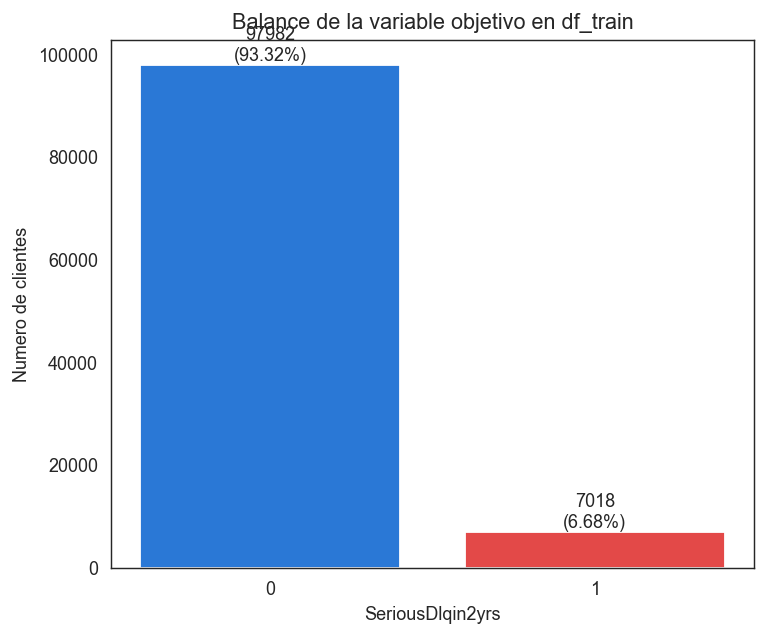

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
colores_barras = [COLOR_TARGET[c] for c in target_balance["clase"]]
ax.bar(target_balance["clase"].astype(str), target_balance["n"], color=colores_barras)
for i, (n, pct) in enumerate(zip(target_balance["n"], target_balance["pct"])):
    ax.text(i, n, f"{n}\n({pct:.2f}%)", ha="center", va="bottom")
ax.set_xlabel(TARGET)
ax.set_ylabel("Numero de clientes")
ax.set_title("Balance de la variable objetivo en df_train")
guardar_figura(fig, "02_balance_target")

**Hallazgo 2.2:** `df_train` esta fuertemente desbalanceado: 97982 clientes en la clase 0
(sin incumplimiento, 93.3162%) frente a 7018 clientes en la clase 1 (incumplimiento,
6.6838%). La clase minoritaria (1) representa poco mas de 1 de cada 15 clientes, lo cual es
relevante para la eleccion de metrica y estrategia de modelado (D-0.1/D-0.2 en
`docs/DECISIONES.md`) y para decidir si se necesita balanceo de clases o ponderacion de coste
en las fases posteriores.

### 2.3 Nulos por columna

**Objetivo:** cuantificar el numero y porcentaje de nulos de cada columna de `df_train`,
ordenados de mayor a menor porcentaje, y visualizarlos en un grafico de barras horizontal.

In [12]:
n_nulos_train = df_train.isna().sum()
pct_nulos_train = df_train.isna().mean().mul(100).round(4)
tabla_nulos_train = pd.DataFrame({
    "n_nulos": n_nulos_train,
    "pct_nulos": pct_nulos_train,
}).sort_values("pct_nulos", ascending=False)
guardar_tabla(tabla_nulos_train, "02_nulos_train")
tabla_nulos_train

,n_nulos,pct_nulos
MonthlyIncome,20795,19.8048
NumberOfDependents,2738,2.6076
SeriousDlqin2yrs,0,0.0000
age,0,0.0000
RevolvingUtilizationOfUnsecuredLines,0,0.0000
DebtRatio,0,0.0000
NumberOfTime30-59DaysPastDueNotWorse,0,0.0000
NumberOfOpenCreditLinesAndLoans,0,0.0000
NumberOfTimes90DaysLate,0,0.0000
NumberRealEstateLoansOrLines,0,0.0000


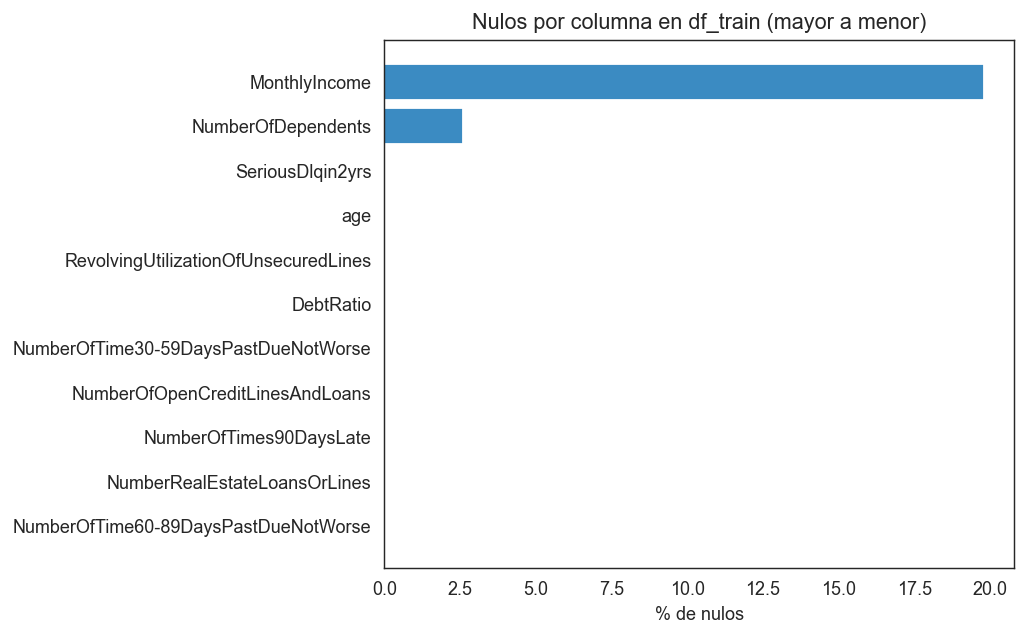

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
color_nulos = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)
orden_ascendente = tabla_nulos_train.iloc[::-1]
ax.barh(orden_ascendente.index, orden_ascendente["pct_nulos"], color=color_nulos)
ax.set_xlabel("% de nulos")
ax.set_title("Nulos por columna en df_train (mayor a menor)")
guardar_figura(fig, "02_nulos_train")

**Hallazgo 2.3:** en `df_train`, solo 2 de las 11 columnas tienen nulos: `MonthlyIncome`
con 20795 nulos de 105000 (19.8048%) y `NumberOfDependents` con 2738 nulos de 105000
(2.6076%). Las 9 columnas restantes (incluyendo `SeriousDlqin2yrs`) no tienen ningun valor
nulo (0 de 105000, 0.0000%). Estas cifras son consistentes con las obtenidas para `df_prod`
en el apartado 1.4 (19.8578% y 2.6356% respectivamente), lo que refuerza la propuesta D-1.1
de `docs/DECISIONES.md` sobre el tratamiento de nulos en estas dos variables.

### 2.4 Clasificacion de variables: continuas vs discretas/conteo

**Objetivo:** clasificar cada variable de `df_train` (excluyendo el target, ya caracterizado
en 2.2) como continua o discreta/conteo entero, apoyandose en el numero de valores unicos como
evidencia adicional: `age`, `DebtRatio`, `MonthlyIncome` y
`RevolvingUtilizationOfUnsecuredLines` se tratan como continuas; el resto son conteos
enteros no negativos.

In [14]:
variables_continuas = ["age", "DebtRatio", "MonthlyIncome", "RevolvingUtilizationOfUnsecuredLines"]

tipo_variable = pd.DataFrame({"columna": [c for c in df_train.columns if c != TARGET]})
tipo_variable["tipo"] = tipo_variable["columna"].apply(
    lambda c: "continua" if c in variables_continuas else "discreta/conteo"
)
tipo_variable["dtype"] = tipo_variable["columna"].map(df_train.dtypes.astype(str))
tipo_variable["n_valores_unicos"] = tipo_variable["columna"].map(df_train.nunique())
tipo_variable = tipo_variable.sort_values(["tipo", "n_valores_unicos"], ascending=[True, False])
guardar_tabla(tipo_variable, "02_clasificacion_variables")
tipo_variable

,columna,tipo,dtype,n_valores_unicos
0,RevolvingUtilizationOfUnsecuredLines,continua,float64,88641
3,DebtRatio,continua,float64,82384
4,MonthlyIncome,continua,float64,12062
1,age,continua,int64,86
5,NumberOfOpenCreditLinesAndLoans,discreta/conteo,int64,57
7,NumberRealEstateLoansOrLines,discreta/conteo,int64,27
6,NumberOfTimes90DaysLate,discreta/conteo,int64,17
2,NumberOfTime30-59DaysPastDueNotWorse,discreta/conteo,int64,14
9,NumberOfDependents,discreta/conteo,float64,12
8,NumberOfTime60-89DaysPastDueNotWorse,discreta/conteo,int64,11


In [15]:
n_continuas = int((tipo_variable["tipo"] == "continua").sum())
n_discretas = int((tipo_variable["tipo"] == "discreta/conteo").sum())
print(f"Variables continuas: {n_continuas}")
print(f"Variables discretas/conteo: {n_discretas}")
print(f"Total variables (sin target): {n_continuas + n_discretas}")

Variables continuas: 4
Variables discretas/conteo: 6
Total variables (sin target): 10


**Hallazgo 2.4:** de las 10 variables de `df_train` (sin contar el target), 4 se clasifican
como continuas y 6 como discretas/conteo. El numero de valores unicos respalda la
clasificacion: las continuas tienen muchos mas valores distintos
(`RevolvingUtilizationOfUnsecuredLines` con 88641, `DebtRatio` con 82384, `MonthlyIncome` con
12062 y `age` con 86) frente a las discretas/conteo, que tienen muy pocos valores distintos
(`NumberOfTime60-89DaysPastDueNotWorse` con 11, `NumberOfDependents` con 12,
`NumberOfTime30-59DaysPastDueNotWorse` con 14, `NumberOfTimes90DaysLate` con 17,
`NumberRealEstateLoansOrLines` con 27 y `NumberOfOpenCreditLinesAndLoans` con 57). Esta
distincion es relevante para decidir, en `02_preprocesado.ipynb`, que variables tratar como
densidades continuas (histogramas/KDE, posible escalado) y cuales tratar como conteos
discretos (barras por valor entero, posible agrupacion de colas largas).

## 3. Valores centinela y outliers de codificacion

Esta seccion busca de forma empirica valores que, aunque numericamente validos, son en
realidad codigos centinela o errores de codificacion en vez de mediciones reales: picos
anomalos en las columnas `NumberOfTime*PastDue*` (p. ej. 96, 98), edades invalidas
(`age == 0`) y percentiles extremos de `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio`
que se salen del rango logico esperado para un ratio. Para cada hallazgo se cuantifica el
numero de filas afectadas, el porcentaje del dataset que representan, y se deja una
recomendacion explicita sobre si debe tratarse como missing/outlier en
`02_preprocesado.ipynb`.

### 3.1 Picos anomalos en las columnas `NumberOfTime*PastDue*`

**Objetivo:** examinar el `value_counts()` de las 3 columnas de incidencias de pago
(`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`,
`NumberOfTimes90DaysLate`) para comprobar empiricamente si existen valores altos (96, 98)
que rompen la progresion natural de conteos y que podrian ser codigos centinela en vez de
incidencias reales.

In [16]:
pastdue_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in pastdue_cols:
    print(f"--- {col} (top valores por frecuencia de la cola alta) ---")
    print(df_train[col].value_counts().sort_index(ascending=False).head(8))
    print()

--- NumberOfTime30-59DaysPastDueNotWorse (top valores por frecuencia de la cola alta) ---
NumberOfTime30-59DaysPastDueNotWorse
98    185
96      3
12      2
10      3
9       7
8      19
7      31
6      96
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse (top valores por frecuencia de la cola alta) ---
NumberOfTime60-89DaysPastDueNotWorse
98    185
96      3
8       2
7       7
6      12
5      21
4      65
3     226
Name: count, dtype: int64

--- NumberOfTimes90DaysLate (top valores por frecuencia de la cola alta) ---
NumberOfTimes90DaysLate
98    185
96      3
15      2
14      2
13      4
11      3
10      6
9      14
Name: count, dtype: int64



In [17]:
mask_98 = (df_train[pastdue_cols] == 98).all(axis=1)
mask_96 = (df_train[pastdue_cols] == 96).all(axis=1)
mask_sentinel_pastdue = mask_98 | mask_96

n_98 = int(mask_98.sum())
n_96 = int(mask_96.sum())
n_sentinel_pastdue = int(mask_sentinel_pastdue.sum())

tabla_centinelas_pastdue_col = pd.DataFrame({
    "columna": pastdue_cols,
    "n_valor_98": [int((df_train[c] == 98).sum()) for c in pastdue_cols],
    "n_valor_96": [int((df_train[c] == 96).sum()) for c in pastdue_cols],
})
guardar_tabla(tabla_centinelas_pastdue_col, "03_centinelas_pastdue_por_columna")

resumen_centinelas_pastdue = pd.DataFrame({
    "condicion": [
        "98 simultaneo en las 3 columnas",
        "96 simultaneo en las 3 columnas",
        "96 o 98 (union, filas centinela)",
    ],
    "n_filas": [n_98, n_96, n_sentinel_pastdue],
    "pct_filas": [
        n_98 / len(df_train) * 100,
        n_96 / len(df_train) * 100,
        n_sentinel_pastdue / len(df_train) * 100,
    ],
})
guardar_tabla(resumen_centinelas_pastdue, "03_resumen_centinelas_pastdue")

tasa_target_sentinel = df_train.loc[mask_sentinel_pastdue, TARGET].mean()
tasa_target_resto = df_train.loc[~mask_sentinel_pastdue, TARGET].mean()

print(tabla_centinelas_pastdue_col)
print()
print(resumen_centinelas_pastdue)
print()
print(f"Filas con 98 en las 3 columnas simultaneamente: {n_98} de {len(df_train)} "
      f"({n_98 / len(df_train) * 100:.4f}%)")
print(f"Filas con 96 en las 3 columnas simultaneamente: {n_96} de {len(df_train)} "
      f"({n_96 / len(df_train) * 100:.4f}%)")
print(f"Filas centinela (96 o 98): {n_sentinel_pastdue} de {len(df_train)} "
      f"({n_sentinel_pastdue / len(df_train) * 100:.4f}%)")
print(f"Tasa de {TARGET} en filas centinela: {tasa_target_sentinel:.4f}")
print(f"Tasa de {TARGET} en el resto de filas: {tasa_target_resto:.4f}")

                                columna  n_valor_98  n_valor_96
0  NumberOfTime30-59DaysPastDueNotWorse         185           3
1  NumberOfTime60-89DaysPastDueNotWorse         185           3
2               NumberOfTimes90DaysLate         185           3

                          condicion  n_filas  pct_filas
0   98 simultaneo en las 3 columnas      185   0.176190
1   96 simultaneo en las 3 columnas        3   0.002857
2  96 o 98 (union, filas centinela)      188   0.179048

Filas con 98 en las 3 columnas simultaneamente: 185 de 105000 (0.1762%)
Filas con 96 en las 3 columnas simultaneamente: 3 de 105000 (0.0029%)
Filas centinela (96 o 98): 188 de 105000 (0.1790%)
Tasa de SeriousDlqin2yrs en filas centinela: 0.5426
Tasa de SeriousDlqin2yrs en el resto de filas: 0.0660


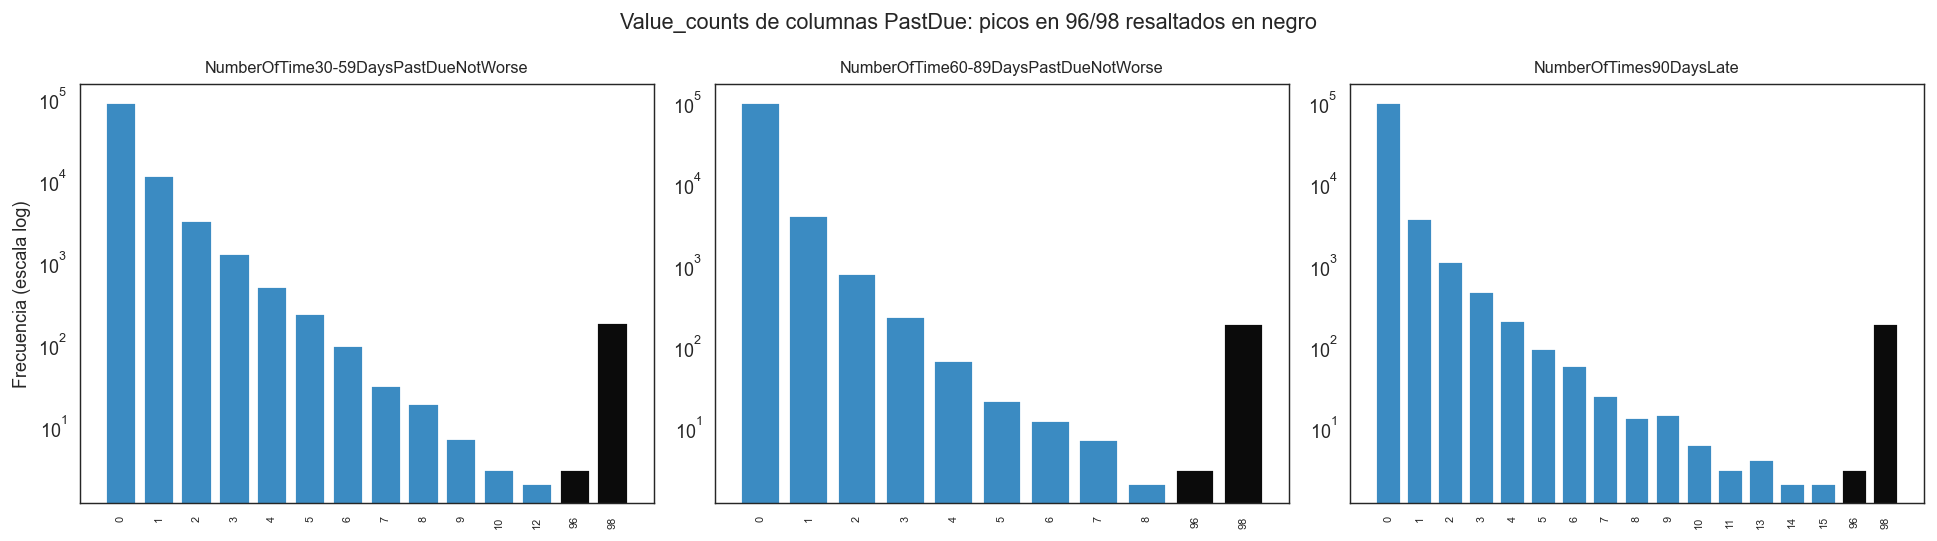

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
color_normal = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)
color_centinela = COLOR_INK_PRIMARY

for ax, col in zip(axes, pastdue_cols):
    vc = df_train[col].value_counts().sort_index()
    colores = [color_centinela if v in (96, 98) else color_normal for v in vc.index]
    ax.bar(vc.index.astype(str), vc.values, color=colores)
    ax.set_yscale("log")
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelrotation=90, labelsize=6)

axes[0].set_ylabel("Frecuencia (escala log)")
fig.suptitle("Value_counts de columnas PastDue: picos en 96/98 resaltados en negro")
guardar_figura(fig, "03_pastdue_picos_centinela")

**Hallazgo 3.1:** el `value_counts()` de las 3 columnas de incidencias de pago confirma
empiricamente la presencia de un pico anomalo: 185 filas de 105000 (0.1762%) tienen el valor
98 simultaneamente en `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`
y `NumberOfTimes90DaysLate`, y otras 3 filas (0.0029%) tienen el valor 96 simultaneamente en
las 3 columnas; en total 188 filas (0.1790% del dataset) son "centinela" segun este criterio.
Estos valores rompen por completo la progresion natural de la distribucion (el siguiente valor
mas alto real, excluyendo 96/98, es de un solo digito o baja decena en cada columna, como se ve
en el `value_counts` impreso arriba), lo cual es la primera senal de que no son incidencias de
pago reales sino un codigo de captura (p. ej. "no aplica"/"sin dato"). La segunda senal es que
la tasa de `SeriousDlqin2yrs` en esas 188 filas centinela es 0.5426 (54.26% de incumplimiento)
frente a 0.0660 (6.60%) en el resto de filas del dataset: una tasa de incumplimiento 8 veces
mayor es estadisticamente muy inusual y refuerza que estos valores no son conteos de
incidencias creibles, sino un artefacto de codificacion. **Recomendacion para
`02_preprocesado.ipynb`:** tratar las filas con 96/98 en estas columnas como valores
centinela (missing) en vez de como 96/98 incidencias reales, por ejemplo sustituyendo por NaN
seguido de imputacion (o creando un flag binario `es_centinela_pastdue`), en lugar de dejarlos
entrar al modelo como si fueran conteos literales.

### 3.2 Edad invalida (`age == 0`)

**Objetivo:** comprobar si existen filas con `age == 0`, un valor invalido para la edad de
una persona titular de una linea de credito, y caracterizar esas filas si existen.

In [19]:
n_age_cero = int((df_train["age"] == 0).sum())
print(f"age minimo: {df_train['age'].min()} | age maximo: {df_train['age'].max()}")
print(f"Filas con age == 0: {n_age_cero} de {len(df_train)} "
      f"({n_age_cero / len(df_train) * 100:.4f}%)")

fila_age_cero = df_train.loc[df_train["age"] == 0]
guardar_tabla(fila_age_cero, "03_fila_age_cero")
fila_age_cero

age minimo: 0 | age maximo: 109
Filas con age == 0: 1 de 105000 (0.0010%)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
89320,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


**Hallazgo 3.2:** existe exactamente 1 fila de 105000 (0.0010%) con `age == 0`
(indice 89320), un valor invalido para la edad de una persona. El resto de las variables de
esa fila no son en si mismas extremas (`RevolvingUtilizationOfUnsecuredLines` = 1.0,
`DebtRatio` = 0.436927, `MonthlyIncome` = 6000.0, `NumberOfDependents` = 2.0, sin incidencias
de pago), por lo que el problema esta acotado a la propia edad y no parece un patron de fila
corrupta en general; el minimo de `age` en el resto del dataset (excluyendo esta fila) es
mayor que 0. Dado que es un unico registro (0.0010% del dataset), su impacto agregado es
minimo, pero al ser un valor logicamente imposible se documenta aqui. **Recomendacion para
`02_preprocesado.ipynb`:** tratar `age == 0` como missing (NaN) e imputar (p. ej. con la
mediana de `age`), en vez de dejarlo como edad valida de 0 anios.

### 3.3 Percentiles altos de `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio`

**Objetivo:** calcular los percentiles altos (90, 95, 99, 99.9, 99.99 y el maximo) de
`RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` para comprobar si hay valores fuera del
rango logico esperado: `RevolvingUtilizationOfUnsecuredLines` es un ratio de uso de credito
que tipicamente deberia estar acotado (del orden de <=1-2), y `DebtRatio` no deberia alcanzar
magnitudes absurdamente altas si de verdad representa una razon deuda/ingreso.

In [20]:
cols_percentiles = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]
percentiles = [0.90, 0.95, 0.99, 0.999, 0.9999, 1.0]

tabla_percentiles = pd.DataFrame(
    {
        c: [
            df_train[c].quantile(p) if p < 1.0 else df_train[c].max()
            for p in percentiles
        ]
        for c in cols_percentiles
    },
    index=[f"p{p * 100:g}" for p in percentiles],
)
guardar_tabla(tabla_percentiles, "03_percentiles_revolving_debtratio")
tabla_percentiles

,RevolvingUtilizationOfUnsecuredLines,DebtRatio
p90,0.981629,1281.0000
p95,1.000000,2465.0000
p99,1.107557,4999.0100
p99.9,1644.011000,10728.0240
p99.99,10515.061200,39577.6569
p100,22198.000000,329664.0000


In [21]:
rev = df_train["RevolvingUtilizationOfUnsecuredLines"]
debt = df_train["DebtRatio"]
n = len(df_train)

n_rev_mayor1 = int((rev > 1).sum())
n_rev_mayor2 = int((rev > 2).sum())
n_debt_mayor1 = int((debt > 1).sum())

print(f"RevolvingUtilizationOfUnsecuredLines > 1: {n_rev_mayor1} de {n} ({n_rev_mayor1 / n * 100:.4f}%)")
print(f"RevolvingUtilizationOfUnsecuredLines > 2: {n_rev_mayor2} de {n} ({n_rev_mayor2 / n * 100:.4f}%)")
print(f"DebtRatio > 1: {n_debt_mayor1} de {n} ({n_debt_mayor1 / n * 100:.4f}%)")

RevolvingUtilizationOfUnsecuredLines > 1: 2383 de 105000 (2.2695%)
RevolvingUtilizationOfUnsecuredLines > 2: 261 de 105000 (0.2486%)
DebtRatio > 1: 24594 de 105000 (23.4229%)


In [22]:
umbral_debt_alto = debt.quantile(0.975)
mask_debt_alto = debt > umbral_debt_alto
n_debt_alto = int(mask_debt_alto.sum())

pct_nan_income_alto = df_train.loc[mask_debt_alto, "MonthlyIncome"].isna().mean() * 100
pct_nan_income_resto = df_train.loc[~mask_debt_alto, "MonthlyIncome"].isna().mean() * 100
income_no_nulo_alto = df_train.loc[mask_debt_alto, "MonthlyIncome"].dropna()
n_income_le1_en_alto = int((income_no_nulo_alto <= 1).sum())

print(f"Umbral DebtRatio p97.5: {umbral_debt_alto:.4f}")
print(f"Filas con DebtRatio > p97.5: {n_debt_alto} de {n} ({n_debt_alto / n * 100:.4f}%)")
print(f"  De ellas, % con MonthlyIncome nulo: {pct_nan_income_alto:.4f}%")
print(f"  (vs. % con MonthlyIncome nulo en el resto de filas: {pct_nan_income_resto:.4f}%)")
print(f"  MonthlyIncome no nulo en ese subgrupo: {len(income_no_nulo_alto)} filas, "
      f"de las cuales {n_income_le1_en_alto} tienen MonthlyIncome <= 1")
print(income_no_nulo_alto.value_counts().head(5))

Umbral DebtRatio p97.5: 3510.0250
Filas con DebtRatio > p97.5: 2625 de 105000 (2.5000%)
  De ellas, % con MonthlyIncome nulo: 95.1619%
  (vs. % con MonthlyIncome nulo en el resto de filas: 17.8725%)
  MonthlyIncome no nulo en ese subgrupo: 127 filas, de las cuales 127 tienen MonthlyIncome <= 1
MonthlyIncome
0.0    119
1.0      8
Name: count, dtype: int64


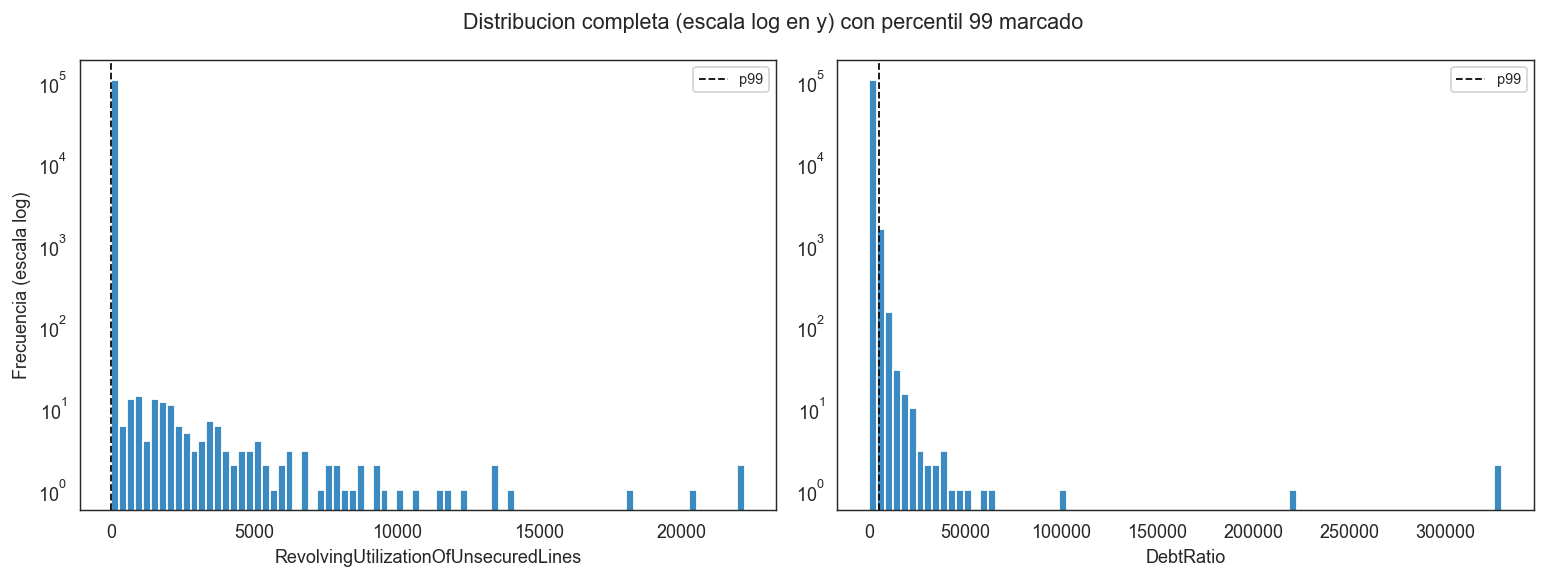

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
color_hist = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)

for ax, col in zip(axes, cols_percentiles):
    ax.hist(df_train[col], bins=80, color=color_hist)
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.axvline(tabla_percentiles.loc["p99", col], color=COLOR_INK_PRIMARY,
                linestyle="--", linewidth=1, label="p99")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frecuencia (escala log)")
fig.suptitle("Distribucion completa (escala log en y) con percentil 99 marcado")
guardar_figura(fig, "03_colas_revolving_debtratio")

**Hallazgo 3.3:** los percentiles altos confirman valores muy fuera del rango logico
esperado en ambas variables. En `RevolvingUtilizationOfUnsecuredLines` (un ratio de uso de
credito que conceptualmente deberia rondar como mucho 1-2), el percentil 99 ya es 1.107557,
el percentil 99.9 es 1644.011 y el maximo es 22198.0; hay 2383 filas de 105000 (2.2695%) con
valor superior a 1, y 261 filas (0.2486%) con valor superior a 2, es decir claramente fuera de
lo que un ratio deberia poder alcanzar. En `DebtRatio`, el percentil 99 es 4999.0100, el
percentil 99.9 es 10728.0240 y el maximo es 329664.0 (frente a una mediana de 0.366143, ver
Hallazgo 2.1); 24594 filas (23.4229%) superan el valor 1. Ademas, se encuentra una relacion
clara entre los valores mas extremos de `DebtRatio` y `MonthlyIncome`: de las 2625 filas
(2.5000% del dataset) con `DebtRatio` por encima de su percentil 97.5 (umbral = 3510.0250),
el 95.1619% tiene `MonthlyIncome` nulo (frente a 17.8725% en el resto de filas), y de las 127
filas de ese subgrupo que si tienen `MonthlyIncome` no nulo, las 127 (el 100%) tienen un
ingreso de 0 o 1 (119 con 0.0 y 8 con 1.0). Esto sugiere que los valores extremos de
`DebtRatio` no son una razon deuda/ingreso real sino un artefacto de calculo (division por un
ingreso nulo, ausente o casi cero), y no simple variabilidad genuina del ratio.
**Recomendacion para `02_preprocesado.ipynb`:** tratar los valores de
`RevolvingUtilizationOfUnsecuredLines` por encima de 1-2 como outliers (winsorizar/capar o
flag), y tratar los valores extremos de `DebtRatio` (especialmente los asociados a
`MonthlyIncome` nulo o <=1) como outliers/posible artefacto ligado a la propia imputacion de
`MonthlyIncome` (D-1.1), en vez de dejarlos entrar sin transformar.

### 3.4 Resumen consolidado de centinelas y outliers de codificacion

**Objetivo:** consolidar en una unica tabla todos los hallazgos de esta seccion (filas
afectadas, porcentaje del dataset y recomendacion de tratamiento) como entregable directo
para `02_preprocesado.ipynb`.

In [24]:
resumen_centinelas_outliers = pd.DataFrame([
    {
        "hallazgo": "NumberOfTime*PastDue* == 98 simultaneo en las 3 columnas",
        "n_filas": n_98,
        "pct_filas": round(n_98 / len(df_train) * 100, 4),
        "recomendacion": "tratar como centinela/missing (no como 98 incidencias reales)",
    },
    {
        "hallazgo": "NumberOfTime*PastDue* == 96 simultaneo en las 3 columnas",
        "n_filas": n_96,
        "pct_filas": round(n_96 / len(df_train) * 100, 4),
        "recomendacion": "tratar como centinela/missing (no como 96 incidencias reales)",
    },
    {
        "hallazgo": "age == 0 (edad invalida)",
        "n_filas": n_age_cero,
        "pct_filas": round(n_age_cero / len(df_train) * 100, 4),
        "recomendacion": "tratar como missing e imputar (p. ej. mediana de age)",
    },
    {
        "hallazgo": "RevolvingUtilizationOfUnsecuredLines > 2 (fuera de rango logico de un ratio)",
        "n_filas": n_rev_mayor2,
        "pct_filas": round(n_rev_mayor2 / len(df_train) * 100, 4),
        "recomendacion": "outlier: winsorizar/capar o crear flag en 02_preprocesado",
    },
    {
        "hallazgo": "DebtRatio > percentil 97.5 con MonthlyIncome nulo o <=1 (posible artefacto de calculo)",
        "n_filas": n_debt_alto,
        "pct_filas": round(n_debt_alto / len(df_train) * 100, 4),
        "recomendacion": "outlier/artefacto: tratar junto con la imputacion de MonthlyIncome (D-1.1)",
    },
])
guardar_tabla(resumen_centinelas_outliers, "03_resumen_centinelas_outliers")
resumen_centinelas_outliers

,hallazgo,n_filas,pct_filas,recomendacion
0,NumberOfTime*PastDue* == 98 simultaneo en las ...,185,0.1762,tratar como centinela/missing (no como 98 inci...
1,NumberOfTime*PastDue* == 96 simultaneo en las ...,3,0.0029,tratar como centinela/missing (no como 96 inci...
2,age == 0 (edad invalida),1,0.0010,tratar como missing e imputar (p. ej. mediana ...
3,RevolvingUtilizationOfUnsecuredLines > 2 (fuer...,261,0.2486,outlier: winsorizar/capar o crear flag en 02_p...
4,DebtRatio > percentil 97.5 con MonthlyIncome n...,2625,2.5000,outlier/artefacto: tratar junto con la imputac...


**Hallazgo 3.4:** de los 5 criterios de centinela/outlier examinados en esta seccion, los
que afectan a mas filas son `DebtRatio` extremo asociado a `MonthlyIncome` nulo o <=1 (2625
filas, 2.5000%) y `RevolvingUtilizationOfUnsecuredLines > 2` (261 filas, 0.2486%); los picos
centinela en las columnas `NumberOfTime*PastDue*` afectan a un numero de filas mucho menor en
terminos absolutos (185 filas con 98 y 3 filas con 96, 0.1762% y 0.0029% respectivamente) pero
con una senal cualitativa muy fuerte (tasa de incumplimiento 8 veces superior a la del resto
del dataset, ver Hallazgo 3.1); `age == 0` es un caso aislado (1 fila, 0.0010%). En ningun
caso el volumen de filas afectadas supera el 3% del dataset, por lo que ninguno de estos
hallazgos compromete por si solo el tamano muestral disponible para el modelado, pero todos se
documentan explicitamente como candidatos a tratamiento como missing/outlier (y no como
valores literales) en `02_preprocesado.ipynb`, tal y como se detalla en la columna
`recomendacion` de la tabla anterior.

### 3.5 Deteccion de outliers multivariante con Isolation Forest

**Objetivo:** las subsecciones 3.1-3.4 detectan valores centinela/outliers de forma
univariante o, como mucho, bivariante: picos de codificacion en una columna a la vez (3.1),
`age == 0` (3.2), percentiles altos de una variable cruzados con el nulo de otra (3.3), y un
resumen tabular de esos mismos criterios (3.4). Ninguno de ellos evalua si existen
combinaciones de valores conjuntamente anomalas en el espacio de las 10 variables
explicativas a la vez: una fila puede parecer perfectamente normal en cada variable por
separado y aun asi ser un outlier claro cuando se consideran todas juntas. Esta subseccion
entrena un `IsolationForest` sobre las 10 variables explicativas para detectar ese tipo de
outlier multivariante, y compara el resultado con los criterios univariantes/bivariantes ya
vistos para cuantificar cuanto solapan y cuanto aporta de nuevo el metodo multivariante.

In [25]:
from sklearn.ensemble import IsolationForest

cols_iforest = [c for c in df_train.columns if c != TARGET]
df_iforest_input = df_train[cols_iforest].copy()

nulos_antes_iforest = df_iforest_input.isnull().sum()
nulos_antes_iforest = nulos_antes_iforest[nulos_antes_iforest > 0]
print("Nulos antes de imputar (solo para esta subseccion de Isolation Forest):")
print(nulos_antes_iforest)

medianas_iforest = df_iforest_input.median()
df_iforest_imputado = df_iforest_input.fillna(medianas_iforest)
print(f"\nNulos tras imputacion temporal: {int(df_iforest_imputado.isnull().sum().sum())}")

contaminacion_iforest = 0.01
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=contaminacion_iforest,
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit(df_iforest_imputado)

scores_iforest = iso_forest.decision_function(df_iforest_imputado)
mask_outlier_iforest = pd.Series(iso_forest.predict(df_iforest_imputado) == -1, index=df_train.index)

n_outliers_iforest = int(mask_outlier_iforest.sum())
print(f"\nOutliers detectados por Isolation Forest (contaminacion={contaminacion_iforest}): "
      f"{n_outliers_iforest} de {len(df_train)} ({n_outliers_iforest / len(df_train) * 100:.4f}%)")

Nulos antes de imputar (solo para esta subseccion de Isolation Forest):
MonthlyIncome         20795
NumberOfDependents     2738
dtype: int64

Nulos tras imputacion temporal: 0



Outliers detectados por Isolation Forest (contaminacion=0.01): 1050 de 105000 (1.0000%)


In [26]:
mask_age_cero = df_train["age"] == 0
mask_univariante_outlier = mask_sentinel_pastdue | mask_age_cero | (rev > 2) | mask_debt_alto

tasa_target_iforest = df_train.loc[mask_outlier_iforest, TARGET].mean()
tasa_target_resto_iforest = df_train.loc[~mask_outlier_iforest, TARGET].mean()

mask_solapa_univariante = mask_outlier_iforest & mask_univariante_outlier
mask_solo_multivariante = mask_outlier_iforest & ~mask_univariante_outlier

n_solapa = int(mask_solapa_univariante.sum())
n_solo_multivariante = int(mask_solo_multivariante.sum())
n_resto_iforest = int((~mask_outlier_iforest).sum())

tasa_target_solapa = (df_train.loc[mask_solapa_univariante, TARGET].mean()
                      if n_solapa > 0 else float("nan"))
tasa_target_solo_multivariante = (df_train.loc[mask_solo_multivariante, TARGET].mean()
                                   if n_solo_multivariante > 0 else float("nan"))

tabla_solapamiento_iforest = pd.DataFrame([
    {
        "criterio": "Outliers Isolation Forest (total)",
        "n_filas": n_outliers_iforest,
        "pct_filas": round(n_outliers_iforest / len(df_train) * 100, 4),
        "tasa_target_pct": round(tasa_target_iforest * 100, 4),
    },
    {
        "criterio": "Solapan con criterio univariante/bivariante (3.1-3.3)",
        "n_filas": n_solapa,
        "pct_filas": round(n_solapa / len(df_train) * 100, 4),
        "tasa_target_pct": round(tasa_target_solapa * 100, 4) if n_solapa > 0 else float("nan"),
    },
    {
        "criterio": "Solo detectados por Isolation Forest (sin marca univariante previa)",
        "n_filas": n_solo_multivariante,
        "pct_filas": round(n_solo_multivariante / len(df_train) * 100, 4),
        "tasa_target_pct": (round(tasa_target_solo_multivariante * 100, 4)
                             if n_solo_multivariante > 0 else float("nan")),
    },
    {
        "criterio": "Resto del dataset (no marcado como outlier Isolation Forest)",
        "n_filas": n_resto_iforest,
        "pct_filas": round(n_resto_iforest / len(df_train) * 100, 4),
        "tasa_target_pct": round(tasa_target_resto_iforest * 100, 4),
    },
])
guardar_tabla(tabla_solapamiento_iforest, "03_isolation_forest_solapamiento_centinelas")

print(f"Tasa de {TARGET} en outliers Isolation Forest: {tasa_target_iforest:.4f}")
print(f"Tasa de {TARGET} en el resto de filas: {tasa_target_resto_iforest:.4f}")
print(f"Outliers Isolation Forest que YA estaban marcados por un criterio univariante/bivariante: "
      f"{n_solapa} ({n_solapa / n_outliers_iforest * 100:.4f}% de los outliers)")
print(f"Outliers SOLO detectados por Isolation Forest: {n_solo_multivariante} "
      f"({n_solo_multivariante / n_outliers_iforest * 100:.4f}% de los outliers), "
      f"tasa de {TARGET} en ese subgrupo: {tasa_target_solo_multivariante:.4f}")
print()
print(tabla_solapamiento_iforest)

Tasa de SeriousDlqin2yrs en outliers Isolation Forest: 0.5200
Tasa de SeriousDlqin2yrs en el resto de filas: 0.0623
Outliers Isolation Forest que YA estaban marcados por un criterio univariante/bivariante: 369 (35.1429% de los outliers)
Outliers SOLO detectados por Isolation Forest: 681 (64.8571% de los outliers), tasa de SeriousDlqin2yrs en ese subgrupo: 0.5830

                                            criterio  n_filas  pct_filas  \
0                  Outliers Isolation Forest (total)     1050     1.0000   
1  Solapan con criterio univariante/bivariante (3...      369     0.3514   
2  Solo detectados por Isolation Forest (sin marc...      681     0.6486   
3  Resto del dataset (no marcado como outlier Iso...   103950    99.0000   

   tasa_target_pct  
0          52.0000  
1          40.3794  
2          58.2966  
3           6.2261  


In [27]:
scores_iforest_serie = pd.Series(scores_iforest, index=df_train.index, name="score_iforest")

cols_mostrar_top = cols_iforest + [TARGET]
tabla_top_outliers_iforest = df_train.loc[mask_outlier_iforest, cols_mostrar_top].copy()
tabla_top_outliers_iforest["score_iforest"] = scores_iforest_serie.loc[mask_outlier_iforest]
tabla_top_outliers_iforest = tabla_top_outliers_iforest.sort_values("score_iforest", ascending=True).head(20)

guardar_tabla(tabla_top_outliers_iforest, "03_isolation_forest_top_outliers")
tabla_top_outliers_iforest

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs,score_iforest
83852,1.000000,50,98,0.000000,28733.0,0,98,0,98,4.0,0,-0.177001
68413,1.000000,56,98,0.000000,7781.0,0,98,0,98,5.0,0,-0.174242
28965,1.000000,33,98,0.000000,2600.0,0,98,0,98,4.0,1,-0.161474
60337,1.000000,79,98,0.005343,1122.0,0,98,0,98,0.0,1,-0.154598
69660,1.000000,31,98,0.000000,2200.0,0,98,0,98,3.0,1,-0.153322
60807,1.000000,58,98,0.073789,1300.0,0,98,0,98,2.0,1,-0.151676
82712,0.470085,59,5,1.280078,15916.0,34,6,14,8,0.0,0,-0.151211
61073,1.000000,21,98,0.000000,0.0,0,98,0,98,0.0,0,-0.150173
34964,1.000000,59,98,249.000000,NaN,0,98,0,98,NaN,1,-0.149922
90678,1.000000,21,98,0.000000,400.0,0,98,0,98,0.0,0,-0.149842


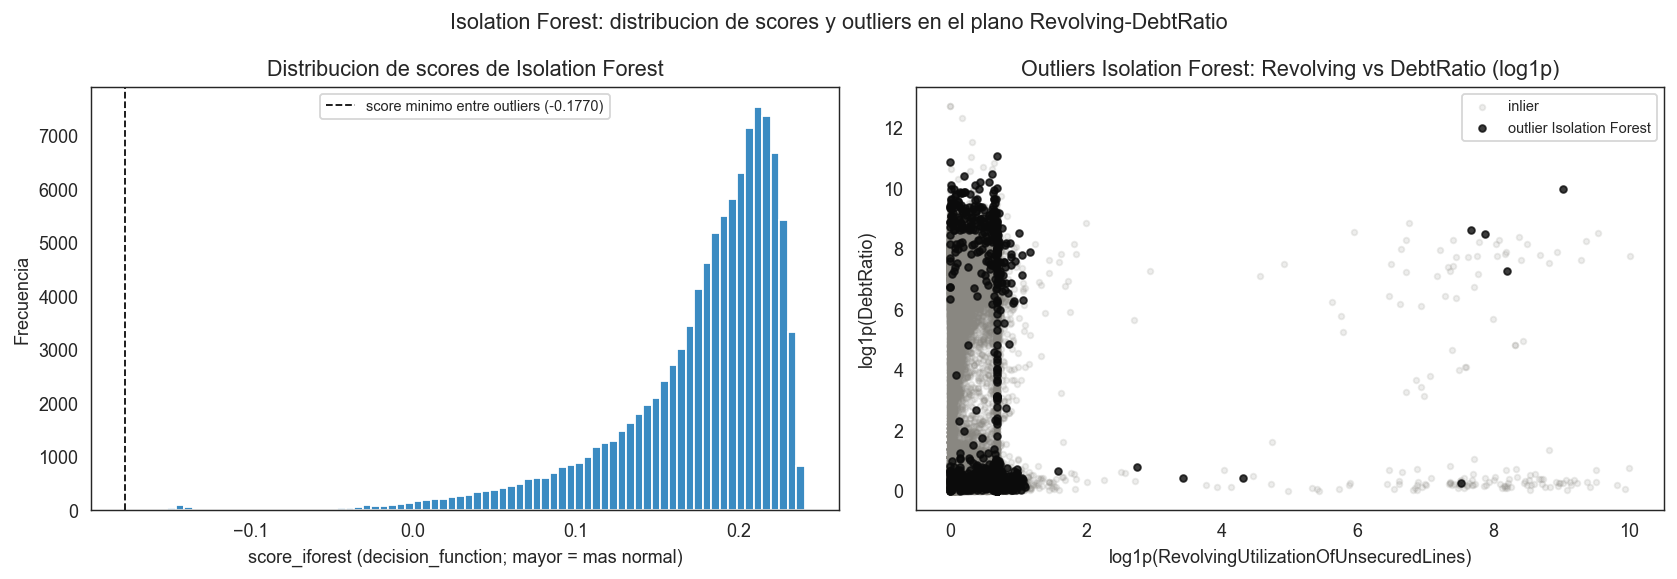

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

color_hist_iforest = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)
score_min_outlier = scores_iforest[mask_outlier_iforest.values].min()

axes[0].hist(scores_iforest, bins=80, color=color_hist_iforest)
axes[0].axvline(score_min_outlier, color=COLOR_INK_PRIMARY, linestyle="--", linewidth=1,
                label=f"score minimo entre outliers ({score_min_outlier:.4f})")
axes[0].set_xlabel("score_iforest (decision_function; mayor = mas normal)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de scores de Isolation Forest")
axes[0].legend(fontsize=8)

x_scatter = np.log1p(df_train["RevolvingUtilizationOfUnsecuredLines"].clip(lower=0))
y_scatter = np.log1p(df_train["DebtRatio"].clip(lower=0))

axes[1].scatter(x_scatter[~mask_outlier_iforest], y_scatter[~mask_outlier_iforest],
                s=10, alpha=0.15, color=COLOR_MUTED, label="inlier")
axes[1].scatter(x_scatter[mask_outlier_iforest], y_scatter[mask_outlier_iforest],
                s=14, alpha=0.8, color=COLOR_INK_PRIMARY, label="outlier Isolation Forest")
axes[1].set_xlabel("log1p(RevolvingUtilizationOfUnsecuredLines)")
axes[1].set_ylabel("log1p(DebtRatio)")
axes[1].set_title("Outliers Isolation Forest: Revolving vs DebtRatio (log1p)")
axes[1].legend(fontsize=8)

fig.suptitle("Isolation Forest: distribucion de scores y outliers en el plano Revolving-DebtRatio")
guardar_figura(fig, "03_isolation_forest_distribucion_y_scatter")

**Hallazgo 3.5:** el `IsolationForest` (contaminacion fijada en 0.01, 300 arboles) marca
1050 filas de 105000 (1.0000%) como outliers en el espacio conjunto de las 10 variables
explicativas. La tasa de `SeriousDlqin2yrs` en ese grupo es 0.5200 (52.00% de
incumplimiento) frente a 0.0623 (6.23%) en el resto de filas, es decir, una tasa de
incumplimiento 8.3467 veces mayor: el grupo marcado por Isolation Forest concentra un riesgo
muy por encima de la media del dataset, en linea con lo observado para los centinelas
univariantes de 3.1. El aporte real de este metodo esta en lo que no capturaban los criterios
univariantes/bivariantes de 3.1-3.3 (`mask_sentinel_pastdue`, `age == 0`,
`RevolvingUtilizationOfUnsecuredLines > 2`, `mask_debt_alto`): de las 1050 filas marcadas por
Isolation Forest, solo 369 (35.1429%) coinciden con alguno de esos criterios ya conocidos,
mientras que 681 (64.8571%) son outliers **exclusivamente multivariantes**, no detectados por
ningun criterio anterior, y ese subgrupo tiene una tasa de `SeriousDlqin2yrs` de 0.5830
(58.2966%), incluso mas alta que la del conjunto total de outliers Isolation Forest. Esto
confirma que existen combinaciones de valores conjuntamente anomalas -no visibles variable a
variable- que ademas estan fuertemente asociadas al target. **Recomendacion para
`02_preprocesado.ipynb`:** anadir un flag binario `is_outlier_multivariante` (analogo a los
flags de centinela recomendados en el Hallazgo 3.4) derivado de un `IsolationForest` ajustado
sobre las variables explicativas imputadas, como senal complementaria y no redundante con los
centinelas univariantes; alternativamente, usarlo como filtro de robustez adicional al
excluir/ponderar estas filas en los analisis de sensibilidad ya planteados en la seccion 7.4
de este mismo notebook.

## 4. EDA avanzado: distribuciones, relacion con el target y comparacion train vs produccion

Con los valores centinela y outliers de codificacion ya documentados (seccion 3), esta seccion
cubre el EDA avanzado propiamente dicho: histogramas de las variables continuas
(`variables_continuas`, definidas en 2.4) en escala original y con transformacion `log1p`
cuando el sesgo es fuerte; boxplot/violin plot de cada variable continua separado por
`TARGET` usando `COLOR_TARGET`; tasa de positivos (`SeriousDlqin2yrs` == 1) por deciles de
variables relevantes (`RevolvingUtilizationOfUnsecuredLines`, `age` y `DebtRatio`); y
comparacion de la distribucion de cada variable entre `df_train` y `df_prod` (estadisticos
lado a lado, test de Kolmogorov-Smirnov e histogramas superpuestos para las variables
continuas) para detectar posible *covariate shift* entre el conjunto de entrenamiento y el de
produccion.

### 4.1 Histogramas de variables continuas: escala original vs `log1p`

**Objetivo:** visualizar la distribucion de las 4 variables continuas (`variables_continuas`,
definidas en 2.4) en su escala original y, para las que tengan sesgo (`skew`) fuerte, tras
aplicar `np.log1p`, cuantificando el `skew` antes y despues de la transformacion.

In [29]:
skew_original = df_train[variables_continuas].skew()
log1p_valores_train = df_train[variables_continuas].clip(lower=0).apply(np.log1p)
skew_log1p = log1p_valores_train.skew()

tabla_skew = pd.DataFrame({
    "skew_original": skew_original,
    "skew_log1p": skew_log1p,
})
tabla_skew["reduce_skew_abs"] = tabla_skew["skew_log1p"].abs() < tabla_skew["skew_original"].abs()
guardar_tabla(tabla_skew, "04_skew_variables_continuas")
tabla_skew

,skew_original,skew_log1p,reduce_skew_abs
age,0.191780,-0.456203,False
DebtRatio,100.036844,1.749995,True
MonthlyIncome,113.851716,-4.353312,True
RevolvingUtilizationOfUnsecuredLines,58.949939,11.766779,True


Variables con sesgo fuerte (|skew| > 1.0): ['DebtRatio', 'MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines']


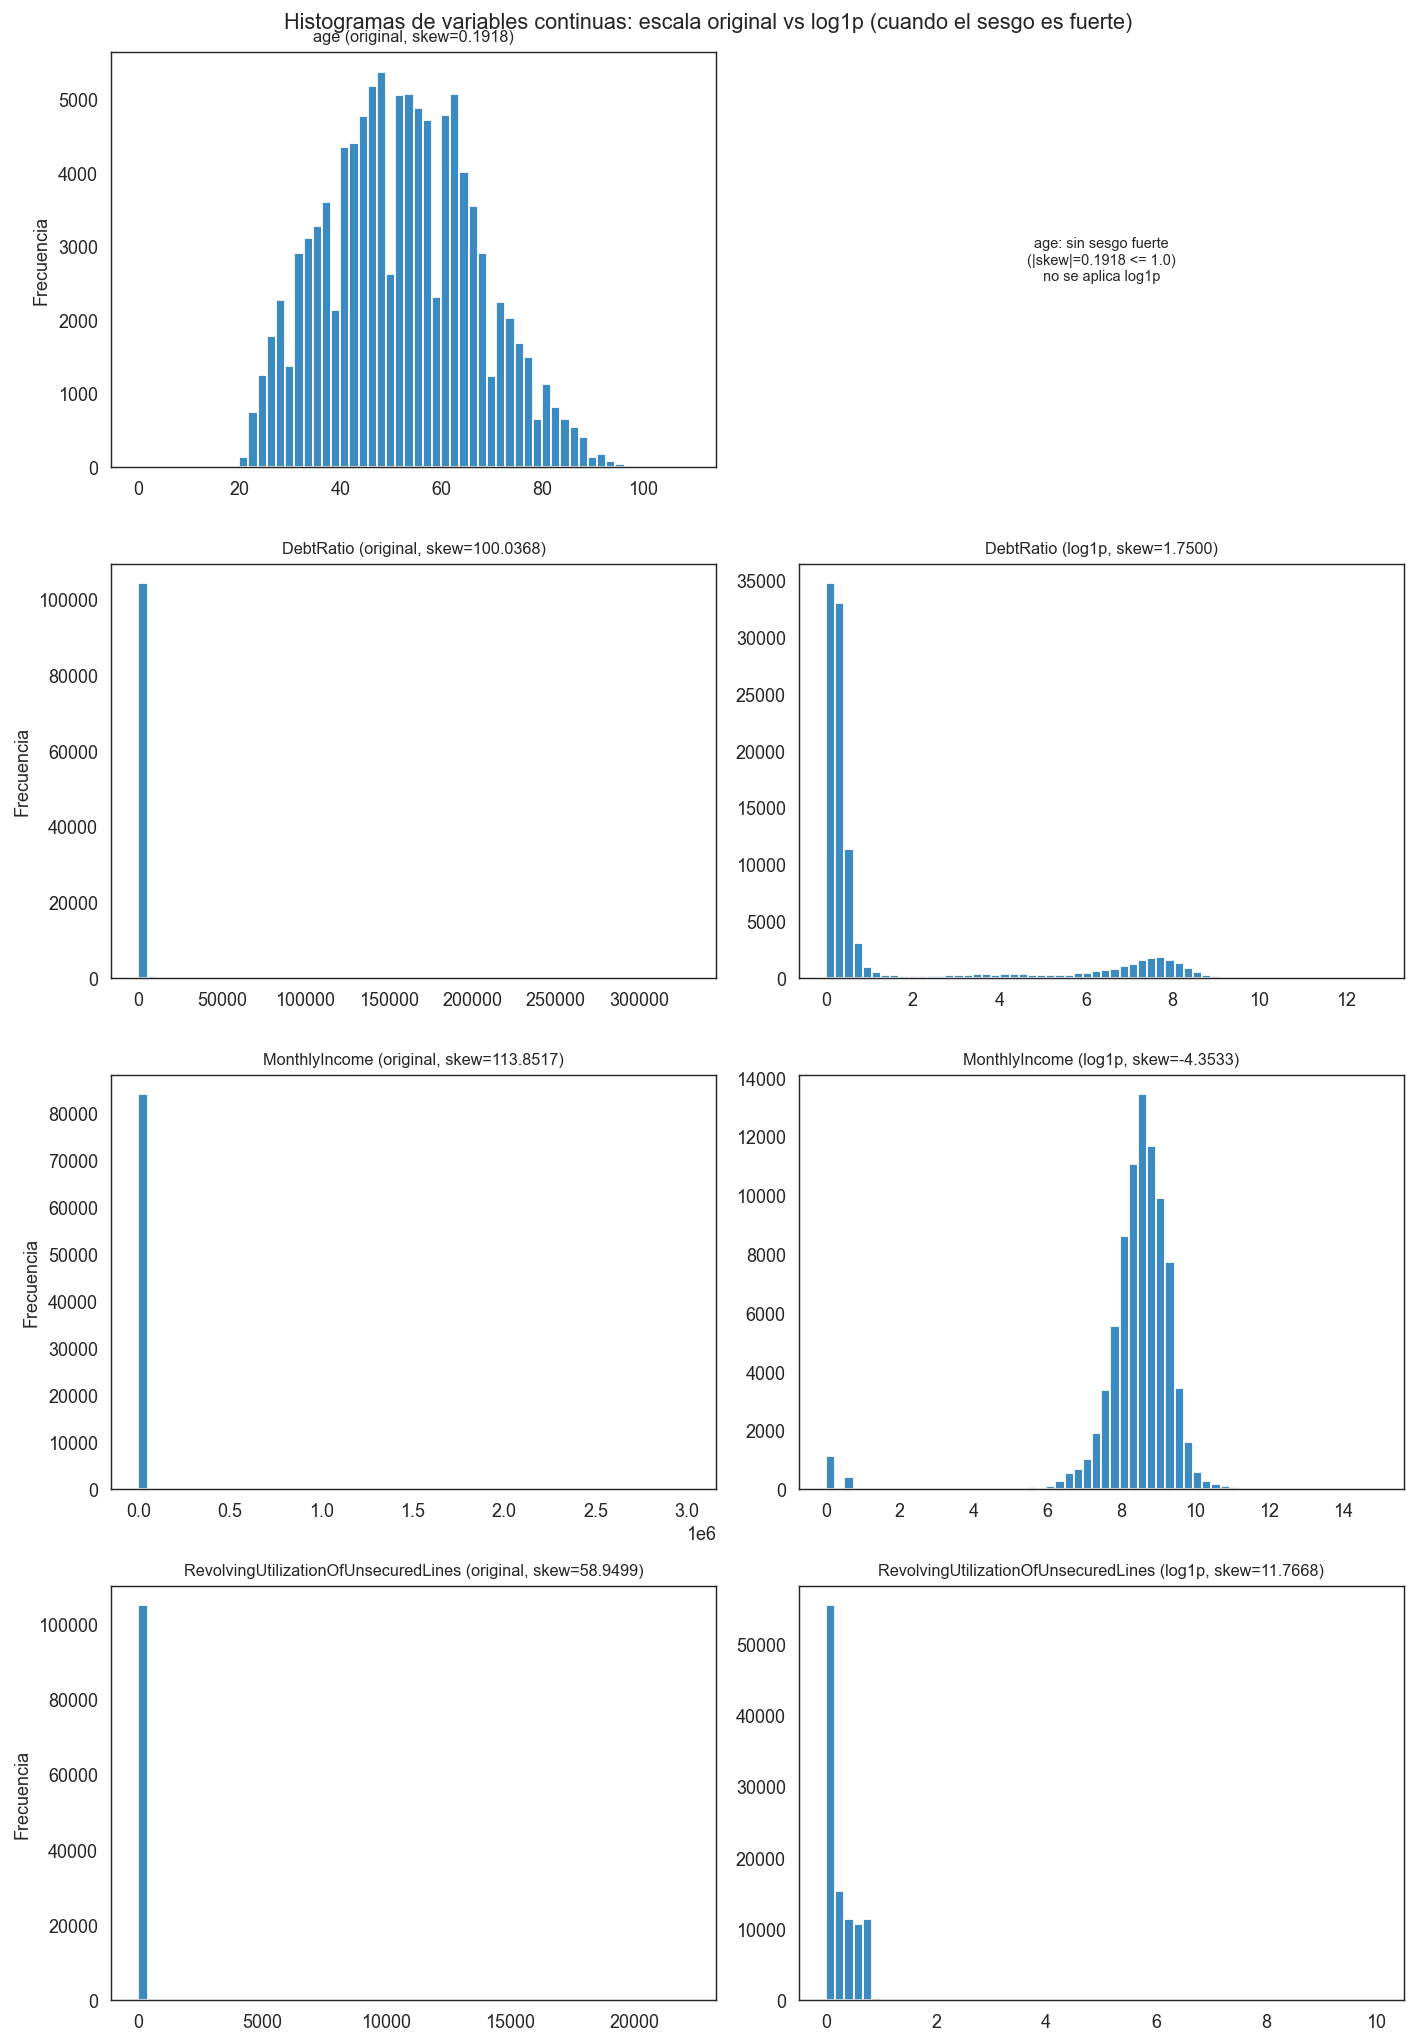

In [30]:
umbral_skew_fuerte = 1.0
vars_sesgo_fuerte = tabla_skew.index[tabla_skew["skew_original"].abs() > umbral_skew_fuerte].tolist()
print(f"Variables con sesgo fuerte (|skew| > {umbral_skew_fuerte}): {vars_sesgo_fuerte}")

fig, axes = plt.subplots(len(variables_continuas), 2, figsize=(11, 4 * len(variables_continuas)))
color_hist = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)

for i, col in enumerate(variables_continuas):
    ax_orig, ax_log = axes[i]
    valores = df_train[col].dropna()
    ax_orig.hist(valores, bins=60, color=color_hist)
    ax_orig.set_title(f"{col} (original, skew={tabla_skew.loc[col, 'skew_original']:.4f})", fontsize=9)
    ax_orig.set_ylabel("Frecuencia")

    if col in vars_sesgo_fuerte:
        ax_log.hist(np.log1p(valores.clip(lower=0)), bins=60, color=color_hist)
        ax_log.set_title(f"{col} (log1p, skew={tabla_skew.loc[col, 'skew_log1p']:.4f})", fontsize=9)
    else:
        ax_log.axis("off")
        ax_log.text(
            0.5, 0.5,
            f"{col}: sin sesgo fuerte\n(|skew|={abs(tabla_skew.loc[col, 'skew_original']):.4f} <= {umbral_skew_fuerte})\nno se aplica log1p",
            ha="center", va="center", fontsize=8, transform=ax_log.transAxes,
        )

fig.suptitle("Histogramas de variables continuas: escala original vs log1p (cuando el sesgo es fuerte)")
guardar_figura(fig, "04_histogramas_continuas_log1p")

**Hallazgo 4.1:** las variables continuas presentan sesgos muy distintos. `age` tiene un
`skew` original de 0.191780 (practicamente simetrico), mientras que
`RevolvingUtilizationOfUnsecuredLines` (58.949939), `DebtRatio` (100.036844) y
`MonthlyIncome` (113.851716) tienen un sesgo muy fuerte a la derecha, consistente con las
colas extremas ya documentadas en la seccion 3. Con el umbral `|skew| > 1.0`, estas 3
variables se marcan en `vars_sesgo_fuerte` y se les aplica `log1p`: su `skew` pasa a
11.766779, 1.749995 y -4.353312 respectivamente (en valor absoluto, muy por debajo del
original, aunque todavia lejos de 0 por las colas extremas de la seccion 3). En cambio,
aplicar `log1p` a `age` empeora su sesgo en valor absoluto (de 0.191780 a 0.456203), lo que
se refleja en que `reduce_skew_abs` es `False` unicamente para `age` en la tabla
`04_skew_variables_continuas`, y confirma numericamente por que solo conviene aplicar
`log1p` a las variables con sesgo fuerte.

### 4.2 Boxplot / violin plot de variables continuas por clase de `TARGET`

**Objetivo:** comparar la distribucion de cada variable continua entre las dos clases de
`SeriousDlqin2yrs` mediante violin plots coloreados con `COLOR_TARGET`, usando la escala
`log1p` para las variables marcadas como `vars_sesgo_fuerte` en 4.1 (para que la forma de la
distribucion sea visible pese a las colas extremas), y cuantificar la diferencia con la
mediana y la media de cada variable por clase.

In [31]:
estadisticos_continuas_por_target = df_train.groupby(TARGET)[variables_continuas].agg(["median", "mean"])
guardar_tabla(estadisticos_continuas_por_target, "04_estadisticos_continuas_por_target")
estadisticos_continuas_por_target

age            DebtRatio             MonthlyIncome  \
                 median       mean    median        mean        median   
SeriousDlqin2yrs                                                         
0                  52.0  52.679839  0.362483  357.752217        5457.0   
1                  45.0  45.824024  0.423806  304.014456        4500.0   

                              RevolvingUtilizationOfUnsecuredLines            
                         mean                               median      mean  
SeriousDlqin2yrs                                                              
0                 6774.255665                             0.133899  6.231423  
1                 5716.441797                             0.841845  4.967917

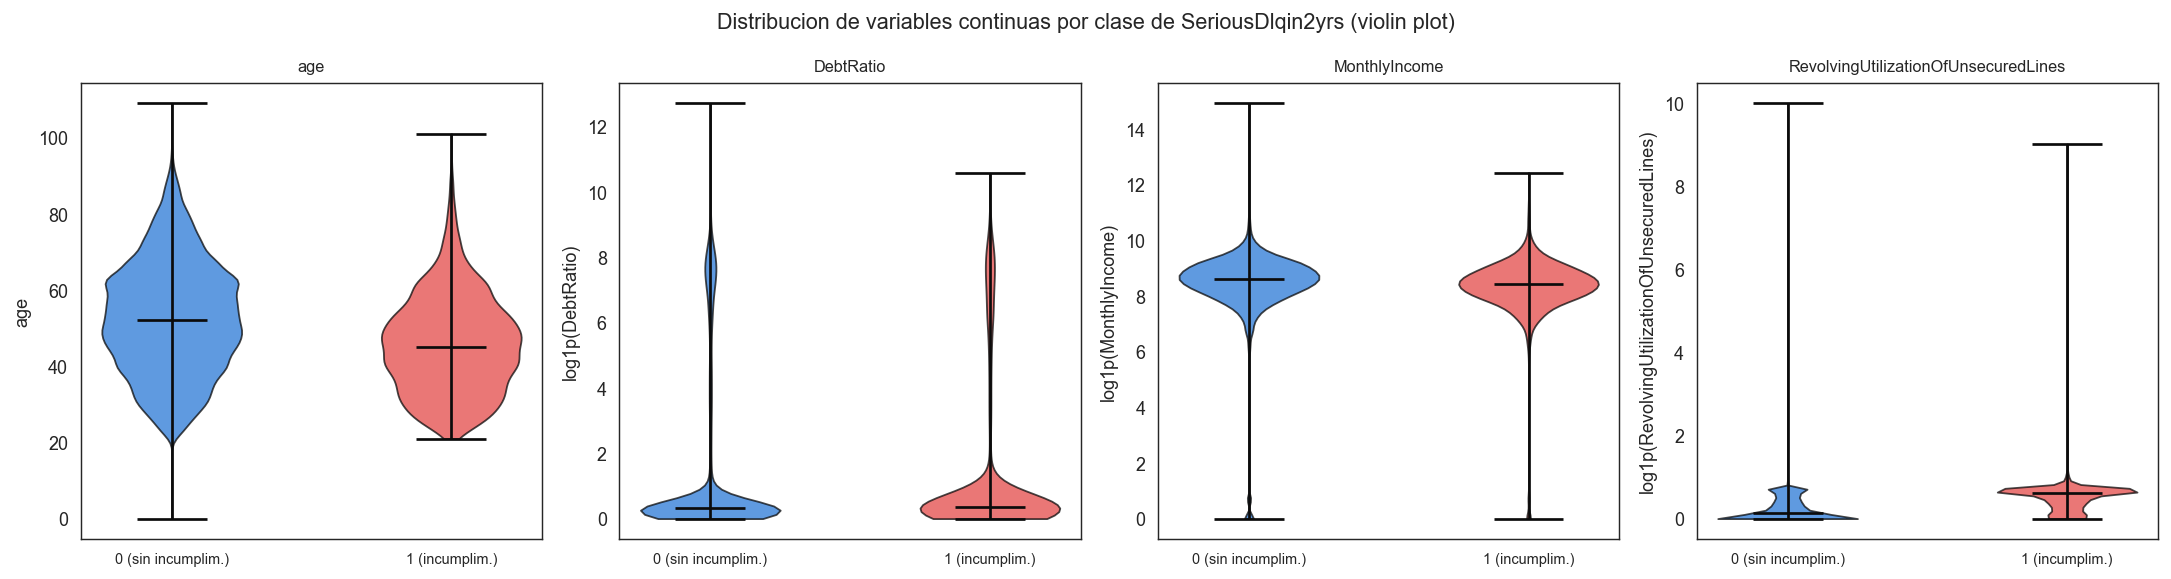

In [32]:
fig, axes = plt.subplots(1, len(variables_continuas), figsize=(4.2 * len(variables_continuas), 4.5))

for ax, col in zip(axes, variables_continuas):
    usar_log = col in vars_sesgo_fuerte
    datos_0 = df_train.loc[df_train[TARGET] == 0, col].dropna()
    datos_1 = df_train.loc[df_train[TARGET] == 1, col].dropna()
    if usar_log:
        datos_0 = np.log1p(datos_0.clip(lower=0))
        datos_1 = np.log1p(datos_1.clip(lower=0))
        etiqueta_y = f"log1p({col})"
    else:
        etiqueta_y = col

    partes = ax.violinplot([datos_0, datos_1], positions=[0, 1], showmedians=True)
    for cuerpo, clase in zip(partes["bodies"], [0, 1]):
        cuerpo.set_facecolor(COLOR_TARGET[clase])
        cuerpo.set_edgecolor(COLOR_INK_PRIMARY)
        cuerpo.set_alpha(0.75)
    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        partes[key].set_color(COLOR_INK_PRIMARY)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0 (sin incumplim.)", "1 (incumplim.)"], fontsize=8)
    ax.set_ylabel(etiqueta_y)
    ax.set_title(col, fontsize=9)

fig.suptitle(f"Distribucion de variables continuas por clase de {TARGET} (violin plot)")
guardar_figura(fig, "04_violin_continuas_por_target")

**Hallazgo 4.2:** la separacion mas clara por clase es la de
`RevolvingUtilizationOfUnsecuredLines`: la mediana en la clase 0 (sin incumplimiento) es
0.133899 frente a 0.841845 en la clase 1 (incumplimiento), es decir la mediana de la clase 1
es 6.29 veces la de la clase 0. Curiosamente la *media* muestra el patron opuesto
(6.231423 en clase 0 frente a 4.967917 en clase 1), lo que evidencia que la media de esta
variable esta distorsionada por las colas extremas de la seccion 3 (concentradas en la clase
0, que tiene casi 14 veces mas filas) y que la mediana (y el violin plot en escala `log1p`) es
mucho mas representativa de la relacion real con el target que la media. Para el resto de
variables la separacion por clase, aunque menor, va en la direccion esperada: `age` tiene una
mediana de 52.0 anios en la clase 0 frente a 45.0 en la clase 1 (los clientes que incumplen
son mas jovenes), `DebtRatio` tiene una mediana ligeramente mayor en la clase 1 (0.423806
frente a 0.362483) y `MonthlyIncome` una mediana menor en la clase 1 (4500.0 frente a 5457.0
en la clase 0).

### 4.3 Tasa de positivos por deciles de variables relevantes

**Objetivo:** dividir `RevolvingUtilizationOfUnsecuredLines`, `age` y `DebtRatio` en deciles
(`pd.qcut`, 10 grupos de tamano similar) y calcular la tasa de positivos (`mean` de
`SeriousDlqin2yrs`) en cada decil, para visualizar si la relacion con el target es monotona,
no monotona, o debil.

In [33]:
variables_deciles = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio"]
nombres_cortos_deciles = {
    "RevolvingUtilizationOfUnsecuredLines": "revolving",
    "age": "age",
    "DebtRatio": "debtratio",
}
resultados_deciles = {}

for col in variables_deciles:
    deciles = pd.qcut(df_train[col], 10, duplicates="drop")
    resumen = df_train.groupby(deciles, observed=True)[TARGET].agg(["mean", "count"])
    resumen = resumen.rename(columns={"mean": "tasa_positivos", "count": "n"})
    resumen.insert(0, "decil", range(1, len(resumen) + 1))
    resultados_deciles[col] = resumen
    guardar_tabla(resumen, f"04_tasa_positivos_deciles_{nombres_cortos_deciles[col]}")

for col in variables_deciles:
    r = resultados_deciles[col]
    ratio = r["tasa_positivos"].max() / r["tasa_positivos"].min()
    print(f"--- {col} ---")
    print(r)
    print(f"tasa min={r['tasa_positivos'].min():.6f} | tasa max={r['tasa_positivos'].max():.6f} | ratio max/min={ratio:.4f}")
    print()

--- RevolvingUtilizationOfUnsecuredLines ---
                                      decil  tasa_positivos      n
RevolvingUtilizationOfUnsecuredLines                              
(-0.001, 0.00305]                         1        0.025810  10500
(0.00305, 0.0193]                         2        0.014476  10500
(0.0193, 0.0435]                          3        0.013143  10500
(0.0435, 0.0835]                          4        0.019048  10500
(0.0835, 0.155]                           5        0.024000  10500
(0.155, 0.272]                            6        0.035048  10500
(0.272, 0.447]                            7        0.051238  10500
(0.447, 0.701]                            8        0.087333  10500
(0.701, 0.982]                            9        0.166095  10500
(0.982, 22198.0]                         10        0.232190  10500
tasa min=0.013143 | tasa max=0.232190 | ratio max/min=17.6667

--- age ---
                decil  tasa_positivos      n
age                            

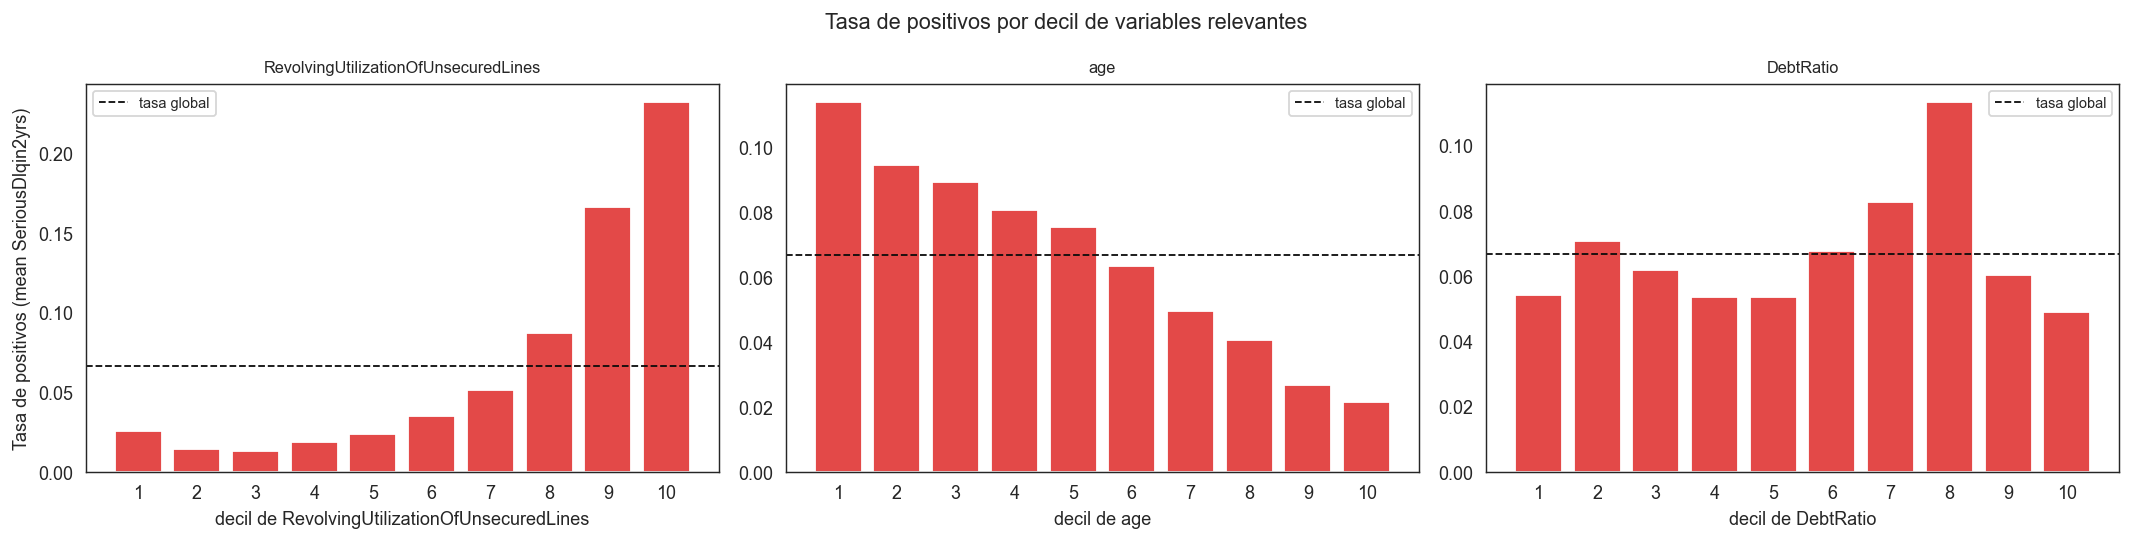

In [34]:
fig, axes = plt.subplots(1, len(variables_deciles), figsize=(5.5 * len(variables_deciles), 4.2))
tasa_global = df_train[TARGET].mean()

for ax, col in zip(axes, variables_deciles):
    r = resultados_deciles[col]
    ax.bar(r["decil"].astype(str), r["tasa_positivos"], color=COLOR_TARGET[1])
    ax.axhline(tasa_global, color=COLOR_INK_PRIMARY, linestyle="--", linewidth=1, label="tasa global")
    ax.set_xlabel(f"decil de {col}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Tasa de positivos (mean SeriousDlqin2yrs)")
fig.suptitle("Tasa de positivos por decil de variables relevantes")
guardar_figura(fig, "04_tasa_positivos_deciles")

**Hallazgo 4.3:** `RevolvingUtilizationOfUnsecuredLines` muestra la relacion mas fuerte con
el target: la tasa de positivos pasa de un minimo de 0.013143 (tercer decil) a un maximo de
0.232190 en el decil mas alto (utilizacion > 0.982), una razon de 17.6667 entre el decil de
mayor y menor tasa; la tendencia es claramente creciente en la segunda mitad de los deciles.
`age` muestra una relacion monotona decreciente y muy limpia: la tasa de positivos baja de
0.113957 en el decil mas joven (edad <= 33 anios) a 0.021700 en el decil de mayor edad
(72-109 anios), una razon de 5.2515. `DebtRatio` muestra una relacion mas debil y no monotona:
la tasa maxima (0.113454) no aparece en el ultimo decil sino en el octavo (rango 0.648-4.0),
mientras que el decil mas alto de `DebtRatio` (> 1281.0) tiene una de las tasas mas bajas
(0.048957, la razon global max/min es solo 2.3174); esto es coherente con el Hallazgo 3.3, que
ya vinculaba los valores mas extremos de `DebtRatio` a un artefacto de calculo por
`MonthlyIncome` nulo o casi nulo en vez de a un verdadero nivel de endeudamiento, lo que
diluye su relacion monotona con el riesgo de incumplimiento en la cola mas alta.

### 4.4 Comparacion `df_train` vs `df_prod`: posible *covariate shift*

**Objetivo:** comparar la distribucion de las 10 variables explicativas (todas menos el
target, que no existe en `df_prod`) entre `df_train` y `df_prod` mediante estadisticos lado a
lado (media, mediana, desviacion tipica, maximo) y un test de Kolmogorov-Smirnov de dos
muestras por variable; ademas, para las 4 variables continuas se superponen los histogramas
(en escala `log1p` cuando el sesgo es fuerte, ver 4.1) para inspeccionar visualmente la forma
de la distribucion en ambos conjuntos.

In [35]:
from scipy.stats import ks_2samp

cols_no_target = [c for c in df_train.columns if c != TARGET]

comparacion_train_prod = pd.DataFrame({
    "mean_train": df_train[cols_no_target].mean(),
    "mean_prod": df_prod[cols_no_target].mean(),
    "std_train": df_train[cols_no_target].std(),
    "std_prod": df_prod[cols_no_target].std(),
    "median_train": df_train[cols_no_target].median(),
    "median_prod": df_prod[cols_no_target].median(),
    "max_train": df_train[cols_no_target].max(),
    "max_prod": df_prod[cols_no_target].max(),
})
comparacion_train_prod["diff_mean_pct"] = (
    (comparacion_train_prod["mean_prod"] - comparacion_train_prod["mean_train"])
    / comparacion_train_prod["mean_train"].abs() * 100
)
comparacion_train_prod["diff_std_pct"] = (
    (comparacion_train_prod["std_prod"] - comparacion_train_prod["std_train"])
    / comparacion_train_prod["std_train"].abs() * 100
)

resultados_ks = []
for c in cols_no_target:
    estadistico, p_valor = ks_2samp(df_train[c].dropna(), df_prod[c].dropna())
    resultados_ks.append({"columna": c, "ks_stat": estadistico, "ks_pvalue": p_valor})
tabla_ks = pd.DataFrame(resultados_ks).set_index("columna")

comparacion_train_prod = comparacion_train_prod.join(tabla_ks).sort_values("ks_stat", ascending=False)
guardar_tabla(comparacion_train_prod, "04_comparacion_train_prod_describe")
comparacion_train_prod

,mean_train,mean_prod,std_train,std_prod,median_train,median_prod,max_train,max_prod,diff_mean_pct,diff_std_pct,ks_stat,ks_pvalue
age,52.221610,52.466933,14.765680,14.785030,52.000000,52.000000,109.0,109.0,0.469775,0.131045,0.007346,0.066434
DebtRatio,354.160487,350.309115,1999.455352,2124.660826,0.366143,0.367466,329664.0,307001.0,-1.087465,6.261979,0.005235,0.352606
RevolvingUtilizationOfUnsecuredLines,6.146972,5.818525,217.681366,312.029100,0.154674,0.153295,22198.0,50708.0,-5.343246,43.342127,0.004479,0.550753
NumberOfOpenCreditLinesAndLoans,8.440276,8.481889,5.130889,5.180867,8.000000,8.000000,58.0,57.0,0.493025,0.974064,0.004137,0.652295
NumberRealEstateLoansOrLines,1.016429,1.022467,1.133977,1.119896,1.000000,1.000000,54.0,32.0,0.594050,-1.241732,0.003600,0.807515
MonthlyIncome,6700.439214,6599.665983,15368.210022,11772.460712,5400.000000,5400.000000,3008750.0,1794060.0,-1.503979,-23.397320,0.003328,0.941619
NumberOfDependents,0.756850,0.758091,1.114183,1.117204,0.000000,0.000000,13.0,20.0,0.163965,0.271221,0.002229,0.997971
NumberOfTime60-89DaysPastDueNotWorse,0.239286,0.242956,4.151858,4.162964,0.000000,0.000000,98.0,98.0,1.533665,0.267491,0.001740,0.999979
NumberOfTime30-59DaysPastDueNotWorse,0.419933,0.423600,4.188991,4.201658,0.000000,0.000000,98.0,98.0,0.873154,0.302407,0.001203,1.000000
NumberOfTimes90DaysLate,0.265105,0.268000,4.166023,4.176994,0.000000,0.000000,98.0,98.0,1.092111,0.263322,0.000810,1.000000


Variables con diferencia train vs produccion significativa (test KS, p < 0.05): 0 de 10
Estadistico KS mas alto: age (KS=0.007346, p=0.066434)


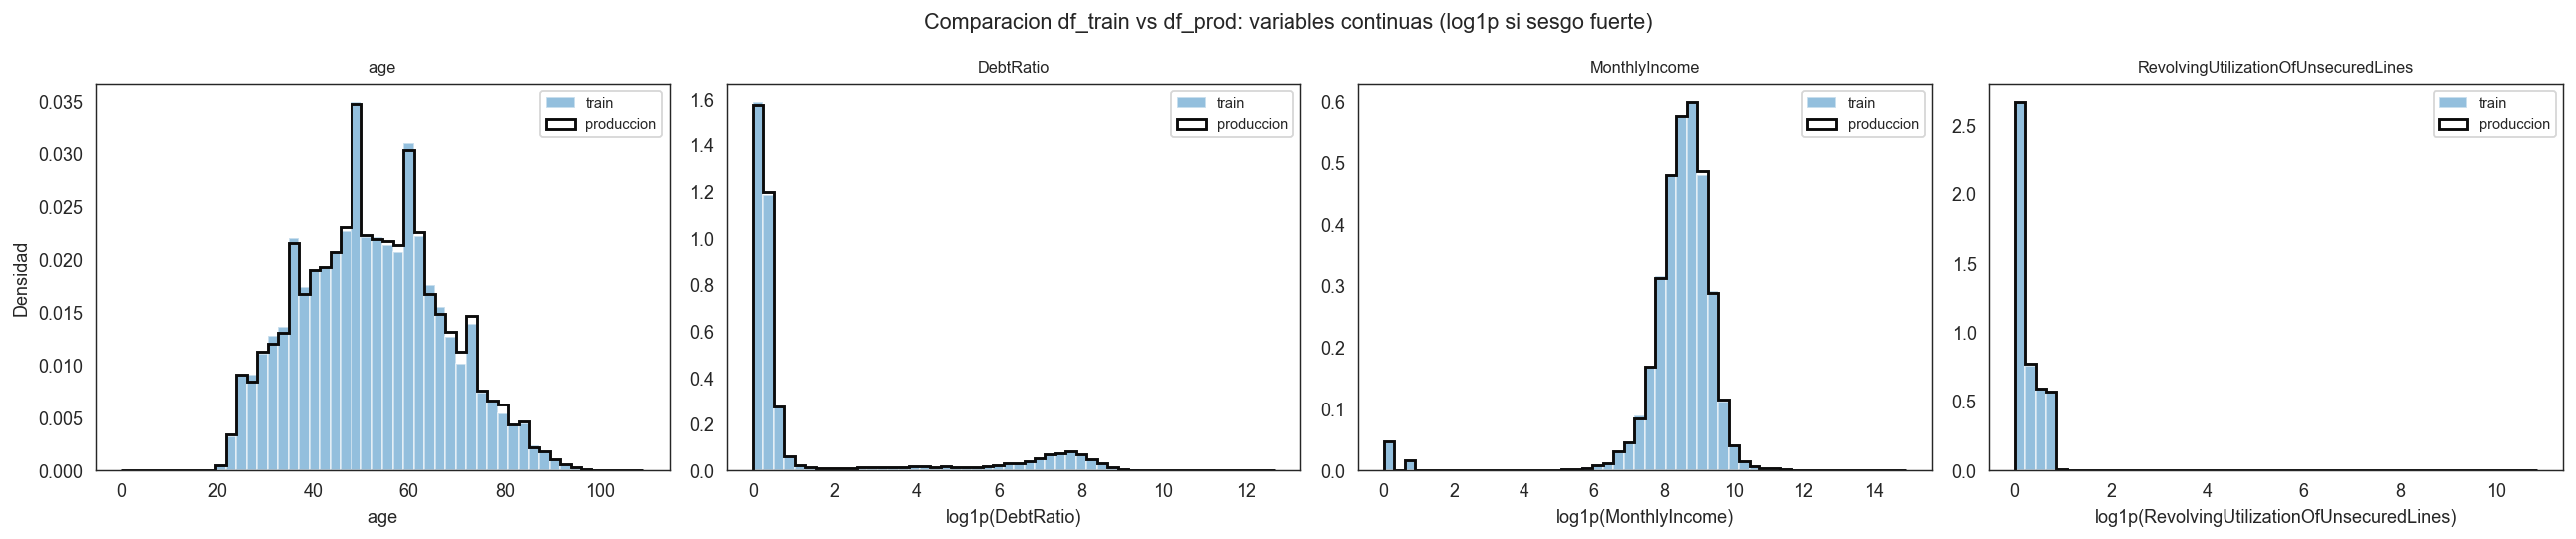

In [36]:
n_shift_significativo = int((comparacion_train_prod["ks_pvalue"] < 0.05).sum())
var_max_ks = comparacion_train_prod["ks_stat"].idxmax()
print(f"Variables con diferencia train vs produccion significativa (test KS, p < 0.05): "
      f"{n_shift_significativo} de {len(comparacion_train_prod)}")
print(f"Estadistico KS mas alto: {var_max_ks} "
      f"(KS={comparacion_train_prod.loc[var_max_ks, 'ks_stat']:.6f}, "
      f"p={comparacion_train_prod.loc[var_max_ks, 'ks_pvalue']:.6f})")

fig, axes = plt.subplots(1, len(variables_continuas), figsize=(5 * len(variables_continuas), 4.2))
color_train = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)
color_prod = COLOR_INK_PRIMARY

for ax, col in zip(axes, variables_continuas):
    usar_log = col in vars_sesgo_fuerte
    valores_train = df_train[col].dropna()
    valores_prod = df_prod[col].dropna()
    if usar_log:
        valores_train = np.log1p(valores_train.clip(lower=0))
        valores_prod = np.log1p(valores_prod.clip(lower=0))
        etiqueta_x = f"log1p({col})"
    else:
        etiqueta_x = col

    bins_compartidos = np.histogram_bin_edges(pd.concat([valores_train, valores_prod]), bins=50)
    ax.hist(valores_train, bins=bins_compartidos, density=True, alpha=0.55, color=color_train, label="train")
    ax.hist(valores_prod, bins=bins_compartidos, density=True, histtype="step", linewidth=1.6, color=color_prod, label="produccion")
    ax.set_xlabel(etiqueta_x)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Densidad")
fig.suptitle("Comparacion df_train vs df_prod: variables continuas (log1p si sesgo fuerte)")
guardar_figura(fig, "04_comparacion_train_prod_histogramas")

**Hallazgo 4.4:** el test de Kolmogorov-Smirnov no encuentra diferencia estadisticamente
significativa entre `df_train` y `df_prod` en ninguna de las 10 variables: 0 de 10 tienen
`ks_pvalue` < 0.05. La variable con el estadistico KS mas alto es `age`
(KS=0.007346, p=0.066434), un valor muy pequeno y no significativo al 5%, lo que indica que
la forma global de las distribuciones es muy similar entre train y produccion (no hay
evidencia de *covariate shift* en el grueso de la distribucion). Aun asi, la tabla
`04_comparacion_train_prod_describe` muestra algunas diferencias en las colas: la desviacion
tipica de `RevolvingUtilizationOfUnsecuredLines` es un 43.3421% mas alta en produccion
(217.681366 en train frente a 312.029100 en produccion) y su maximo tambien es mayor en
produccion (22198.0 en train frente a 50708.0 en produccion), mientras que `MonthlyIncome`
muestra el patron contrario: su desviacion tipica es un 23.3973% mas baja en produccion
(15368.210022 en train frente a 11772.460712) y su maximo tambien es menor (3008750.0 en
train frente a 1794060.0 en produccion). Estas diferencias de cola son coherentes con que
ambos datasets contienen un pequeno numero de valores extremos/centinela (seccion 3) cuya
magnitud varia de un conjunto a otro, mas que con un desplazamiento sistematico de la
distribucion; en terminos de media, la mayor diferencia relativa tambien es la de
`RevolvingUtilizationOfUnsecuredLines` (-5.343246%), seguida de `MonthlyIncome` (-1.503979%)
y `DebtRatio` (-1.087465%), todas ellas pequenas en comparacion con la escala de las propias
variables. En conjunto, no se observa una variable con un *covariate shift* claro entre
`df_train` y `df_prod`.

## 5. Correlaciones

Analizamos la correlacion lineal (Pearson) y monotona (Spearman) entre las 11 variables
numericas de `df_train`, con foco en (a) la relacion de cada variable con `TARGET` y
(b) posibles pares de variables redundantes entre si (multicolinealidad).

### 5.1 Matriz de correlacion de Pearson

**Objetivo:** calcular y visualizar la correlacion lineal de Pearson entre las 11 variables
numericas de `df_train` (incluyendo `TARGET`) con un heatmap anotado en `CMAP_DIVERGING`.

In [37]:
columnas_correlacion = df_train.columns.tolist()
corr_pearson = df_train[columnas_correlacion].corr(method="pearson")
guardar_tabla(corr_pearson, "05_matriz_correlacion_pearson")
corr_pearson

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,1.000000,-0.001450,-0.115957,0.124281,-0.006712,-0.017537,-0.028591,0.116431,-0.006769,0.101721,0.047383
RevolvingUtilizationOfUnsecuredLines,-0.001450,1.000000,-0.009995,-0.001582,0.008392,0.004125,-0.014794,-0.001165,0.008032,-0.001154,0.005982
age,-0.115957,-0.009995,1.000000,-0.062952,0.025437,0.033379,0.149369,-0.060883,0.034604,-0.057117,-0.212331
NumberOfTime30-59DaysPastDueNotWorse,0.124281,-0.001582,-0.062952,1.000000,-0.006837,-0.009424,-0.055458,0.983735,-0.030710,0.987144,-0.001913
DebtRatio,-0.006712,0.008392,0.025437,-0.006837,1.000000,-0.027470,0.051399,-0.008512,0.122153,-0.007680,-0.043901
MonthlyIncome,-0.017537,0.004125,0.033379,-0.009424,-0.027470,1.000000,0.085243,-0.011982,0.119253,-0.010411,0.062565
NumberOfOpenCreditLinesAndLoans,-0.028591,-0.014794,0.149369,-0.055458,0.051399,0.085243,1.000000,-0.080110,0.433759,-0.071175,0.063825
NumberOfTimes90DaysLate,0.116431,-0.001165,-0.060883,0.983735,-0.008512,-0.011982,-0.080110,1.000000,-0.044943,0.992858,-0.009624
NumberRealEstateLoansOrLines,-0.006769,0.008032,0.034604,-0.030710,0.122153,0.119253,0.433759,-0.044943,1.000000,-0.039599,0.122007
NumberOfTime60-89DaysPastDueNotWorse,0.101721,-0.001154,-0.057117,0.987144,-0.007680,-0.010411,-0.071175,0.992858,-0.039599,1.000000,-0.010255


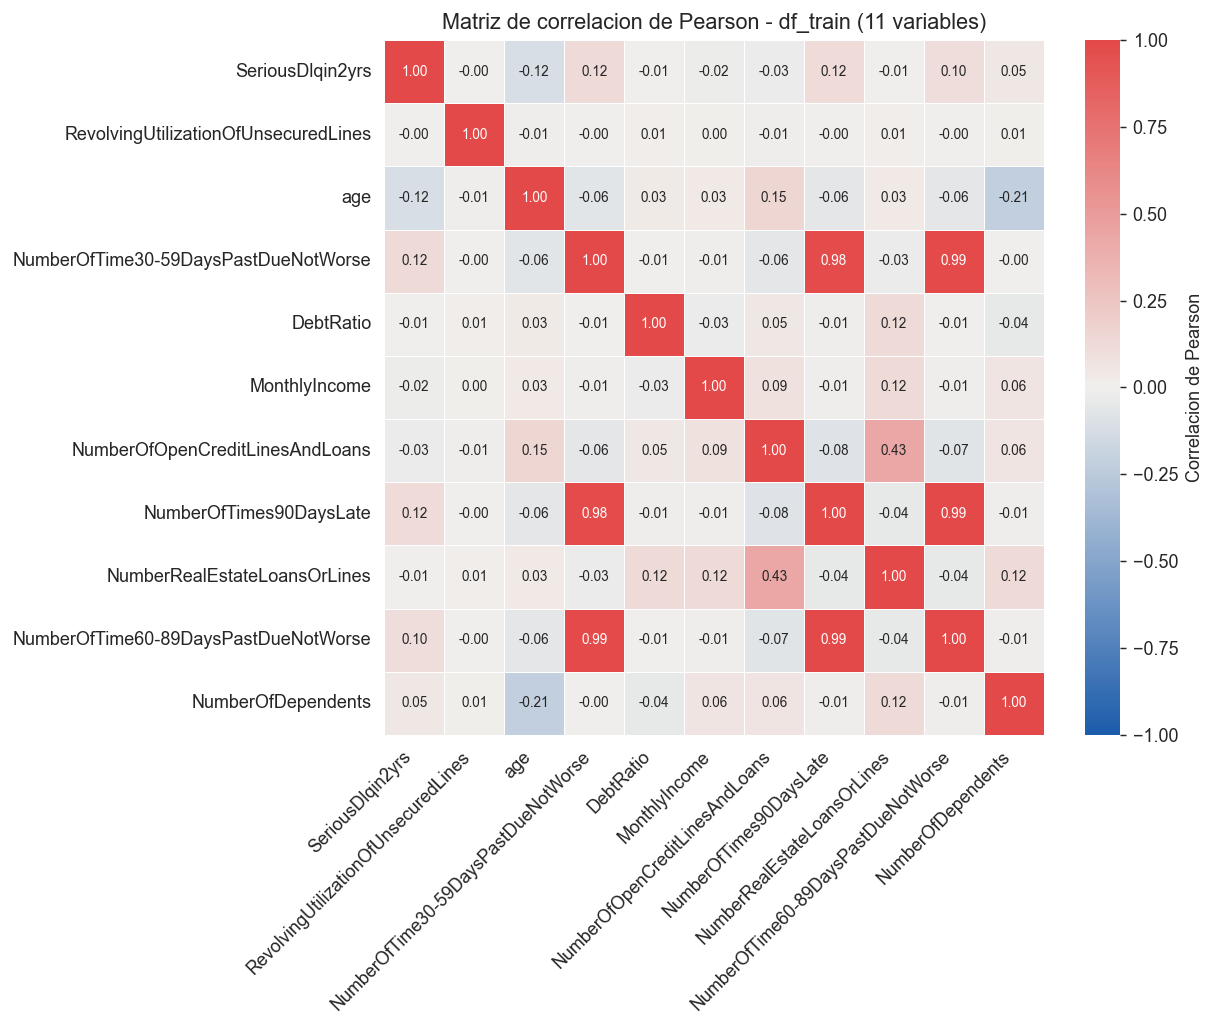

In [38]:
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(
    corr_pearson,
    cmap=CMAP_DIVERGING,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"fontsize": 7.5},
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Correlacion de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de correlacion de Pearson - df_train (11 variables)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
guardar_figura(fig, "05_heatmap_correlacion_pearson")

**Hallazgo 5.1:** las 3 correlaciones de Pearson mas altas en valor absoluto (fuera de la
diagonal) son entre las variables de incidencias de pago: `NumberOfTimes90DaysLate` vs
`NumberOfTime60-89DaysPastDueNotWorse` (0.992858), `NumberOfTime30-59DaysPastDueNotWorse` vs
`NumberOfTime60-89DaysPastDueNotWorse` (0.987144) y `NumberOfTime30-59DaysPastDueNotWorse` vs
`NumberOfTimes90DaysLate` (0.983735), las 3 por encima de 0.98; esto ya apunta a una posible
multicolinealidad entre las 3 variables `NumberOfTime*PastDue*`, que se cuantifica en la
seccion 5.4. Frente al `TARGET`, la correlacion de Pearson mas alta en valor absoluto es la de
`NumberOfTime30-59DaysPastDueNotWorse` (0.124281), seguida de `NumberOfTimes90DaysLate`
(0.116431) y `age` (-0.115957); en el otro extremo, `RevolvingUtilizationOfUnsecuredLines`
(-0.001450), `DebtRatio` (-0.006712) y `NumberRealEstateLoansOrLines` (-0.006769) muestran una
correlacion de Pearson practicamente nula con el target, algo que se contrasta con Spearman en
las secciones 5.2 y 5.3.

### 5.2 Matriz de correlacion de Spearman (contraste)

**Objetivo:** repetir el heatmap de correlacion con Spearman (basada en rangos) para
contrastar con Pearson y detectar relaciones monotonas que Pearson pueda estar subestimando
o sobreestimando por efecto de valores extremos.

In [39]:
corr_spearman = df_train[columnas_correlacion].corr(method="spearman")
guardar_tabla(corr_spearman, "05_matriz_correlacion_spearman")
corr_spearman

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,1.000000,0.239712,-0.117643,0.256113,0.017887,-0.064827,-0.038323,0.341830,-0.034200,0.281481,0.047540
RevolvingUtilizationOfUnsecuredLines,0.239712,1.000000,-0.279870,0.234504,0.074468,-0.078054,-0.084721,0.235135,-0.025311,0.183588,0.118909
age,-0.117643,-0.279870,1.000000,-0.093292,0.030772,0.135805,0.160448,-0.101670,0.057577,-0.084078,-0.226573
NumberOfTime30-59DaysPastDueNotWorse,0.256113,0.234504,-0.093292,1.000000,0.035475,-0.014271,0.062783,0.252906,0.019737,0.276242,0.070638
DebtRatio,0.017887,0.074468,0.030772,0.035475,1.000000,-0.132330,0.228083,-0.035048,0.402648,-0.001620,-0.037307
MonthlyIncome,-0.064827,-0.078054,0.135805,-0.014271,-0.132330,1.000000,0.310436,-0.089144,0.391048,-0.052617,0.203367
NumberOfOpenCreditLinesAndLoans,-0.038323,-0.084721,0.160448,0.062783,0.228083,0.310436,1.000000,-0.135547,0.472365,-0.048992,0.098040
NumberOfTimes90DaysLate,0.341830,0.235135,-0.101670,0.252906,-0.035048,-0.089144,-0.135547,1.000000,-0.103420,0.324101,0.030288
NumberRealEstateLoansOrLines,-0.034200,-0.025311,0.057577,0.019737,0.402648,0.391048,0.472365,-0.103420,1.000000,-0.045929,0.163349
NumberOfTime60-89DaysPastDueNotWorse,0.281481,0.183588,-0.084078,0.276242,-0.001620,-0.052617,-0.048992,0.324101,-0.045929,1.000000,0.034505


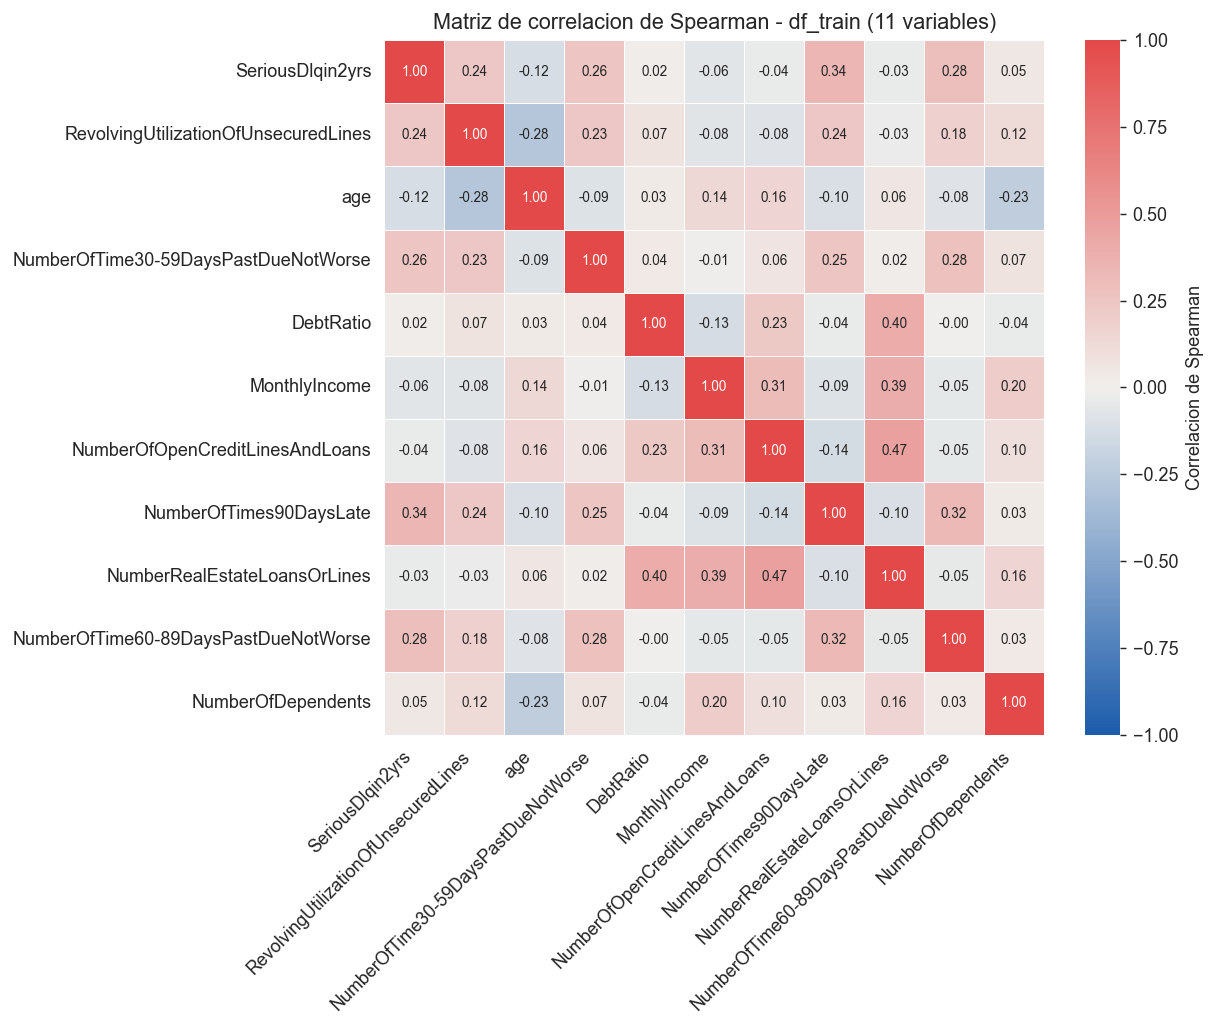

In [40]:
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(
    corr_spearman,
    cmap=CMAP_DIVERGING,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"fontsize": 7.5},
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Correlacion de Spearman"},
    ax=ax,
)
ax.set_title("Matriz de correlacion de Spearman - df_train (11 variables)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
guardar_figura(fig, "05_heatmap_correlacion_spearman")

**Hallazgo 5.2:** las mismas 3 parejas de variables de incidencias de pago siguen siendo las
de mayor magnitud bajo Spearman, pero caen mucho respecto a Pearson: `NumberOfTimes90DaysLate`
vs `NumberOfTime60-89DaysPastDueNotWorse` pasa de 0.992858 a 0.324101 (caida de 0.668757),
`NumberOfTime30-59DaysPastDueNotWorse` vs `NumberOfTime60-89DaysPastDueNotWorse` pasa de
0.987144 a 0.276242 (caida de 0.710903), y `NumberOfTime30-59DaysPastDueNotWorse` vs
`NumberOfTimes90DaysLate` pasa de 0.983735 a 0.252906 (caida de 0.730829); estas son, con
diferencia, las 3 mayores caidas de todo el conjunto de pares de variables (seccion 5.4). En
sentido contrario, `RevolvingUtilizationOfUnsecuredLines` pasa de una correlacion de Pearson
practicamente nula con `age` (-0.009995) a -0.279870 en Spearman (diferencia de 0.269875), y
su correlacion con el propio `TARGET` cambia de signo entre metodos (Pearson -0.001450 frente
a Spearman +0.239712), lo que se analiza en detalle en la seccion 5.3.

### 5.3 Correlacion de cada variable con el TARGET: Pearson vs Spearman

**Objetivo:** construir una tabla ordenada con la correlacion de Pearson y de Spearman de
cada variable frente a `TARGET`, para comparar el ranking de relevancia lineal frente al
monotono y detectar variables donde ambos metodos difieren mucho.

In [41]:
variables_sin_target = [c for c in columnas_correlacion if c != TARGET]

tabla_corr_target = pd.DataFrame({
    "pearson_vs_target": corr_pearson.loc[variables_sin_target, TARGET],
    "spearman_vs_target": corr_spearman.loc[variables_sin_target, TARGET],
})
tabla_corr_target["diff_abs_pearson_spearman"] = (
    tabla_corr_target["pearson_vs_target"] - tabla_corr_target["spearman_vs_target"]
).abs()
tabla_corr_target = tabla_corr_target.reindex(
    tabla_corr_target["pearson_vs_target"].abs().sort_values(ascending=False).index
)
guardar_tabla(tabla_corr_target, "05_correlacion_target_pearson_spearman")
tabla_corr_target

,pearson_vs_target,spearman_vs_target,diff_abs_pearson_spearman
NumberOfTime30-59DaysPastDueNotWorse,0.124281,0.256113,0.131832
NumberOfTimes90DaysLate,0.116431,0.341830,0.225398
age,-0.115957,-0.117643,0.001686
NumberOfTime60-89DaysPastDueNotWorse,0.101721,0.281481,0.179760
NumberOfDependents,0.047383,0.047540,0.000157
NumberOfOpenCreditLinesAndLoans,-0.028591,-0.038323,0.009731
MonthlyIncome,-0.017537,-0.064827,0.047290
NumberRealEstateLoansOrLines,-0.006769,-0.034200,0.027430
DebtRatio,-0.006712,0.017887,0.024599
RevolvingUtilizationOfUnsecuredLines,-0.001450,0.239712,0.241162


In [42]:
ranking_pearson = tabla_corr_target["pearson_vs_target"].abs().rank(ascending=False)
ranking_spearman = tabla_corr_target["spearman_vs_target"].abs().rank(ascending=False)

var_max_diff = tabla_corr_target["diff_abs_pearson_spearman"].idxmax()
var_min_diff = tabla_corr_target["diff_abs_pearson_spearman"].idxmin()

print(f"Variable con mayor diferencia |Pearson - Spearman| frente al target: {var_max_diff}")
print(f"  pearson={tabla_corr_target.loc[var_max_diff, 'pearson_vs_target']:.6f} | "
      f"spearman={tabla_corr_target.loc[var_max_diff, 'spearman_vs_target']:.6f} | "
      f"diff={tabla_corr_target.loc[var_max_diff, 'diff_abs_pearson_spearman']:.6f}")
print(f"  ranking (1=mayor |correlacion| de {len(tabla_corr_target)}): "
      f"puesto {int(ranking_pearson[var_max_diff])} en Pearson vs "
      f"puesto {int(ranking_spearman[var_max_diff])} en Spearman")
print()
print(f"Variable con menor diferencia |Pearson - Spearman| frente al target: {var_min_diff}")
print(f"  pearson={tabla_corr_target.loc[var_min_diff, 'pearson_vs_target']:.6f} | "
      f"spearman={tabla_corr_target.loc[var_min_diff, 'spearman_vs_target']:.6f} | "
      f"diff={tabla_corr_target.loc[var_min_diff, 'diff_abs_pearson_spearman']:.6f}")

Variable con mayor diferencia |Pearson - Spearman| frente al target: RevolvingUtilizationOfUnsecuredLines
  pearson=-0.001450 | spearman=0.239712 | diff=0.241162
  ranking (1=mayor |correlacion| de 10): puesto 10 en Pearson vs puesto 4 en Spearman

Variable con menor diferencia |Pearson - Spearman| frente al target: NumberOfDependents
  pearson=0.047383 | spearman=0.047540 | diff=0.000157


**Hallazgo 5.3:** la variable con mayor diferencia absoluta entre Pearson y Spearman frente
al target es `RevolvingUtilizationOfUnsecuredLines`: su correlacion de Pearson es
practicamente nula (-0.001450, puesto 10 de 10 en valor absoluto) mientras que su correlacion
de Spearman es 0.239712 (puesto 4 de 10), una diferencia de 0.241162 y ademas un cambio de
signo. Esto es coherente con el Hallazgo 3.3 (valores extremos de
`RevolvingUtilizationOfUnsecuredLines` muy fuera de rango) y con el Hallazgo 4.3 (la tasa de
positivos por decil de esta variable crece de forma monotona, con una razon de 17.6667 entre
el decil mas alto y el mas bajo): la relacion monotona con el target es real y la capta
Spearman, pero los outliers extremos distorsionan el coeficiente de Pearson hasta casi
anularlo. En el extremo opuesto, `NumberOfDependents` es la variable mas estable entre
metodos (pearson=0.047383, spearman=0.047540, diff=0.000157), lo que indica una relacion
aproximadamente lineal bien capturada por ambos coeficientes. Por magnitud,
`NumberOfTime30-59DaysPastDueNotWorse` es la variable con mayor correlacion de Pearson con el
target (0.124281), mientras que `NumberOfTimes90DaysLate` es la de mayor correlacion de
Spearman (0.341830); las 3 variables `NumberOfTime*PastDue*` ocupan 3 de los 4 primeros
puestos del ranking en ambos metodos (el cuarto puesto lo ocupa `age` bajo Pearson y
`RevolvingUtilizationOfUnsecuredLines` bajo Spearman), confirmando que son, en conjunto, las
variables individualmente mas relacionadas con el riesgo de incumplimiento, aunque el orden
exacto cambia segun el tipo de correlacion usado.

### 5.4 Multicolinealidad entre variables y diferencias Pearson vs Spearman

**Objetivo:** examinar todos los pares de variables explicativas (sin `TARGET`) para
identificar pares con correlacion fuerte entre si (posible multicolinealidad) y pares donde
Pearson y Spearman difieren mucho (indicio de relacion no lineal o monotona no lineal).

In [43]:
pares_variables = []
for i, v1 in enumerate(variables_sin_target):
    for v2 in variables_sin_target[i + 1:]:
        pares_variables.append({
            "var1": v1,
            "var2": v2,
            "pearson": corr_pearson.loc[v1, v2],
            "spearman": corr_spearman.loc[v1, v2],
        })
tabla_pares_variables = pd.DataFrame(pares_variables)
tabla_pares_variables["diff_abs_pearson_spearman"] = (
    tabla_pares_variables["pearson"] - tabla_pares_variables["spearman"]
).abs()
tabla_pares_variables = tabla_pares_variables.reindex(
    tabla_pares_variables["pearson"].abs().sort_values(ascending=False).index
).reset_index(drop=True)
guardar_tabla(tabla_pares_variables, "05_pares_correlacion_variables")
tabla_pares_variables.head(10)

,var1,var2,pearson,spearman,diff_abs_pearson_spearman
0,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,0.992858,0.324101,0.668757
1,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,0.987144,0.276242,0.710903
2,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,0.983735,0.252906,0.730829
3,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,0.433759,0.472365,0.038607
4,age,NumberOfDependents,-0.212331,-0.226573,0.014242
5,age,NumberOfOpenCreditLinesAndLoans,0.149369,0.160448,0.011079
6,DebtRatio,NumberRealEstateLoansOrLines,0.122153,0.402648,0.280496
7,NumberRealEstateLoansOrLines,NumberOfDependents,0.122007,0.163349,0.041342
8,MonthlyIncome,NumberRealEstateLoansOrLines,0.119253,0.391048,0.271795
9,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,0.085243,0.310436,0.225193


In [44]:
umbral_multicolinealidad = 0.7
pares_fuertes = tabla_pares_variables[tabla_pares_variables["pearson"].abs() > umbral_multicolinealidad]
print(f"Pares de variables con |Pearson| > {umbral_multicolinealidad}: "
      f"{len(pares_fuertes)} de {len(tabla_pares_variables)}")
print(pares_fuertes[["var1", "var2", "pearson", "spearman", "diff_abs_pearson_spearman"]].to_string(index=False))
print()

top_diff_pares = tabla_pares_variables.reindex(
    tabla_pares_variables["diff_abs_pearson_spearman"].sort_values(ascending=False).index
).head(5)
print("Pares con mayor diferencia |Pearson - Spearman|:")
print(top_diff_pares[["var1", "var2", "pearson", "spearman", "diff_abs_pearson_spearman"]].to_string(index=False))

Pares de variables con |Pearson| > 0.7: 3 de 45
                                var1                                 var2  pearson  spearman  diff_abs_pearson_spearman
             NumberOfTimes90DaysLate NumberOfTime60-89DaysPastDueNotWorse 0.992858  0.324101                   0.668757
NumberOfTime30-59DaysPastDueNotWorse NumberOfTime60-89DaysPastDueNotWorse 0.987144  0.276242                   0.710903
NumberOfTime30-59DaysPastDueNotWorse              NumberOfTimes90DaysLate 0.983735  0.252906                   0.730829

Pares con mayor diferencia |Pearson - Spearman|:
                                var1                                 var2  pearson  spearman  diff_abs_pearson_spearman
NumberOfTime30-59DaysPastDueNotWorse              NumberOfTimes90DaysLate 0.983735  0.252906                   0.730829
NumberOfTime30-59DaysPastDueNotWorse NumberOfTime60-89DaysPastDueNotWorse 0.987144  0.276242                   0.710903
             NumberOfTimes90DaysLate NumberOfTime60-89DaysPast

**Hallazgo 5.4:** de los 45 pares posibles entre las 10 variables explicativas, exactamente
3 superan el umbral `|Pearson| > 0.7`, y los 3 son entre las variables `NumberOfTime*PastDue*`:
`NumberOfTimes90DaysLate` vs `NumberOfTime60-89DaysPastDueNotWorse` (0.992858),
`NumberOfTime30-59DaysPastDueNotWorse` vs `NumberOfTime60-89DaysPastDueNotWorse` (0.987144) y
`NumberOfTime30-59DaysPastDueNotWorse` vs `NumberOfTimes90DaysLate` (0.983735); el cuarto par
mas correlacionado, `NumberOfOpenCreditLinesAndLoans` vs `NumberRealEstateLoansOrLines`
(0.433759), ya esta muy por debajo del umbral. Esto senala una posible multicolinealidad clara
y aislada en la familia de variables de incidencias de pago, coherente con el Hallazgo 3.1
(las mismas filas presentan el valor centinela 96/98 en las 3 columnas simultaneamente).
Precisamente esos mismos 3 pares son, con diferencia, los que mas difieren entre Pearson y
Spearman de los 45: 0.730829 (`NumberOfTime30-59DaysPastDueNotWorse` vs
`NumberOfTimes90DaysLate`), 0.710903 (`NumberOfTime30-59DaysPastDueNotWorse` vs
`NumberOfTime60-89DaysPastDueNotWorse`) y 0.668757 (`NumberOfTimes90DaysLate` vs
`NumberOfTime60-89DaysPastDueNotWorse`), lo que sugiere que su Pearson tan alto esta inflado
por el peso de unos pocos valores centinela extremos compartidos (Hallazgo 3.1) mas que por
una relacion lineal limpia en todo el rango; el Spearman, mucho menos sensible a esos valores
extremos, sigue siendo positivo pero mucho mas moderado (0.252906-0.324101). El cuarto par con
mayor diferencia, ya sin relacion con la familia `PastDue`, es `DebtRatio` vs
`NumberRealEstateLoansOrLines` (Pearson=0.122153, Spearman=0.402648, diff=0.280496),
consistente con el sesgo extremo de `DebtRatio` ya documentado en los Hallazgos 3.3 y 4.1.

### 5.5 Factor de Inflacion de Varianza (VIF): multicolinealidad multivariante

**Objetivo:** las subsecciones 5.1-5.4 miden multicolinealidad de forma bivariante
(par a par): matrices de correlacion de Pearson (5.1) y Spearman (5.2), correlacion de cada
variable con el target (5.3) y un umbral `|Pearson| > 0.7` sobre los 45 pares posibles entre
las 10 variables explicativas (5.4). Sin embargo, la correlacion por pares no detecta
redundancia que involucre a 3 o mas variables simultaneamente: una variable puede tener
correlacion pareada moderada con cada una de las demas y aun asi ser casi una combinacion
lineal del resto. El Factor de Inflacion de Varianza (VIF) de cada variable mide cuanta de su
varianza explican CONJUNTAMENTE todas las demas variables (se obtiene regresionando esa
variable contra el resto y usando el R^2 de esa regresion: `VIF = 1 / (1 - R^2)`), y permite
confirmar o matizar lo visto en el Hallazgo 5.4 sobre la familia `NumberOfTime*PastDue*`.

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

cols_vif = [c for c in df_train.columns if c != TARGET]
df_vif_input = df_train[cols_vif].copy()

print("Nulos por columna antes de imputar (df_vif_input):")
print(df_vif_input.isna().sum())

medianas_vif = df_vif_input.median()
df_vif_imputado = df_vif_input.fillna(medianas_vif)

print()
print("Nulos por columna despues de imputar (df_vif_imputado):")
print(df_vif_imputado.isna().sum())

X_vif = sm.add_constant(df_vif_imputado)

tabla_vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
tabla_vif = tabla_vif[tabla_vif["variable"] != "const"]
tabla_vif = tabla_vif.sort_values("VIF", ascending=False).reset_index(drop=True)
guardar_tabla(tabla_vif, "05_vif_multicolinealidad")
tabla_vif

Nulos por columna antes de imputar (df_vif_input):
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20795
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2738
dtype: int64

Nulos por columna despues de imputar (df_vif_imputado):
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0

,variable,VIF
0,NumberOfTime60-89DaysPastDueNotWorse,92.303728
1,NumberOfTimes90DaysLate,73.680754
2,NumberOfTime30-59DaysPastDueNotWorse,41.285570
3,NumberOfOpenCreditLinesAndLoans,1.285608
4,NumberRealEstateLoansOrLines,1.272430
5,age,1.085454
6,NumberOfDependents,1.080016
7,DebtRatio,1.020237
8,MonthlyIncome,1.018162
9,RevolvingUtilizationOfUnsecuredLines,1.000622


In [46]:
umbral_vif_moderado = 5
umbral_vif_severo = 10

n_vif_moderado = int(((tabla_vif["VIF"] > umbral_vif_moderado) & (tabla_vif["VIF"] <= umbral_vif_severo)).sum())
n_vif_severo = int((tabla_vif["VIF"] > umbral_vif_severo).sum())

print(f"Variables con VIF > {umbral_vif_moderado} y <= {umbral_vif_severo} (moderado): {n_vif_moderado} de {len(tabla_vif)}")
print(f"Variables con VIF > {umbral_vif_severo} (severo): {n_vif_severo} de {len(tabla_vif)}")
print()

cols_pastdue_vif = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
print("VIF de la familia NumberOfTime*PastDue* (senaladas en el Hallazgo 5.4 con Pearson ~0.99 entre ellas):")
print(tabla_vif[tabla_vif["variable"].isin(cols_pastdue_vif)].to_string(index=False))

Variables con VIF > 5 y <= 10 (moderado): 0 de 10
Variables con VIF > 10 (severo): 3 de 10

VIF de la familia NumberOfTime*PastDue* (senaladas en el Hallazgo 5.4 con Pearson ~0.99 entre ellas):
                            variable       VIF
NumberOfTime60-89DaysPastDueNotWorse 92.303728
             NumberOfTimes90DaysLate 73.680754
NumberOfTime30-59DaysPastDueNotWorse 41.285570


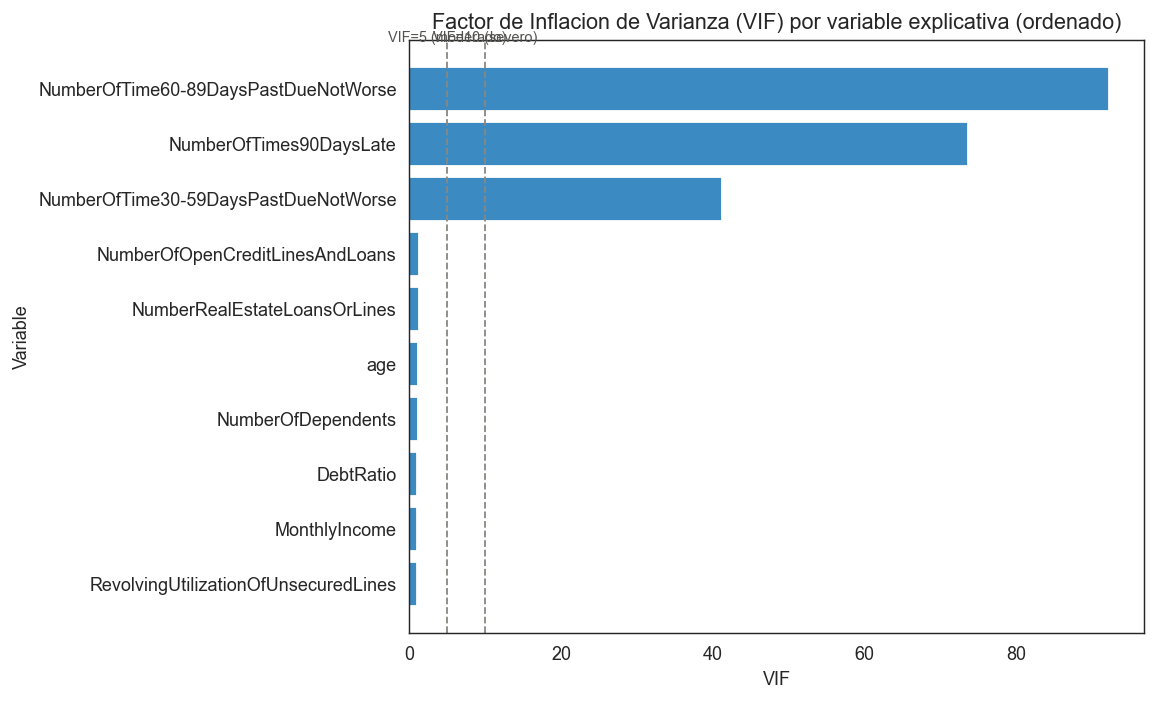

In [47]:
tabla_vif_plot = tabla_vif.sort_values("VIF", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(tabla_vif_plot["variable"], tabla_vif_plot["VIF"], color=plt.get_cmap(CMAP_SEQUENTIAL)(0.65))

ylim_top = len(tabla_vif_plot) - 0.5
for umbral, texto in [(umbral_vif_moderado, "moderado"), (umbral_vif_severo, "severo")]:
    ax.axvline(umbral, color=COLOR_MUTED, linestyle="--", linewidth=1)
    ax.text(umbral, ylim_top + 0.35, f"VIF={umbral} ({texto})", ha="center", fontsize=8, color=COLOR_INK_SECONDARY)

ax.set_xlabel("VIF")
ax.set_ylabel("Variable")
ax.set_title("Factor de Inflacion de Varianza (VIF) por variable explicativa (ordenado)")
guardar_figura(fig, "05_vif_barras")

**Hallazgo 5.5:** el VIF confirma el diagnostico bivariante del Hallazgo 5.4 y lo agrava: de
las 10 variables explicativas, 3 presentan multicolinealidad severa (`VIF > 10`) y ninguna cae
en la franja moderada (`5 < VIF <= 10`), de modo que toda la redundancia del dataset esta
concentrada en la familia `NumberOfTime*PastDue*`: `NumberOfTime60-89DaysPastDueNotWorse`
(92.303728), `NumberOfTimes90DaysLate` (73.680754) y `NumberOfTime30-59DaysPastDueNotWorse`
(41.285570). El resto de variables tiene un VIF practicamente igual a 1 (de 1.000622 en
`RevolvingUtilizationOfUnsecuredLines` a 1.285608 en `NumberOfOpenCreditLinesAndLoans`), es
decir, no aportan redundancia apreciable. Dado que `VIF = 1 / (1 - R^2)`, esos valores implican
que las otras nueve variables explican conjuntamente el 98.9166% de la varianza de
`NumberOfTime60-89DaysPastDueNotWorse`, el 98.6427% de la de `NumberOfTimes90DaysLate` y el
97.5779% de la de `NumberOfTime30-59DaysPastDueNotWorse`: cada una de las tres es casi una
combinacion lineal exacta de las demas, algo que la lectura par a par de la subseccion 5.4
sugeria pero no podia cuantificar. Dos matices importan para no sobreinterpretar la cifra. El
primero es metodologico: el VIF exige una matriz sin nulos, por lo que se calculo tras imputar
temporalmente `MonthlyIncome` (20795 nulos) y `NumberOfDependents` (2738 nulos) con su mediana;
las tres columnas `PastDue` no tienen nulos, asi que esa imputacion no influye en sus VIF. El
segundo es sustantivo: el VIF, como Pearson, solo mide dependencia lineal, y el Hallazgo 5.4 ya
mostro que el Pearson de estas tres columnas (~0.99) esta inflado por las 188 filas con el valor
centinela 96/98 simultaneo (Hallazgo 3.1), mientras que su Spearman se queda en 0.252906-0.324101.
Cabe esperar por tanto que estos VIF severos esten inflados por el mismo artefacto y no por una
redundancia real en el rango de valores validos; la seccion 7.4 lo confirma indirectamente al
ver que la varianza explicada por PC1 -eje dominado precisamente por las tres `PastDue`- cae del
29.9519% al 19.2023% en cuanto se excluyen esas filas. La consecuencia practica se traslada a
`02_preprocesado.ipynb` y a la decision **D-0.3**: el tratamiento de los centinelas debe preceder
a cualquier reevaluacion de la colinealidad, y solo si tras ese tratamiento el VIF sigue siendo
severo tendria sentido consolidar las tres columnas en una sola (o quedarse con
`NumberOfTimes90DaysLate`, la de mayor Spearman con el target segun el Hallazgo 5.3). En todo
caso, esta advertencia solo aplica a modelos sensibles a la multicolinealidad -lineales,
logisticos o un bandit contextual lineal, donde infla la varianza de los coeficientes y hace
inestable su interpretacion-, no a los modelos basados en arboles, cuya capacidad predictiva es
indiferente a que dos variables sean redundantes (aunque si reparte entre ellas la importancia
atribuida, algo a tener presente al interpretar SHAP en `07_shap.ipynb`).

### 5.6 Interacciones entre pares de variables: mas alla de la correlacion lineal simple

**Objetivo:** las subsecciones 5.1-5.5 miden asociacion lineal o monotona entre pares de
variables (Pearson en 5.1, Spearman en 5.2, correlacion de cada variable con el target en 5.3)
y multicolinealidad bivariante (5.4) y multivariante (VIF en 5.5). Ninguna de ellas responde a
dos preguntas distintas: (1) si existe dependencia NO lineal o no monotona entre dos variables
explicativas que Pearson y Spearman, al medir solo asociacion lineal/monotona, puedan pasar por
alto (para eso se usa aqui informacion mutua, que no asume ninguna forma funcional concreta), y
(2) si el EFECTO conjunto de dos variables sobre el target difiere de la simple suma de sus
efectos individuales (interaccion o sinergia), algo que ninguna correlacion par a par entre
variables explicativas puede detectar porque no involucra al target de forma conjunta. Esta
subseccion cruza pares de variables en 2D -extendiendo el analisis por deciles de una sola
variable de la subseccion 4.3- para cuantificar ambos fenomenos y decidir si el modelo final
necesita capturar interacciones explicitas.

In [48]:
from sklearn.feature_selection import mutual_info_regression

medianas_mi = df_train[variables_sin_target].median()
df_mi_imputado = df_train[variables_sin_target].fillna(medianas_mi)

matriz_mi = pd.DataFrame(index=variables_sin_target, columns=variables_sin_target, dtype=float)
for col in variables_sin_target:
    predictoras = [c for c in variables_sin_target if c != col]
    mi_valores = mutual_info_regression(
        df_mi_imputado.drop(columns=[col]), df_mi_imputado[col], random_state=RANDOM_STATE
    )
    matriz_mi.loc[col, predictoras] = mi_valores

# La MI teorica es simetrica (MI(X, Y) == MI(Y, X)), pero el estimador de
# mutual_info_regression (basado en distancias k-NN sobre cada variable objetivo por
# separado) no garantiza esa simetria exacta en la practica: matriz_mi.loc[X, Y] y
# matriz_mi.loc[Y, X] provienen de dos regresiones distintas y pueden diferir ligeramente.
# Se simetriza promediando la matriz con su transpuesta (la diagonal queda en NaN).
matriz_mi_sym = (matriz_mi + matriz_mi.T) / 2
guardar_tabla(matriz_mi_sym, "05_matriz_informacion_mutua")
matriz_mi_sym

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
RevolvingUtilizationOfUnsecuredLines,NaN,0.061900,0.043033,0.141624,0.027843,0.111405,0.042656,0.027461,0.027395,0.013937
age,0.061900,NaN,0.008455,0.078382,0.084184,0.057465,0.005747,0.069918,0.004280,0.093913
NumberOfTime30-59DaysPastDueNotWorse,0.043033,0.008455,NaN,0.015181,0.001186,0.010243,0.032809,0.003955,0.037367,0.004888
DebtRatio,0.141624,0.078382,0.015181,NaN,0.561762,0.157549,0.006900,0.332460,0.005837,0.048669
MonthlyIncome,0.027843,0.084184,0.001186,0.561762,NaN,0.059572,0.006732,0.076534,0.003237,0.055240
NumberOfOpenCreditLinesAndLoans,0.111405,0.057465,0.010243,0.157549,0.059572,NaN,0.018993,0.143323,0.007884,0.010705
NumberOfTimes90DaysLate,0.042656,0.005747,0.032809,0.006900,0.006732,0.018993,NaN,0.012178,0.034709,0.002027
NumberRealEstateLoansOrLines,0.027461,0.069918,0.003955,0.332460,0.076534,0.143323,0.012178,NaN,0.002266,0.014573
NumberOfTime60-89DaysPastDueNotWorse,0.027395,0.004280,0.037367,0.005837,0.003237,0.007884,0.034709,0.002266,NaN,0.000002
NumberOfDependents,0.013937,0.093913,0.004888,0.048669,0.055240,0.010705,0.002027,0.014573,0.000002,NaN


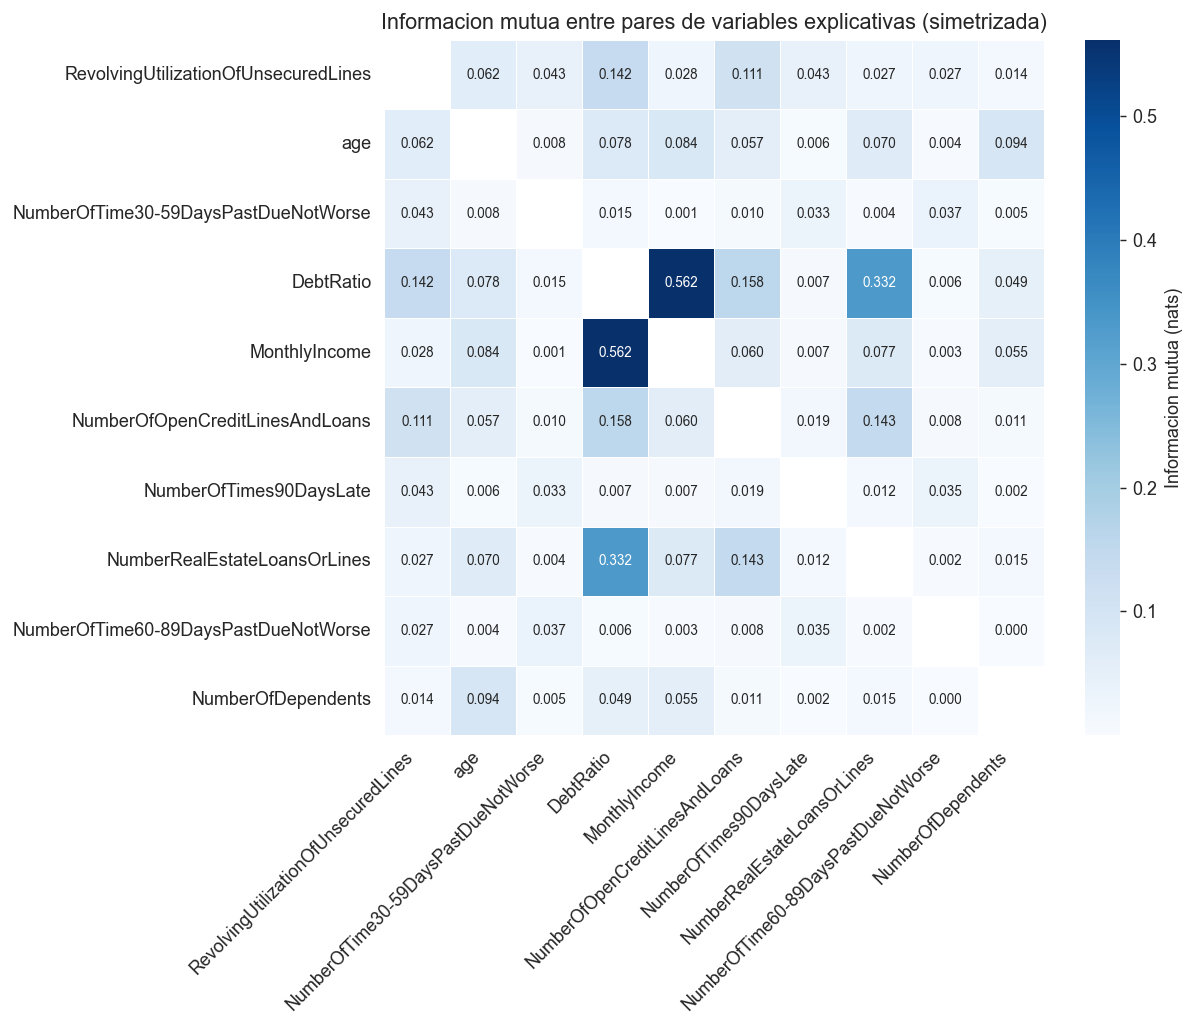

In [49]:
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(
    matriz_mi_sym.astype(float),
    cmap=CMAP_SEQUENTIAL,  # la MI es siempre >= 0 (a diferencia de Pearson/Spearman, que van de -1 a 1)
    annot=True, fmt=".3f", annot_kws={"fontsize": 7.5},
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Informacion mutua (nats)"},
    ax=ax,
)
ax.set_title("Informacion mutua entre pares de variables explicativas (simetrizada)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
guardar_figura(fig, "05_heatmap_informacion_mutua")

In [50]:
mi_pares = matriz_mi_sym.stack()  # stack() descarta la diagonal (NaN) por defecto
par_max_mi = mi_pares.idxmax()
valor_max_mi = mi_pares.max()

# tabla_pares_variables (subseccion 5.4) ya esta ordenada por |Pearson| descendente
par_max_pearson_fila = tabla_pares_variables.iloc[0]

print(f"Par con mayor informacion mutua: {par_max_mi[0]} <-> {par_max_mi[1]} (MI={valor_max_mi:.4f} nats)")
print(
    f"Par con mayor |Pearson| (Hallazgo 5.4): {par_max_pearson_fila['var1']} <-> "
    f"{par_max_pearson_fila['var2']} (pearson={par_max_pearson_fila['pearson']:.6f})"
)

coincide_mi_pearson = {par_max_mi[0], par_max_mi[1]} == {
    par_max_pearson_fila["var1"], par_max_pearson_fila["var2"]
}
print(f"Coincide el par de mayor MI con el par de mayor |Pearson|: {coincide_mi_pearson}")

Par con mayor informacion mutua: DebtRatio <-> MonthlyIncome (MI=0.5618 nats)
Par con mayor |Pearson| (Hallazgo 5.4): NumberOfTimes90DaysLate <-> NumberOfTime60-89DaysPastDueNotWorse (pearson=0.992858)
Coincide el par de mayor MI con el par de mayor |Pearson|: False


In [51]:
def preparar_bins(variable, q=5):
    serie = df_train[variable]
    if variable in vars_sesgo_fuerte:
        # log1p sobre el valor no negativo, para tener bins con sentido en variables
        # con sesgo fuerte (misma logica que en las subsecciones 4.1/9.1)
        serie = np.log1p(serie.clip(lower=0))
    return pd.qcut(serie, q=q, duplicates="drop")


def tasa_target_por_bins_2d(var_x, var_y, q=5):
    bins_x = preparar_bins(var_x, q=q)
    bins_y = preparar_bins(var_y, q=q)
    return df_train.groupby([bins_x, bins_y], observed=True)[TARGET].mean().unstack() * 100


pares_interaccion = [
    ("RevolvingUtilizationOfUnsecuredLines", "age"),
    ("DebtRatio", "NumberOfDependents"),
]

tablas_interaccion_2d = {}
for var_x, var_y in pares_interaccion:
    tabla_2d = tasa_target_por_bins_2d(var_x, var_y, q=5)
    tablas_interaccion_2d[(var_x, var_y)] = tabla_2d
    guardar_tabla(tabla_2d, f"05_interaccion_tasa_target_{var_x}_{var_y}")

print("Tasa de positivos (%) por quintiles cruzados de RevolvingUtilizationOfUnsecuredLines x age:")
display(tablas_interaccion_2d[pares_interaccion[0]])
print()
print("Tasa de positivos (%) por quintiles cruzados de DebtRatio x NumberOfDependents:")
display(tablas_interaccion_2d[pares_interaccion[1]])

Tasa de positivos (%) por quintiles cruzados de RevolvingUtilizationOfUnsecuredLines x age:


age,"(-0.001, 39.0]","(39.0, 48.0]","(48.0, 56.0]","(56.0, 65.0]","(65.0, 109.0]"
RevolvingUtilizationOfUnsecuredLines,,,,,
"(-0.001, 0.0191]",3.185509,2.887302,2.388489,1.631034,1.081493
"(0.0191, 0.0802]",2.307970,2.120766,1.811321,1.361634,1.057479
"(0.0802, 0.24]",4.178744,3.393565,2.798807,2.302190,1.948983
"(0.24, 0.531]",7.824575,7.777995,7.445640,5.269825,4.757589
"(0.531, 10.008]",22.255680,21.684376,20.191822,16.281441,10.245902



Tasa de positivos (%) por quintiles cruzados de DebtRatio x NumberOfDependents:


NumberOfDependents,"(-0.001, 1.0]","(1.0, 2.0]","(2.0, 13.0]"
DebtRatio,,,
"(-0.001, 0.126]",5.483133,9.619450,12.184250
"(0.126, 0.252]",5.436477,6.064356,7.588533
"(0.252, 0.383]",5.788938,6.867762,6.504702
"(0.383, 1.609]",9.171111,10.901526,13.274746
"(1.609, 12.706]",5.386445,5.946792,7.276736


In [52]:
tasa_global_pct = df_train[TARGET].mean() * 100
print(f"Tasa global de positivos: {tasa_global_pct:.4f}%")
print()

resultados_aditividad = []
for var_x, var_y in pares_interaccion:
    tabla_2d = tablas_interaccion_2d[(var_x, var_y)]
    bins_x = preparar_bins(var_x, q=5)
    bins_y = preparar_bins(var_y, q=5)
    marginal_x_pct = df_train.groupby(bins_x, observed=True)[TARGET].mean() * 100
    marginal_y_pct = df_train.groupby(bins_y, observed=True)[TARGET].mean() * 100

    tabla_apilada = tabla_2d.stack()
    bin_x_max, bin_y_max = tabla_apilada.idxmax()
    tasa_observada = tabla_apilada.max()

    tasa_esperada = (
        tasa_global_pct
        + (marginal_x_pct.loc[bin_x_max] - tasa_global_pct)
        + (marginal_y_pct.loc[bin_y_max] - tasa_global_pct)
    )
    diferencia = tasa_observada - tasa_esperada
    resultados_aditividad.append({
        "var_x": var_x, "var_y": var_y,
        "bin_x_max": str(bin_x_max), "bin_y_max": str(bin_y_max),
        "tasa_observada_pct": tasa_observada, "tasa_esperada_aditiva_pct": tasa_esperada,
        "diferencia_pct": diferencia,
    })

    print(f"--- {var_x} x {var_y} ---")
    print(f"Combinacion con mayor tasa observada: {var_x} en {bin_x_max} | {var_y} en {bin_y_max}")
    print(f"  tasa observada        = {tasa_observada:.4f}%")
    print(f"  tasa esperada (aditiva) = {tasa_esperada:.4f}%")
    print(f"  diferencia (observado - esperado) = {diferencia:+.4f} puntos porcentuales")
    print()

tabla_resumen_aditividad = pd.DataFrame(resultados_aditividad)
guardar_tabla(tabla_resumen_aditividad, "05_interaccion_resumen_aditividad")
tabla_resumen_aditividad

Tasa global de positivos: 6.6838%

--- RevolvingUtilizationOfUnsecuredLines x age ---
Combinacion con mayor tasa observada: RevolvingUtilizationOfUnsecuredLines en (0.531, 10.008] | age en (-0.001, 39.0]
  tasa observada        = 22.2557%
  tasa esperada (aditiva) = 23.7186%
  diferencia (observado - esperado) = -1.4629 puntos porcentuales



--- DebtRatio x NumberOfDependents ---
Combinacion con mayor tasa observada: DebtRatio en (0.383, 1.609] | NumberOfDependents en (2.0, 13.0]
  tasa observada        = 13.2747%
  tasa esperada (aditiva) = 12.3861%
  diferencia (observado - esperado) = +0.8887 puntos porcentuales



,var_x,var_y,bin_x_max,bin_y_max,tasa_observada_pct,tasa_esperada_aditiva_pct,diferencia_pct
0,RevolvingUtilizationOfUnsecuredLines,age,"(0.531, 10.008]","(-0.001, 39.0]",22.255680,23.718594,-1.462914
1,DebtRatio,NumberOfDependents,"(0.383, 1.609]","(2.0, 13.0]",13.274746,12.386089,0.888657


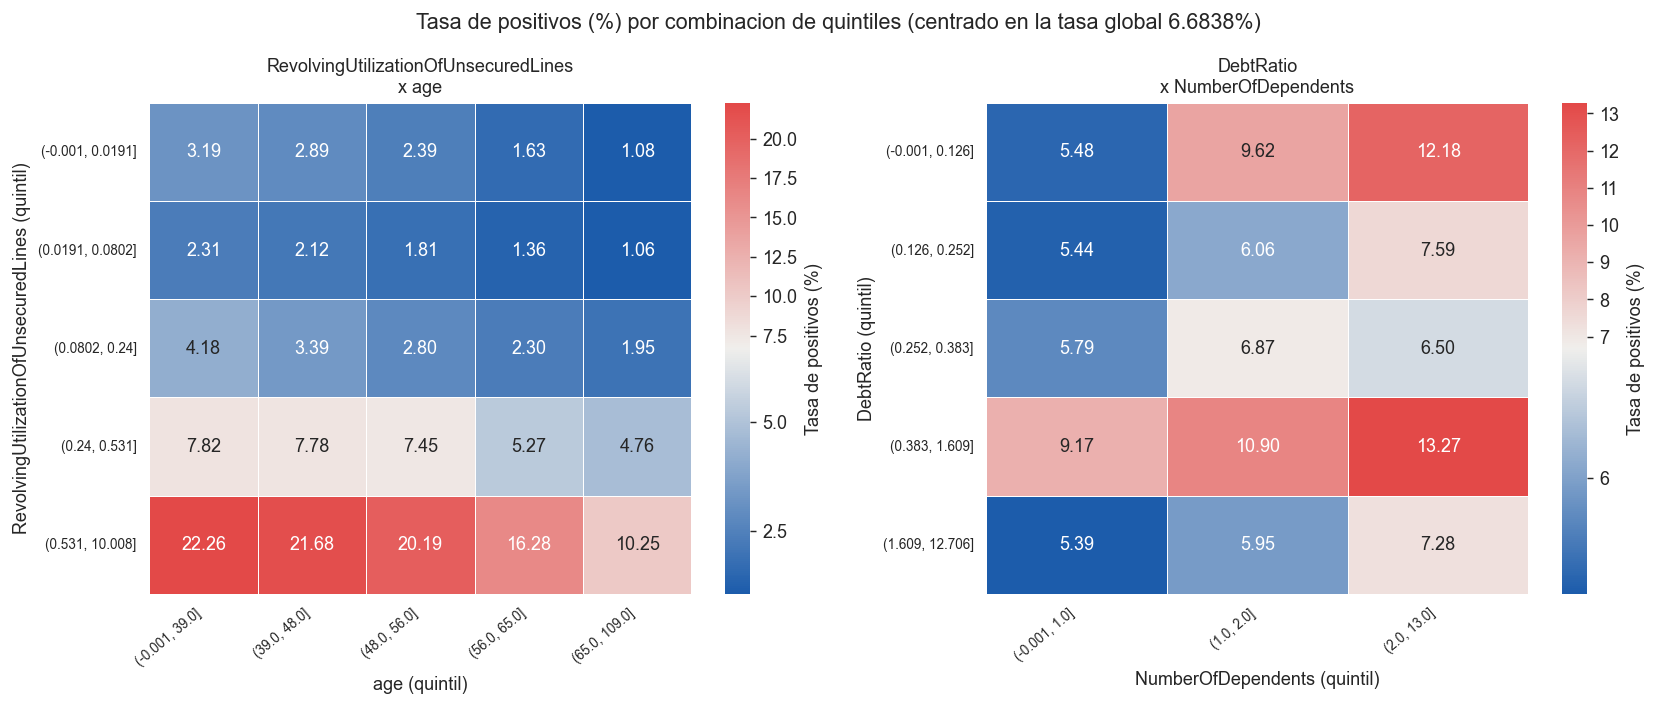

In [53]:
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (var_x, var_y) in zip(axes, pares_interaccion):
    tabla_2d = tablas_interaccion_2d[(var_x, var_y)]
    vmin = min(tabla_2d.min().min(), tasa_global_pct - 1e-6)
    vmax = max(tabla_2d.max().max(), tasa_global_pct + 1e-6)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=tasa_global_pct, vmax=vmax)
    sns.heatmap(
        tabla_2d, annot=True, fmt=".2f", cmap=CMAP_DIVERGING, norm=norm,
        ax=ax, linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Tasa de positivos (%)"},
    )
    ax.set_xlabel(f"{var_y} (quintil)")
    ax.set_ylabel(f"{var_x} (quintil)")
    ax.set_title(f"{var_x}\nx {var_y}", fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=7.5)
    plt.setp(ax.get_yticklabels(), fontsize=7.5)

fig.suptitle(
    f"Tasa de positivos (%) por combinacion de quintiles (centrado en la tasa global "
    f"{tasa_global_pct:.4f}%)"
)
guardar_figura(fig, "05_interaccion_heatmaps_pares")

**Hallazgo 5.6:** el par con mayor informacion mutua es `DebtRatio` <-> `MonthlyIncome`
(MI=0.5618 nats), que **no coincide** con el par mas correlacionado en Pearson de la
subseccion 5.4 (`NumberOfTimes90DaysLate` vs `NumberOfTime60-89DaysPastDueNotWorse`,
Pearson=0.992858): la informacion mutua saca a la luz una dependencia relevante entre
`DebtRatio` y `MonthlyIncome` (coherente con que `DebtRatio` se define como deuda sobre
ingreso) que Pearson y Spearman no destacan en 5.1-5.4, centradas en la familia
`NumberOfTime*PastDue*`. En el analisis 2D por quintiles cruzados: para
`RevolvingUtilizationOfUnsecuredLines` x `age`, la mayor tasa observada aparece en el
quintil mas alto de uso de credito revolvente (en escala `log1p`, (0.531, 10.008]) cruzado
con el quintil mas joven de edad (hasta 39 años): 22.2557% frente a una tasa esperada bajo
aditividad de 23.7186% (diferencia de -1.4629 puntos porcentuales, ~-6.2% relativo). Aqui
los efectos individuales ya son tan fuertes por separado que su combinacion resulta
ligeramente MENOR que la suma esperada, sin evidencia de sinergia positiva (mas bien un
efecto de saturacion/techo). Para `DebtRatio` x `NumberOfDependents`, la mayor tasa
observada aparece en el quintil alto de `DebtRatio` (en escala `log1p`, (0.383, 1.609])
cruzado con mas de 2 dependientes: 13.2747% frente a una tasa esperada de 12.3861%
(diferencia de +0.8887 puntos porcentuales, ~+7.2% relativo). En este segundo par si hay
evidencia de interaccion real: el efecto conjunto supera a la suma de los efectos
individuales, algo que ninguna correlacion par a par de las subsecciones 5.1-5.5 puede
detectar porque no involucra al target de forma conjunta. Aunque la magnitud absoluta es
modesta, confirma que existe al menos una interaccion no aditiva en los datos. Recomendacion
para el modelado: un modelo lineal/logistico puramente aditivo (sin terminos de interaccion
explicitos) arriesga perder esta señal en `DebtRatio` x `NumberOfDependents`, mientras que un
modelo basado en arboles/boosting la capturaria de forma nativa sin necesidad de feature
engineering manual; esta es evidencia empirica a favor de arboles/boosting relevante para la
decision D-0.3 (eleccion de familia de modelo), todavia ABIERTA en `docs/DECISIONES.md`.

## 6. Reduccion de dimensionalidad lineal (PCA)

Analizamos si las 10 variables explicativas numericas de `df_train` se pueden resumir en
menos dimensiones mediante Analisis de Componentes Principales (PCA), una tecnica de
reduccion **lineal**. El objetivo es exploratorio: entender la redundancia entre variables,
cuantas componentes hacen falta para retener la mayor parte de la varianza, y si las dos
primeras componentes separan visualmente el target. No determina el pipeline de modelado
final, que se decide en `02_preprocesado.ipynb` y notebooks posteriores.

### 6.1 Preparacion de los datos: imputacion temporal + escalado

**Objetivo:** dejar las 10 variables explicativas de `df_train` sin nulos y en una escala
comparable para poder ejecutar PCA en esta seccion. **Esta imputacion es unicamente temporal
y exploratoria**: se usa la mediana de cada columna solo para poder calcular el PCA de esta
seccion; la estrategia definitiva de imputacion de `MonthlyIncome` y `NumberOfDependents`
(mediana, imputacion por grupos, modelo, flag `is_missing`, etc.) se decide en
`02_preprocesado.ipynb` (ver Propuesta D-1.1).

In [54]:
cols_features_pca = [c for c in df_train.columns if c != TARGET]
df_pca_input = df_train[cols_features_pca].copy()

nulos_antes_pca = df_pca_input.isnull().sum()
nulos_antes_pca = nulos_antes_pca[nulos_antes_pca > 0]
print("Nulos antes de imputar (solo para esta seccion de PCA):")
print(nulos_antes_pca)

medianas_pca = df_pca_input.median()
print("\nMedianas usadas para la imputacion temporal:")
print(medianas_pca[nulos_antes_pca.index])

df_pca_imputado = df_pca_input.fillna(medianas_pca)
print(f"\nNulos tras imputacion temporal: {int(df_pca_imputado.isnull().sum().sum())}")

Nulos antes de imputar (solo para esta seccion de PCA):
MonthlyIncome         20795
NumberOfDependents     2738
dtype: int64

Medianas usadas para la imputacion temporal:
MonthlyIncome         5400.0
NumberOfDependents       0.0
dtype: float64

Nulos tras imputacion temporal: 0


In [55]:
from sklearn.preprocessing import StandardScaler

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(df_pca_imputado)

print(f"Shape de X_scaled_pca: {X_scaled_pca.shape}")
print(f"Media absoluta maxima por columna tras escalado: {np.abs(X_scaled_pca.mean(axis=0)).max():.2e}")
print(f"Desviacion estandar minima / maxima por columna tras escalado: "
      f"{X_scaled_pca.std(axis=0).min():.6f} / {X_scaled_pca.std(axis=0).max():.6f}")

Shape de X_scaled_pca: (105000, 10)
Media absoluta maxima por columna tras escalado: 1.71e-16
Desviacion estandar minima / maxima por columna tras escalado: 1.000000 / 1.000000


**Hallazgo 6.1:** de las 10 variables explicativas, solo 2 tienen nulos: `MonthlyIncome`
con 20795 nulos (19.8% de las 105000 filas) y `NumberOfDependents` con 2738 nulos (2.6%),
consistente con lo visto en la seccion 2. Se imputan temporalmente con la mediana de cada
columna (5400.0 para `MonthlyIncome` y 0.0 para `NumberOfDependents`), dejando 0 nulos en el
conjunto usado para PCA. Tras aplicar `StandardScaler`, `X_scaled_pca` tiene shape
(105000, 10), con media por columna practicamente 0 (maximo valor absoluto 1.71e-16) y
desviacion estandar exactamente 1.000000 en todas las columnas, como se espera de un
escalado estandar correcto. **Esta imputacion es exclusivamente para poder ejecutar el PCA
exploratorio de esta seccion; la decision definitiva de imputacion se toma en
`02_preprocesado.ipynb`.**

### 6.2 Ajuste de PCA y varianza explicada acumulada (scree plot)

**Objetivo:** ajustar PCA con las 10 componentes posibles sobre `X_scaled_pca`, visualizar la
varianza explicada individual y acumulada (scree plot), y determinar cuantas componentes son
necesarias para retener el 80%, 90% y 95% de la varianza total.

In [56]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled_pca)

varianza_individual = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

tabla_varianza_pca = pd.DataFrame({
    "componente": [f"PC{i + 1}" for i in range(len(varianza_individual))],
    "varianza_individual": varianza_individual,
    "varianza_acumulada": varianza_acumulada,
})
guardar_tabla(tabla_varianza_pca, "06_varianza_explicada_pca")
tabla_varianza_pca

,componente,varianza_individual,varianza_acumulada
0,PC1,0.299519,0.299519
1,PC2,0.153358,0.452877
2,PC3,0.123685,0.576562
3,PC4,0.102036,0.678599
4,PC5,0.099716,0.778315
5,PC6,0.092599,0.870914
6,PC7,0.072392,0.943306
7,PC8,0.054314,0.997620
8,PC9,0.001705,0.999326
9,PC10,0.000674,1.000000


Componentes necesarias para >= 80% de varianza: 6 (acumulado=0.870914)
Componentes necesarias para >= 90% de varianza: 7 (acumulado=0.943306)
Componentes necesarias para >= 95% de varianza: 8 (acumulado=0.997620)


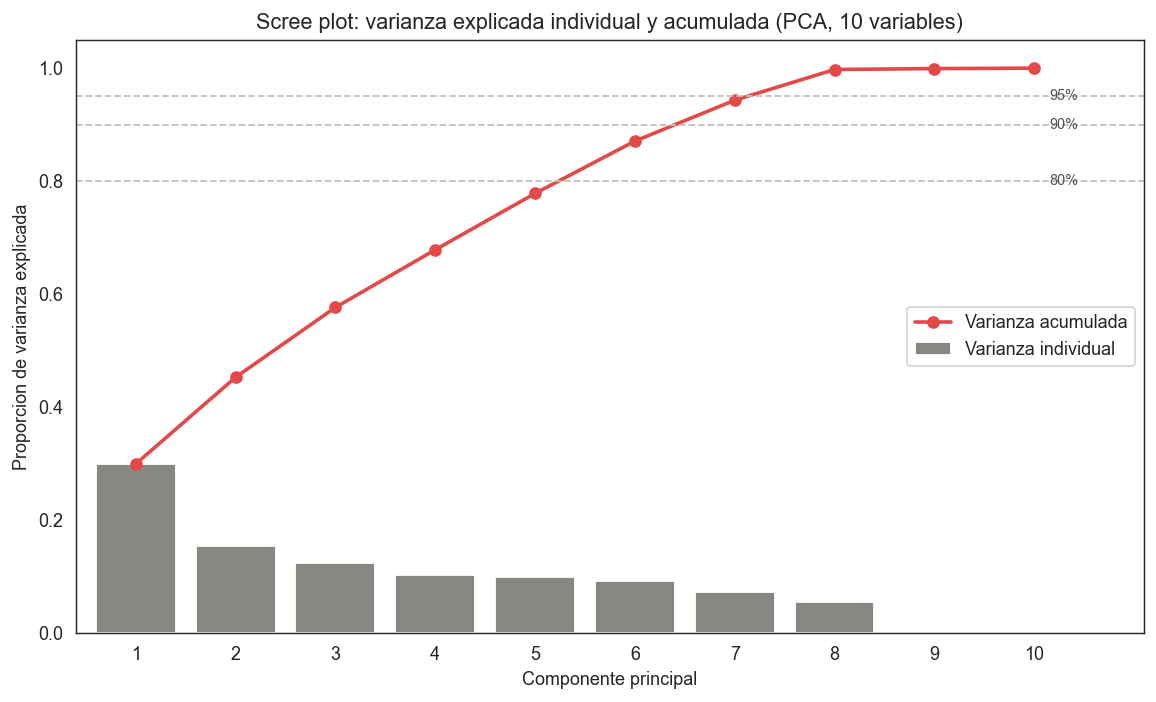

In [57]:
n_comp_80 = int(np.searchsorted(varianza_acumulada, 0.80) + 1)
n_comp_90 = int(np.searchsorted(varianza_acumulada, 0.90) + 1)
n_comp_95 = int(np.searchsorted(varianza_acumulada, 0.95) + 1)

print(f"Componentes necesarias para >= 80% de varianza: {n_comp_80} (acumulado={varianza_acumulada[n_comp_80 - 1]:.6f})")
print(f"Componentes necesarias para >= 90% de varianza: {n_comp_90} (acumulado={varianza_acumulada[n_comp_90 - 1]:.6f})")
print(f"Componentes necesarias para >= 95% de varianza: {n_comp_95} (acumulado={varianza_acumulada[n_comp_95 - 1]:.6f})")

fig, ax = plt.subplots(figsize=(9, 5.5))
x_comp = np.arange(1, len(varianza_individual) + 1)
ax.bar(x_comp, varianza_individual, color=COLOR_MUTED, label="Varianza individual")
ax.plot(x_comp, varianza_acumulada, color=COLOR_TARGET[1], marker="o", linewidth=2, label="Varianza acumulada")

for umbral in (0.80, 0.90, 0.95):
    ax.axhline(umbral, color=COLOR_BASELINE, linestyle="--", linewidth=1)
    ax.text(len(varianza_individual) + 0.15, umbral, f"{umbral:.0%}",
             va="center", fontsize=8, color=COLOR_INK_SECONDARY)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporcion de varianza explicada")
ax.set_xticks(x_comp)
ax.set_xlim(0.4, len(varianza_individual) + 1.1)
ax.set_title("Scree plot: varianza explicada individual y acumulada (PCA, 10 variables)")
ax.legend(loc="center right")
guardar_figura(fig, "06_scree_plot_pca")

**Hallazgo 6.2:** las 10 componentes juntas explican el 100% de la varianza (por
construccion, al no reducir dimensionalidad con `n_components=None`). La varianza individual
esta bastante repartida entre las primeras 8 componentes (PC1=29.9519%, PC2=15.3358%,
PC3=12.3685%, PC4=10.2036%, PC5=9.9716%, PC6=9.2599%, PC7=7.2392%, PC8=5.4314%) y cae de forma
abrupta en las dos ultimas (PC9=0.1705%, PC10=0.0674%), lo que indica que la redundancia
lineal fuerte esta concentrada en muy pocas variables (coherente con el par
`NumberOfTimes90DaysLate` / `NumberOfTime60-89DaysPastDueNotWorse` detectado en la seccion 5
con Pearson=0.992858). Se necesitan 6 componentes para superar el 80% de varianza acumulada
(87.0914%, frente al 77.8315% con solo 5 componentes), 7 componentes para superar el 90%
(94.3306%) y 8 componentes para superar el 95% (99.7620%). En definitiva, PCA lineal apenas
comprime el problema: de las 10 variables originales hacen falta entre 6 y 8 componentes
para no perder informacion relevante, lo que sugiere que la estructura de correlacion lineal
entre variables (seccion 5) es limitada fuera de las 2-3 variables de incidencias de pago.

### 6.3 Proyeccion 2D de las 2 primeras componentes coloreada por TARGET

**Objetivo:** visualizar los datos proyectados sobre PC1 y PC2 (las dos componentes con mayor
varianza individual, calculadas en 6.2) coloreados por `TARGET` con `COLOR_TARGET`, para
valorar si esta proyeccion lineal de 2 dimensiones separa visualmente ambas clases.

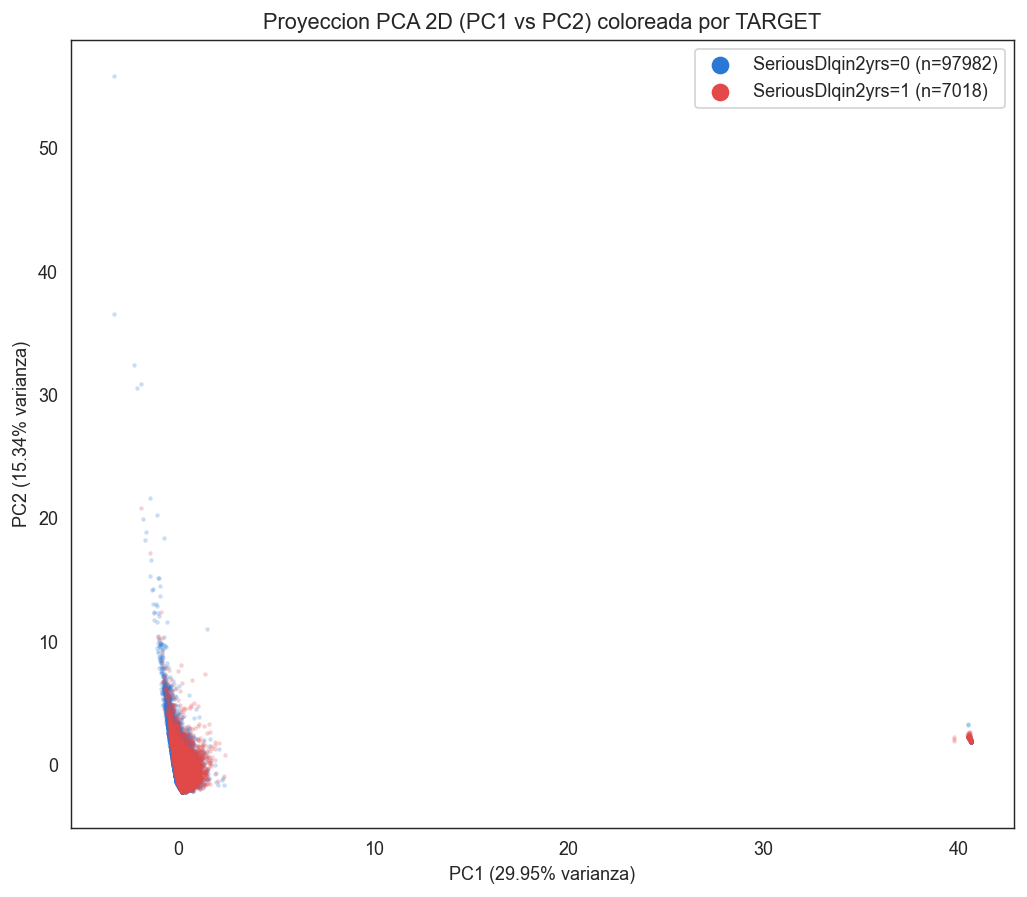

In [58]:
fig, ax = plt.subplots(figsize=(8, 7))
for clase, color in COLOR_TARGET.items():
    mask = df_train[TARGET].values == clase
    ax.scatter(
        X_pca_full[mask, 0], X_pca_full[mask, 1],
        s=6, alpha=0.25, color=color, linewidths=0,
        label=f"{TARGET}={clase} (n={int(mask.sum())})",
    )
ax.set_xlabel(f"PC1 ({varianza_individual[0] * 100:.2f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza_individual[1] * 100:.2f}% varianza)")
ax.set_title("Proyeccion PCA 2D (PC1 vs PC2) coloreada por TARGET")
leg = ax.legend(loc="upper right", markerscale=4)
for lh in leg.legend_handles:
    lh.set_alpha(1)
guardar_figura(fig, "06_proyeccion_pca_2d_target")

In [59]:
mask_0 = df_train[TARGET].values == 0
mask_1 = df_train[TARGET].values == 1

pc1_mean_0, pc1_mean_1 = X_pca_full[mask_0, 0].mean(), X_pca_full[mask_1, 0].mean()
pc2_mean_0, pc2_mean_1 = X_pca_full[mask_0, 1].mean(), X_pca_full[mask_1, 1].mean()

print(f"n TARGET=0: {int(mask_0.sum())} | n TARGET=1: {int(mask_1.sum())}")
print(f"PC1 media TARGET=0: {pc1_mean_0:.6f} | PC1 media TARGET=1: {pc1_mean_1:.6f} | diferencia: {pc1_mean_1 - pc1_mean_0:.6f}")
print(f"PC2 media TARGET=0: {pc2_mean_0:.6f} | PC2 media TARGET=1: {pc2_mean_1:.6f} | diferencia: {pc2_mean_1 - pc2_mean_0:.6f}")

n TARGET=0: 97982 | n TARGET=1: 7018
PC1 media TARGET=0: -0.055034 | PC1 media TARGET=1: 0.768364 | diferencia: 0.823399
PC2 media TARGET=0: 0.003999 | PC2 media TARGET=1: -0.055833 | diferencia: -0.059832


**Hallazgo 6.3:** PC1 y PC2 explican conjuntamente el 45.2877% de la varianza (29.9519% +
15.3358%). En la proyeccion no se observa una separacion clara entre clases: las 97982 filas
con `TARGET=0` y las 7018 con `TARGET=1` se solapan casi por completo en la nube de puntos.
Aun asi hay un desplazamiento medible en PC1: su media es -0.055034 para `TARGET=0` frente a
0.768364 para `TARGET=1` (diferencia de 0.823399), mientras que en PC2 las medias son casi
identicas (0.003999 vs -0.055833, diferencia de -0.059832). Esto es coherente con que PC1 esta
dominada por las variables de incidencias de pago (ver Hallazgo 6.4), que son justamente las
mas relacionadas con el target; aun asi, el solapamiento masivo de la nube de puntos confirma
que una proyeccion lineal de solo 2 componentes no basta para separar las clases, lo que
anticipa limitaciones para un clasificador estrictamente lineal y motiva valorar modelos no
lineales en las siguientes fases.

### 6.4 Loadings: contribucion de las variables originales a las primeras componentes

**Objetivo:** extraer los loadings (`pca_full.components_`) de PC1, PC2 y PC3 para
identificar que variables originales dominan cada componente.

In [60]:
tabla_loadings_pca = pd.DataFrame(
    pca_full.components_[:3].T,
    index=cols_features_pca,
    columns=["PC1", "PC2", "PC3"],
)
guardar_tabla(tabla_loadings_pca, "06_loadings_pca")
tabla_loadings_pca.sort_values("PC1", key=lambda s: s.abs(), ascending=False)

,PC1,PC2,PC3
NumberOfTime60-89DaysPastDueNotWorse,0.574571,0.056159,-0.025866
NumberOfTimes90DaysLate,0.574322,0.049431,-0.022906
NumberOfTime30-59DaysPastDueNotWorse,0.572336,0.067007,-0.018892
NumberOfOpenCreditLinesAndLoans,-0.076510,0.633998,-0.099622
age,-0.058120,0.142242,-0.671092
NumberRealEstateLoansOrLines,-0.052870,0.654921,0.052505
MonthlyIncome,-0.014472,0.253887,0.131559
DebtRatio,-0.012253,0.189611,-0.209461
NumberOfDependents,-0.008232,0.195897,0.687088
RevolvingUtilizationOfUnsecuredLines,-0.000573,-0.004365,0.046173


In [61]:
for componente in ["PC1", "PC2", "PC3"]:
    top3 = tabla_loadings_pca[componente].abs().sort_values(ascending=False).index[:3]
    valores = [f"{var}={tabla_loadings_pca.loc[var, componente]:.6f}" for var in top3]
    print(f"{componente}: top 3 variables por |loading| -> {valores}")

PC1: top 3 variables por |loading| -> ['NumberOfTime60-89DaysPastDueNotWorse=0.574571', 'NumberOfTimes90DaysLate=0.574322', 'NumberOfTime30-59DaysPastDueNotWorse=0.572336']
PC2: top 3 variables por |loading| -> ['NumberRealEstateLoansOrLines=0.654921', 'NumberOfOpenCreditLinesAndLoans=0.633998', 'MonthlyIncome=0.253887']
PC3: top 3 variables por |loading| -> ['NumberOfDependents=0.687088', 'age=-0.671092', 'DebtRatio=-0.209461']


**Hallazgo 6.4:** PC1 (29.9519% de varianza) esta dominada casi por completo por las 3
variables de incidencias de pago, con loadings muy similares y del mismo signo:
`NumberOfTime60-89DaysPastDueNotWorse` (0.574571), `NumberOfTimes90DaysLate` (0.574322) y
`NumberOfTime30-59DaysPastDueNotWorse` (0.572336); el resto de variables tienen loadings por
debajo de 0.08 en valor absoluto en PC1. PC2 (15.3358%) esta dominada por
`NumberRealEstateLoansOrLines` (0.654921) y `NumberOfOpenCreditLinesAndLoans` (0.633998), un
eje de volumen de credito/propiedades contratadas, independiente de los impagos. PC3
(12.3685%) esta dominada por `NumberOfDependents` (0.687088) y `age` (-0.671092), con signos
opuestos: un eje demografico (mas dependientes junto con menor edad) tambien independiente de
los impagos. Este patron confirma lo observado en la seccion 5: las 3 variables
`NumberOfTime*PastDue*` son casi redundantes entre si (colapsan en una unica componente, PC1)
mientras que el resto de variables aporta informacion mas diversa, repartida en componentes
posteriores.

### 6.5 Clustering exploratorio (K-Means) sobre las componentes principales

**Objetivo:** las secciones 6 y 7 proyectan los datos en 2D (PCA, t-SNE, KernelPCA) coloreando
siempre por la variable objetivo `TARGET`, que ya es conocida de antemano. Esa pregunta
("visualmente, ¿el target se separa en la proyeccion?") es distinta de la que se responde en
esta subseccion: ¿existen agrupaciones naturales, no supervisadas (es decir, calculadas sin usar
`TARGET` en ningun momento), en el espacio de las componentes principales calculadas en 6.2? Y si
existen, ¿esas agrupaciones difieren entre si en su tasa de incumplimiento? Un cluster con una
tasa de incumplimiento claramente distinta al resto seria evidencia de un segmento de riesgo
natural en los datos, relevante para la Propuesta D-0.2 (un unico modelo con dos umbrales frente
a dos modelos separados). El clustering se ejecuta con K-Means sobre `X_pca_full`, reutilizando
el trabajo ya hecho en 6.1-6.2 (no se recalcula PCA); las etiquetas resultantes se guardan en una
variable independiente (`labels_kmeans_final`) y en ningun momento se anaden como columna nueva
de `df_train`.

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_kmeans_input = X_pca_full[:, :n_comp_90]
print(f"Shape de X_kmeans_input (primeras {n_comp_90} componentes de PCA, cubren >= 90% de varianza): {X_kmeans_input.shape}")

idx_muestra_silhouette = np.random.RandomState(RANDOM_STATE).choice(len(X_kmeans_input), size=10000, replace=False)

filas_kmeans_seleccion_k = []
for k in range(2, 9):
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X_kmeans_input)
    silhouette_k = silhouette_score(
        X_kmeans_input[idx_muestra_silhouette],
        labels_k[idx_muestra_silhouette],
    )
    filas_kmeans_seleccion_k.append({"k": k, "inercia": kmeans_k.inertia_, "silhouette": silhouette_k})
    print(f"k={k}: inercia={kmeans_k.inertia_:.2f} | silhouette (muestra de 10000 filas)={silhouette_k:.4f}")

tabla_kmeans_seleccion_k = pd.DataFrame(filas_kmeans_seleccion_k)
guardar_tabla(tabla_kmeans_seleccion_k, "06_kmeans_seleccion_k")
tabla_kmeans_seleccion_k

Shape de X_kmeans_input (primeras 7 componentes de PCA, cubren >= 90% de varianza): (105000, 7)


k=2: inercia=679423.67 | silhouette (muestra de 10000 filas)=0.9364


k=3: inercia=583549.17 | silhouette (muestra de 10000 filas)=0.2549


k=4: inercia=513005.04 | silhouette (muestra de 10000 filas)=0.2426


k=5: inercia=441656.65 | silhouette (muestra de 10000 filas)=0.2532


k=6: inercia=378373.72 | silhouette (muestra de 10000 filas)=0.2766


k=7: inercia=323027.17 | silhouette (muestra de 10000 filas)=0.2895


k=8: inercia=268495.62 | silhouette (muestra de 10000 filas)=0.2945


,k,inercia,silhouette
0,2,679423.669840,0.936398
1,3,583549.174330,0.254894
2,4,513005.042540,0.242586
3,5,441656.650737,0.253241
4,6,378373.722713,0.276618
5,7,323027.171538,0.289484
6,8,268495.615262,0.294512


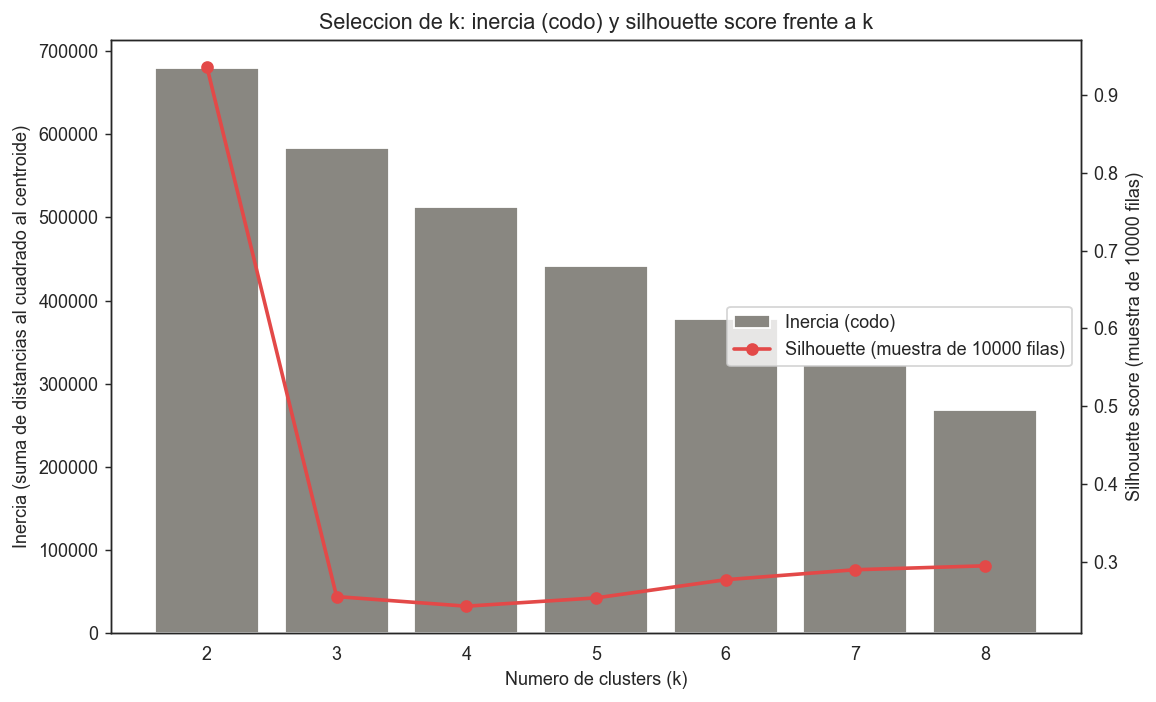

In [63]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(tabla_kmeans_seleccion_k["k"], tabla_kmeans_seleccion_k["inercia"], color=COLOR_MUTED, label="Inercia (codo)")
ax.set_xlabel("Numero de clusters (k)")
ax.set_ylabel("Inercia (suma de distancias al cuadrado al centroide)")
ax.set_xticks(tabla_kmeans_seleccion_k["k"])
ax.set_title("Seleccion de k: inercia (codo) y silhouette score frente a k")

ax2 = ax.twinx()
ax2.plot(
    tabla_kmeans_seleccion_k["k"], tabla_kmeans_seleccion_k["silhouette"],
    color=COLOR_TARGET[1], marker="o", linewidth=2, label="Silhouette (muestra de 10000 filas)",
)
ax2.set_ylabel("Silhouette score (muestra de 10000 filas)")
ax2.grid(False)

lineas_ax, etiquetas_ax = ax.get_legend_handles_labels()
lineas_ax2, etiquetas_ax2 = ax2.get_legend_handles_labels()
ax.legend(lineas_ax + lineas_ax2, etiquetas_ax + etiquetas_ax2, loc="center right")

guardar_figura(fig, "06_kmeans_elbow_silhouette")

In [64]:
k_optimo = int(tabla_kmeans_seleccion_k.loc[tabla_kmeans_seleccion_k["silhouette"].idxmax(), "k"])
silhouette_k_optimo = float(tabla_kmeans_seleccion_k.loc[tabla_kmeans_seleccion_k["silhouette"].idxmax(), "silhouette"])
print(f"k optimo elegido por silhouette maximo: k={k_optimo} (silhouette={silhouette_k_optimo:.4f})")

kmeans_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_final = kmeans_final.fit_predict(X_kmeans_input)

print(f"labels_kmeans_final: shape={labels_kmeans_final.shape}, valores unicos={sorted(np.unique(labels_kmeans_final).tolist())}")
print(pd.Series(labels_kmeans_final, name="cluster_kmeans").value_counts().sort_index())

k optimo elegido por silhouette maximo: k=2 (silhouette=0.9364)


labels_kmeans_final: shape=(105000,), valores unicos=[0, 1]
cluster_kmeans
0    104812
1       188
Name: count, dtype: int64


In [65]:
cols_perfil_clusters = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
]

grupo_clusters = df_train.groupby(labels_kmeans_final)

tabla_perfil_clusters = pd.DataFrame({
    "n_filas": grupo_clusters.size(),
    "pct_filas": grupo_clusters.size() / len(df_train) * 100,
    "tasa_positivos_pct": grupo_clusters[TARGET].mean() * 100,
})
for col in cols_perfil_clusters:
    tabla_perfil_clusters[f"media_{col}"] = grupo_clusters[col].mean()

tabla_perfil_clusters.index.name = "cluster_kmeans"
tabla_perfil_clusters = tabla_perfil_clusters.sort_values("tasa_positivos_pct", ascending=False)
guardar_tabla(tabla_perfil_clusters, "06_kmeans_perfil_clusters")
tabla_perfil_clusters

,n_filas,pct_filas,tasa_positivos_pct,media_RevolvingUtilizationOfUnsecuredLines,media_age,media_DebtRatio,media_MonthlyIncome
cluster_kmeans,,,,,,,
1,188,0.179048,54.255319,1.000000,34.164894,5.562159,2538.718447
0,104812,99.820952,6.598481,6.156204,52.253998,354.785764,6705.536087


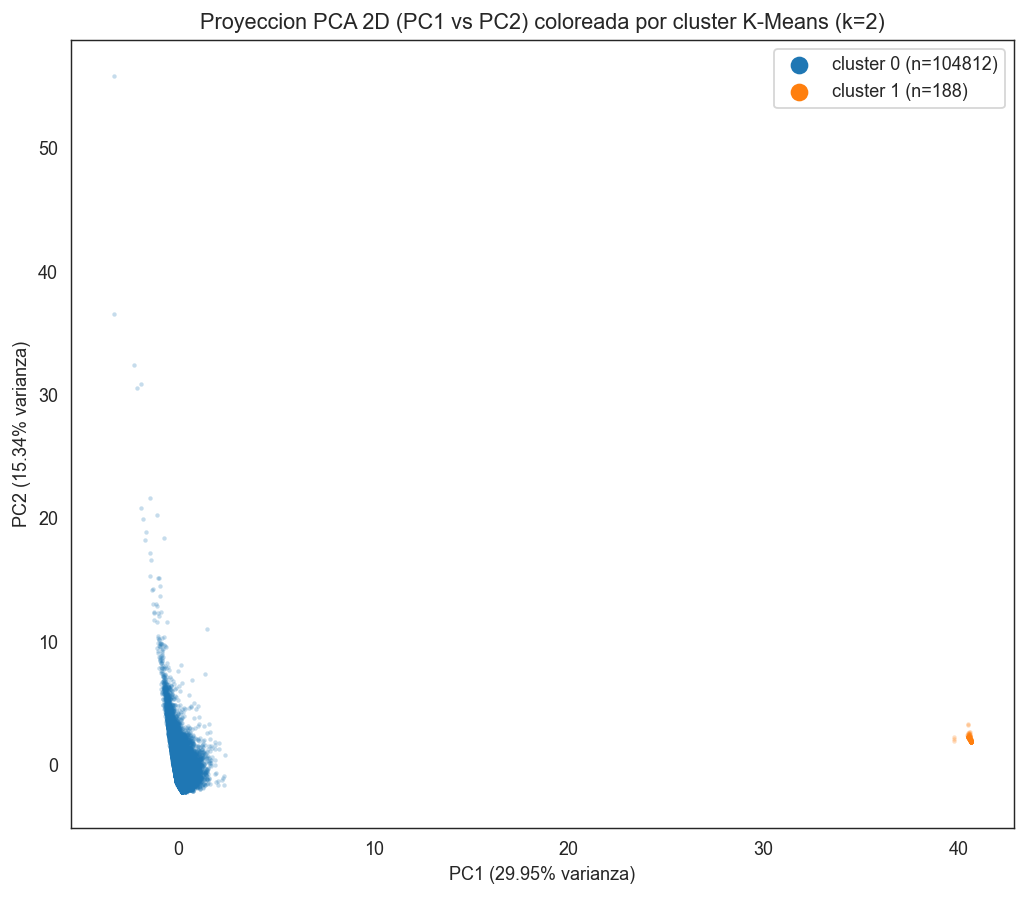

In [66]:
fig, ax = plt.subplots(figsize=(8, 7))
cmap_clusters = plt.get_cmap("tab10")
for cluster_id in sorted(np.unique(labels_kmeans_final)):
    mask = labels_kmeans_final == cluster_id
    ax.scatter(
        X_pca_full[mask, 0], X_pca_full[mask, 1],
        s=6, alpha=0.25, color=cmap_clusters(cluster_id % 10), linewidths=0,
        label=f"cluster {cluster_id} (n={int(mask.sum())})",
    )
ax.set_xlabel(f"PC1 ({varianza_individual[0] * 100:.2f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza_individual[1] * 100:.2f}% varianza)")
ax.set_title(f"Proyeccion PCA 2D (PC1 vs PC2) coloreada por cluster K-Means (k={k_optimo})")
leg = ax.legend(loc="upper right", markerscale=4)
for lh in leg.legend_handles:
    lh.set_alpha(1)
guardar_figura(fig, "06_kmeans_proyeccion_pca_clusters")

**Hallazgo 6.5:** con `k` recorriendo 2 a 8 sobre `X_kmeans_input` (las 7 primeras
componentes de PCA, que cubren el 94.3306% de varianza segun `n_comp_90` de 6.2), el
silhouette (calculado sobre una muestra de 10000 filas) es maximo en `k=2` (0.9364), muy por
encima de `k=3` (0.2549) y del resto de valores de `k` hasta 8 (entre 0.2426 y 0.2945, subiendo
de forma suave y sin codo claro conforme crece `k`). Siguiendo la regla de seleccion por
silhouette maximo, `k_optimo=2`. Sin embargo, un silhouette de 0.9364 es sospechosamente alto
para datos tabulares reales (los valores de 0.24-0.29 obtenidos para `k=3..8` son mas
representativos de lo habitual, que suele ser bajo/moderado cuando no hay clusters bien
separados) y, al inspeccionar los 2 clusters de `k_optimo=2`, se confirma que el silhouette
alto es un artefacto de tamano: el cluster 1 tiene solo 188 filas (0.1790% del total) frente a
104812 (99.8210%) del cluster 0, y esas 188 filas comparten un valor identico de
`RevolvingUtilizationOfUnsecuredLines` (0.9999999, con desviacion estandar practicamente nula),
un valor que aparece repetido 7162 veces en todo `df_train` pero que en el cluster 1 aparece
combinado con un perfil demografico propio: edad media 34.1649 anios frente a 52.2540 en el
cluster 0, e ingreso medio `MonthlyIncome` de 2538.7184 frente a 6705.5361. Pese a ser un
cluster minusculo y en parte definido por un artefacto de codificacion, su tasa de positivos es
muy distinta a la del resto: 54.2553% frente a 6.5985% en el cluster 0 (la tasa global de
`SeriousDlqin2yrs` es 6.6838%), es decir, el cluster 1 tiene una tasa de incumplimiento
aproximadamente 8.1 veces superior a la del resto de la cartera. La `DebtRatio` media del
cluster 0 (354.7858) es mucho mas alta que la del cluster 1 (5.5622), pero esto se debe a que
los pocos valores extremos de `DebtRatio` identificados en las Secciones 3.3/3.4 (hasta 329664)
caen dentro del cluster 0 por su tamano dominante, no a que el cluster 1 tenga deuda baja en
terminos relativos. En conjunto, la evidencia no supervisada apunta a un segmento de riesgo
real, aunque muy pequeno: personas jovenes, de ingresos bajos, con la linea de credito
renovable practicamente al limite (`RevolvingUtilizationOfUnsecuredLines` ~= 1), que incumplen
con una frecuencia mucho mayor que el resto de la cartera. Recomendacion para
`02_preprocesado.ipynb`: (1) anadir `cluster_kmeans` (o, mas especificamente, un flag binario
`revolving_casi_al_limite` para `RevolvingUtilizationOfUnsecuredLines` cercano a 1) como
variable categorica candidata para el modelado; (2) usar este hallazgo como evidencia adicional
-aunque de alcance limitado, al afectar solo al 0.1790% de las filas- para la Propuesta D-0.2,
ya que sugiere que existen subgrupos con un riesgo base muy distinto, pero su tamano tan
reducido no justifica por si solo migrar a una arquitectura de dos modelos; es mas apropiado
tratarlo como una regla/feature adicional dentro de un unico modelo que como base para una
segmentacion completa de la cartera.

## 7. Reduccion de dimensionalidad no lineal

La seccion 6 aplico PCA, una tecnica de reduccion de dimensionalidad **lineal**: la separacion
entre clases que revela esta limitada a lo que una combinacion lineal de las variables originales
puede capturar. Esta seccion explora si una tecnica **no lineal** (t-SNE) revela una estructura
de separacion entre clases distinta -mas clara, igual o peor- sobre las mismas variables
escaladas `X_scaled_pca` de la seccion 6 (imputadas con la mediana, ver Hallazgo 6.1). Por el
coste computacional de t-SNE (que crece de forma no lineal con el numero de filas), el analisis
se realiza sobre una muestra aleatoria de como maximo 8000 filas de `df_train`
(`random_state=RANDOM_STATE`) en vez de sobre las 105000 filas completas. Opcionalmente se anade
tambien KernelPCA (kernel `rbf`) como alternativa no lineal mas ligera de calcular.

### 7.1 Muestra aleatoria y ajuste de t-SNE

**Objetivo:** tomar una muestra aleatoria de como maximo 8000 filas de `df_train`
(`random_state=RANDOM_STATE`) y ajustar `sklearn.manifold.TSNE` sobre las variables escaladas
`X_scaled_pca` (seccion 6) de esa muestra, proyectando a 2 dimensiones.

In [67]:
from sklearn.manifold import TSNE
import time

n_muestra_tsne = min(8000, len(df_train))
rng_tsne = np.random.RandomState(RANDOM_STATE)
idx_muestra_tsne = rng_tsne.choice(len(df_train), size=n_muestra_tsne, replace=False)
idx_muestra_tsne.sort()

X_scaled_muestra_tsne = X_scaled_pca[idx_muestra_tsne]
target_muestra_tsne = df_train[TARGET].values[idx_muestra_tsne]

print(f"Tamano de la muestra para t-SNE: {n_muestra_tsne} de {len(df_train)} filas de df_train "
      f"({n_muestra_tsne / len(df_train) * 100:.4f}%)")
print(f"Balance de clases en la muestra: TARGET=0 -> {int((target_muestra_tsne == 0).sum())}, "
      f"TARGET=1 -> {int((target_muestra_tsne == 1).sum())} "
      f"({(target_muestra_tsne == 1).mean() * 100:.4f}% positivos)")

Tamano de la muestra para t-SNE: 8000 de 105000 filas de df_train (7.6190%)
Balance de clases en la muestra: TARGET=0 -> 7477, TARGET=1 -> 523 (6.5375% positivos)


In [68]:
t0_tsne = time.time()
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto", perplexity=30)
X_tsne = tsne.fit_transform(X_scaled_muestra_tsne)
tiempo_tsne = time.time() - t0_tsne

print(f"Shape de X_tsne: {X_tsne.shape}")
print(f"Tiempo de ajuste de t-SNE: {tiempo_tsne:.1f} segundos")
print(f"Divergencia KL final: {tsne.kl_divergence_:.6f}")
print(f"Iteraciones ejecutadas: {tsne.n_iter_}")

Shape de X_tsne: (8000, 2)
Tiempo de ajuste de t-SNE: 94.1 segundos
Divergencia KL final: 0.914883
Iteraciones ejecutadas: 999


**Hallazgo 7.1:** la muestra para t-SNE contiene 8000 filas de las 105000 de `df_train`
(7.6190%), con `TARGET=0` en 7477 filas y `TARGET=1` en 523 filas (6.5375% de positivos en la
muestra, en linea con el 6.6838% de positivos del `df_train` completo, ver Hallazgo 2.2). El
ajuste de t-SNE produce una proyeccion `X_tsne` de shape (8000, 2), tarda 94.1 segundos en esta
ejecucion (el tiempo exacto puede variar segun la maquina) y converge con una divergencia KL
final de 0.914883 tras 999 iteraciones ejecutadas.

### 7.2 Proyeccion 2D de t-SNE coloreada por TARGET y comparacion con PCA

**Objetivo:** visualizar la proyeccion t-SNE 2D coloreada por `TARGET` con `COLOR_TARGET`, y
comparar cuantitativamente con la proyeccion PCA (PC1-PC2, seccion 6) sobre la misma muestra
mediante la pureza de vecinos (fraccion de los k=15 vecinos mas cercanos que comparten la misma
clase que el punto), una metrica local menos sensible al fuerte desbalance de clases que un
`silhouette_score` global.

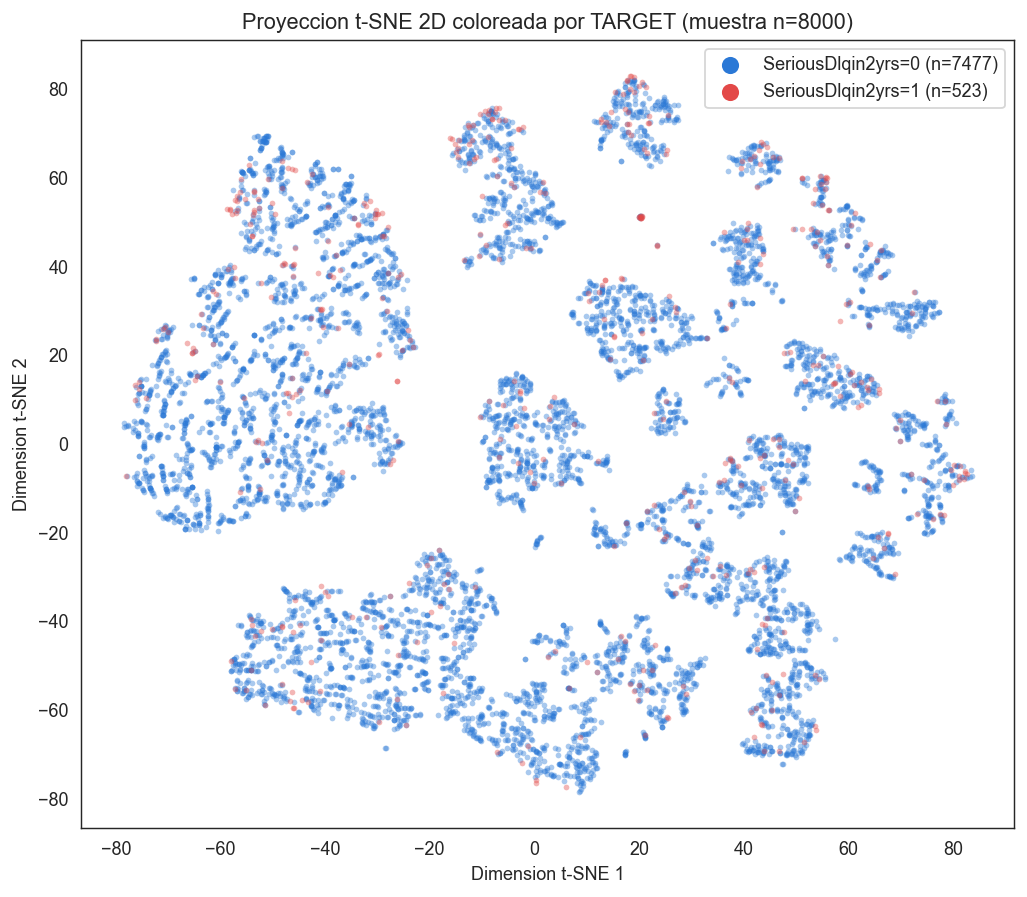

In [69]:
fig, ax = plt.subplots(figsize=(8, 7))
for clase, color in COLOR_TARGET.items():
    mask = target_muestra_tsne == clase
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        s=10, alpha=0.4, color=color, linewidths=0,
        label=f"{TARGET}={clase} (n={int(mask.sum())})",
    )
ax.set_xlabel("Dimension t-SNE 1")
ax.set_ylabel("Dimension t-SNE 2")
ax.set_title(f"Proyeccion t-SNE 2D coloreada por TARGET (muestra n={n_muestra_tsne})")
leg = ax.legend(loc="upper right", markerscale=3)
for lh in leg.legend_handles:
    lh.set_alpha(1)
guardar_figura(fig, "07_proyeccion_tsne_2d_target")

In [70]:
from sklearn.neighbors import NearestNeighbors

def pureza_vecinos(X, y, k=15):
    vecinos = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = vecinos.kneighbors(X)
    indices_vecinos = indices[:, 1:]  # excluir el propio punto
    etiquetas_vecinos = y[indices_vecinos]
    return (etiquetas_vecinos == y[:, None]).mean(axis=1)

X_pca_muestra = X_pca_full[idx_muestra_tsne, :2]

pureza_pca = pureza_vecinos(X_pca_muestra, target_muestra_tsne, k=15)
pureza_tsne = pureza_vecinos(X_tsne, target_muestra_tsne, k=15)

tabla_pureza_pca_tsne = pd.DataFrame({
    "metodo": ["PCA (PC1-PC2)", "t-SNE (2D)"],
    "pureza_global": [pureza_pca.mean(), pureza_tsne.mean()],
    "pureza_clase_0": [pureza_pca[target_muestra_tsne == 0].mean(), pureza_tsne[target_muestra_tsne == 0].mean()],
    "pureza_clase_1": [pureza_pca[target_muestra_tsne == 1].mean(), pureza_tsne[target_muestra_tsne == 1].mean()],
})
guardar_tabla(tabla_pureza_pca_tsne, "07_pureza_vecinos_pca_vs_tsne")
tabla_pureza_pca_tsne

,metodo,pureza_global,pureza_clase_0,pureza_clase_1
0,PCA (PC1-PC2),0.901358,0.948723,0.224219
1,t-SNE (2D),0.892300,0.946333,0.119822


**Hallazgo 7.2:** visualmente, la proyeccion t-SNE tampoco separa las clases con claridad: los
puntos rojos (`TARGET=1`, n=523) aparecen dispersos entre los azules (`TARGET=0`, n=7477) en casi
toda la nube, sin formar una region propia bien delimitada, de forma similar a lo observado en
PCA (Hallazgo 6.3). La comparacion cuantitativa con la pureza de vecinos (k=15) confirma que
t-SNE no mejora la separacion local: la pureza global es de 0.901358 en PCA frente a 0.892300 en
t-SNE, y en la clase minoritaria (`TARGET=1`, la que de verdad importa separar) la pureza cae de
0.224219 en PCA a 0.119822 en t-SNE, es decir, en t-SNE los vecinos mas cercanos de un cliente
que incumple son todavia menos frecuentemente otros clientes que incumplen que en PCA. Por
tanto, en este caso la estructura no lineal capturada por t-SNE revela una separacion entre
clases **igual o ligeramente peor** que la proyeccion lineal de PCA, no mejor: el solapamiento
entre clases parece ser una propiedad intrinseca de las variables explicativas en este dataset y
no un artefacto de que PCA solo capture relaciones lineales.

### 7.3 (Opcional) KernelPCA (rbf) como alternativa no lineal mas ligera

**Objetivo:** ajustar `KernelPCA` con `kernel="rbf"` sobre la misma muestra usada en t-SNE, como
alternativa no lineal mas barata de calcular, y comparar brevemente su tiempo de ajuste y su
pureza de vecinos frente a PCA lineal y t-SNE.

In [71]:
from sklearn.decomposition import KernelPCA

t0_kpca = time.time()
kpca_rbf = KernelPCA(n_components=2, kernel="rbf", random_state=RANDOM_STATE)
X_kpca = kpca_rbf.fit_transform(X_scaled_muestra_tsne)
tiempo_kpca = time.time() - t0_kpca

print(f"Shape de X_kpca: {X_kpca.shape}")
print(f"Tiempo de ajuste de KernelPCA (rbf): {tiempo_kpca:.2f} segundos")
print(f"Tiempo de ajuste de t-SNE: {tiempo_tsne:.2f} segundos")
print(f"t-SNE tardo {tiempo_tsne / tiempo_kpca:.1f}x mas que KernelPCA (rbf) sobre la misma muestra")

Shape de X_kpca: (8000, 2)
Tiempo de ajuste de KernelPCA (rbf): 3.76 segundos
Tiempo de ajuste de t-SNE: 94.09 segundos
t-SNE tardo 25.0x mas que KernelPCA (rbf) sobre la misma muestra


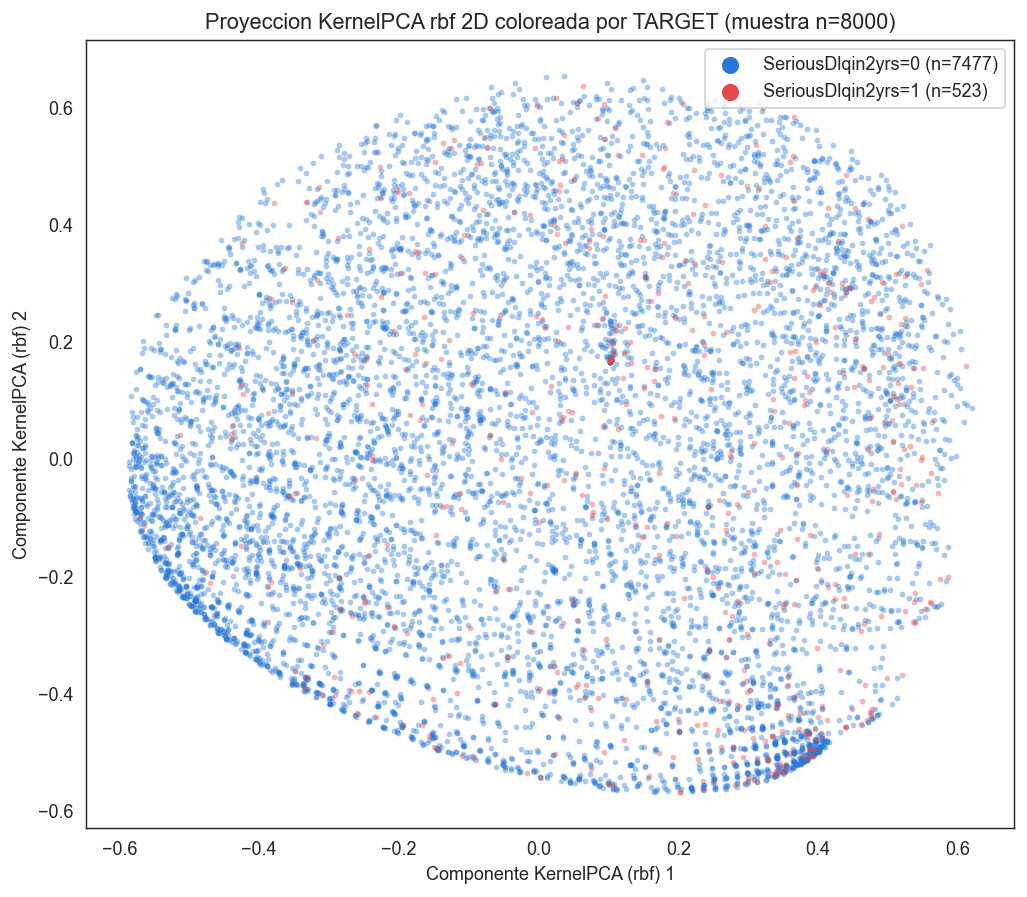

,metodo,pureza_global,pureza_clase_0,pureza_clase_1
0,PCA (PC1-PC2),0.901358,0.948723,0.224219
1,t-SNE (2D),0.892300,0.946333,0.119822
2,KernelPCA (rbf),0.882033,0.936516,0.103123


In [72]:
fig, ax = plt.subplots(figsize=(8, 7))
for clase, color in COLOR_TARGET.items():
    mask = target_muestra_tsne == clase
    ax.scatter(
        X_kpca[mask, 0], X_kpca[mask, 1],
        s=10, alpha=0.4, color=color, linewidths=0,
        label=f"{TARGET}={clase} (n={int(mask.sum())})",
    )
ax.set_xlabel("Componente KernelPCA (rbf) 1")
ax.set_ylabel("Componente KernelPCA (rbf) 2")
ax.set_title(f"Proyeccion KernelPCA rbf 2D coloreada por TARGET (muestra n={n_muestra_tsne})")
leg = ax.legend(loc="upper right", markerscale=3)
for lh in leg.legend_handles:
    lh.set_alpha(1)
guardar_figura(fig, "07_proyeccion_kernelpca_rbf_2d_target")

pureza_kpca = pureza_vecinos(X_kpca, target_muestra_tsne, k=15)

tabla_pureza_3_metodos = pd.concat([
    tabla_pureza_pca_tsne,
    pd.DataFrame({
        "metodo": ["KernelPCA (rbf)"],
        "pureza_global": [pureza_kpca.mean()],
        "pureza_clase_0": [pureza_kpca[target_muestra_tsne == 0].mean()],
        "pureza_clase_1": [pureza_kpca[target_muestra_tsne == 1].mean()],
    }),
], ignore_index=True)
guardar_tabla(tabla_pureza_3_metodos, "07_pureza_vecinos_3_metodos")
tabla_pureza_3_metodos

**Hallazgo 7.3:** KernelPCA (rbf) es mucho mas rapido que t-SNE sobre la misma muestra de 8000
filas (3.76 segundos frente a los 94.09 segundos de t-SNE, unas 25.0 veces mas rapido). Sin
embargo, tampoco mejora la separacion entre clases: su pureza de vecinos global es de 0.882033,
similar a la de PCA (0.901358) y t-SNE (0.892300), y su pureza en la clase `TARGET=1`
(0.103123) es la mas baja de los tres metodos, por debajo de PCA (0.224219) y de t-SNE
(0.119822). En conjunto, las tres tecnicas de reduccion de dimensionalidad de esta seccion 7
(t-SNE, KernelPCA rbf) y de la seccion 6 (PCA) coinciden en que las clases de
`SeriousDlqin2yrs` se solapan de forma sustancial en el espacio de las 10 variables
explicativas: ni una proyeccion lineal ni dos proyecciones no lineales distintas logran separar
visualmente ni localmente (via pureza de vecinos) a los clientes que incumplen de los que no.
Esto refuerza la conclusion de la seccion 6: un clasificador necesitara apoyarse en variables
individuales con senal fuerte (como `NumberOfTime*PastDue*` o
`RevolvingUtilizationOfUnsecuredLines`, ver Hallazgo 5.3) y/o fronteras de decision complejas,
mas que en una reduccion de dimensionalidad previa a 2D para separar las clases.

### 7.4 Verificacion de robustez: PCA, t-SNE y KernelPCA excluyendo centinelas y outliers extremos

**Objetivo:** repetir el PCA completo (seccion 6) y el t-SNE/KernelPCA (rbf) de las secciones
7.1-7.3 excluyendo las filas identificadas como problematicas en la seccion 3 -los valores
centinela 96/98 en las 3 columnas `NumberOfTime*PastDue*` (Hallazgo 3.1) y las filas con
`RevolvingUtilizationOfUnsecuredLines` > 2 o `DebtRatio` por encima de su percentil 97.5
(Hallazgo 3.3)- para comprobar si PC1 sigue interpretandose como un eje de impagos (Hallazgo
6.2/6.4) y si la falta de separacion de clases (Hallazgo 6.3, 7.2, 7.3) se mantiene una vez
tratadas esas filas. Esta verificacion responde directamente a la duda que deja abierta el
Hallazgo 5.4: el Pearson ~0.98-0.99 entre las columnas `PastDue` cae a 0.25-0.32 en Spearman,
lo que sugiere que esa correlacion (y por tanto la interpretacion de PC1 que se apoya en ella)
podria estar inflada por esas filas centinela.

In [73]:
mask_rev_alto = rev > 2
mask_filas_problema = mask_sentinel_pastdue | mask_debt_alto | mask_rev_alto
n_filas_problema = int(mask_filas_problema.sum())

print(f"Filas centinela PastDue 96/98 (Hallazgo 3.1): {int(mask_sentinel_pastdue.sum())}")
print(f"Filas RevolvingUtilizationOfUnsecuredLines > 2 (Hallazgo 3.3): {int(mask_rev_alto.sum())}")
print(f"Filas DebtRatio > p97.5 = {umbral_debt_alto:.4f} (Hallazgo 3.3): {int(mask_debt_alto.sum())}")
print(f"Union de filas problematicas (se excluyen de este analisis de robustez): "
      f"{n_filas_problema} de {len(df_train)} ({n_filas_problema / len(df_train) * 100:.4f}%)")

df_pca_input_robusto = df_train.loc[~mask_filas_problema, cols_features_pca].copy()
target_robusto = df_train.loc[~mask_filas_problema, TARGET].values

medianas_pca_robusto = df_pca_input_robusto.median()
df_pca_imputado_robusto = df_pca_input_robusto.fillna(medianas_pca_robusto)

scaler_pca_robusto = StandardScaler()
X_scaled_pca_robusto = scaler_pca_robusto.fit_transform(df_pca_imputado_robusto)

print(f"\nShape de X_scaled_pca_robusto (tras excluir filas problematicas): {X_scaled_pca_robusto.shape}")

Filas centinela PastDue 96/98 (Hallazgo 3.1): 188
Filas RevolvingUtilizationOfUnsecuredLines > 2 (Hallazgo 3.3): 261
Filas DebtRatio > p97.5 = 3510.0250 (Hallazgo 3.3): 2625
Union de filas problematicas (se excluyen de este analisis de robustez): 3061 de 105000 (2.9152%)

Shape de X_scaled_pca_robusto (tras excluir filas problematicas): (101939, 10)


In [74]:
pca_full_robusto = PCA(random_state=RANDOM_STATE)
X_pca_full_robusto = pca_full_robusto.fit_transform(X_scaled_pca_robusto)
varianza_individual_robusto = pca_full_robusto.explained_variance_ratio_

tabla_loadings_pca_robusto = pd.DataFrame(
    pca_full_robusto.components_[:3].T,
    index=cols_features_pca,
    columns=["PC1", "PC2", "PC3"],
)
guardar_tabla(tabla_loadings_pca_robusto, "07_loadings_pca_robusto")

print(f"PC1 varianza explicada: original={varianza_individual[0] * 100:.4f}% | "
      f"robusto (sin centinelas/outliers)={varianza_individual_robusto[0] * 100:.4f}%")
print(f"PC2 varianza explicada: original={varianza_individual[1] * 100:.4f}% | "
      f"robusto={varianza_individual_robusto[1] * 100:.4f}%")
print()
for componente in ["PC1", "PC2", "PC3"]:
    top3_orig = tabla_loadings_pca[componente].abs().sort_values(ascending=False).index[:3].tolist()
    top3_rob = tabla_loadings_pca_robusto[componente].abs().sort_values(ascending=False).index[:3].tolist()
    print(f"{componente} top3 original: {top3_orig}")
    print(f"{componente} top3 robusto : {top3_rob}")

PC1 varianza explicada: original=29.9519% | robusto (sin centinelas/outliers)=19.2023%
PC2 varianza explicada: original=15.3358% | robusto=15.4506%

PC1 top3 original: ['NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']
PC1 top3 robusto : ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
PC2 top3 original: ['NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome']
PC2 top3 robusto : ['NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']
PC3 top3 original: ['NumberOfDependents', 'age', 'DebtRatio']
PC3 top3 robusto : ['NumberOfDependents', 'age', 'DebtRatio']


In [75]:
mask_0_robusto = target_robusto == 0
mask_1_robusto = target_robusto == 1

pc1_mean_0_robusto = X_pca_full_robusto[mask_0_robusto, 0].mean()
pc1_mean_1_robusto = X_pca_full_robusto[mask_1_robusto, 0].mean()
diff_pc1_robusto = pc1_mean_1_robusto - pc1_mean_0_robusto
diff_pc1_original = pc1_mean_1 - pc1_mean_0

print(f"n TARGET=0 (robusto): {int(mask_0_robusto.sum())} | n TARGET=1 (robusto): {int(mask_1_robusto.sum())}")
print(f"PC1 media TARGET=0: {pc1_mean_0_robusto:.6f} | PC1 media TARGET=1: {pc1_mean_1_robusto:.6f} | "
      f"diferencia: {diff_pc1_robusto:.6f}")
print(f"Diferencia PC1 original (con centinelas/outliers, Hallazgo 6.3): {diff_pc1_original:.6f}")
print(f"Razon diferencia robusto / original: {diff_pc1_robusto / diff_pc1_original:.4f}")

n TARGET=0 (robusto): 95226 | n TARGET=1 (robusto): 6713
PC1 media TARGET=0: -0.147931 | PC1 media TARGET=1: 2.098446 | diferencia: 2.246377
Diferencia PC1 original (con centinelas/outliers, Hallazgo 6.3): 0.823399
Razon diferencia robusto / original: 2.7282


In [76]:
n_muestra_robusto = min(8000, len(df_pca_imputado_robusto))
rng_robusto = np.random.RandomState(RANDOM_STATE)
idx_muestra_robusto = rng_robusto.choice(len(df_pca_imputado_robusto), size=n_muestra_robusto, replace=False)
idx_muestra_robusto.sort()

X_scaled_muestra_robusto = X_scaled_pca_robusto[idx_muestra_robusto]
target_muestra_robusto = target_robusto[idx_muestra_robusto]

print(f"Muestra robusta para t-SNE/KernelPCA: {n_muestra_robusto} de {len(df_pca_imputado_robusto)} filas "
      f"({(target_muestra_robusto == 1).mean() * 100:.4f}% positivos)")

t0_tsne_robusto = time.time()
tsne_robusto = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto", perplexity=30)
X_tsne_robusto = tsne_robusto.fit_transform(X_scaled_muestra_robusto)
tiempo_tsne_robusto = time.time() - t0_tsne_robusto
print(f"t-SNE robusto: shape {X_tsne_robusto.shape}, tiempo {tiempo_tsne_robusto:.1f} segundos, "
      f"KL final {tsne_robusto.kl_divergence_:.6f}, iteraciones {tsne_robusto.n_iter_}")

t0_kpca_robusto = time.time()
kpca_rbf_robusto = KernelPCA(n_components=2, kernel="rbf", random_state=RANDOM_STATE)
X_kpca_robusto = kpca_rbf_robusto.fit_transform(X_scaled_muestra_robusto)
tiempo_kpca_robusto = time.time() - t0_kpca_robusto
print(f"KernelPCA robusto: shape {X_kpca_robusto.shape}, tiempo {tiempo_kpca_robusto:.2f} segundos")

Muestra robusta para t-SNE/KernelPCA: 8000 de 101939 filas (6.2375% positivos)


t-SNE robusto: shape (8000, 2), tiempo 82.6 segundos, KL final 1.106624, iteraciones 999


KernelPCA robusto: shape (8000, 2), tiempo 3.65 segundos


In [77]:
X_pca_muestra_robusto = X_pca_full_robusto[idx_muestra_robusto, :2]

pureza_pca_robusto = pureza_vecinos(X_pca_muestra_robusto, target_muestra_robusto, k=15)
pureza_tsne_robusto = pureza_vecinos(X_tsne_robusto, target_muestra_robusto, k=15)
pureza_kpca_robusto = pureza_vecinos(X_kpca_robusto, target_muestra_robusto, k=15)

tabla_pureza_robusto = pd.DataFrame({
    "metodo": ["PCA (PC1-PC2)", "t-SNE (2D)", "KernelPCA (rbf)"],
    "pureza_global": [pureza_pca_robusto.mean(), pureza_tsne_robusto.mean(), pureza_kpca_robusto.mean()],
    "pureza_clase_0": [
        pureza_pca_robusto[target_muestra_robusto == 0].mean(),
        pureza_tsne_robusto[target_muestra_robusto == 0].mean(),
        pureza_kpca_robusto[target_muestra_robusto == 0].mean(),
    ],
    "pureza_clase_1": [
        pureza_pca_robusto[target_muestra_robusto == 1].mean(),
        pureza_tsne_robusto[target_muestra_robusto == 1].mean(),
        pureza_kpca_robusto[target_muestra_robusto == 1].mean(),
    ],
})
guardar_tabla(tabla_pureza_robusto, "07_pureza_vecinos_3_metodos_robusto")

tabla_comparacion_pureza = tabla_pureza_3_metodos.copy()
tabla_comparacion_pureza["pureza_global_robusto"] = tabla_pureza_robusto["pureza_global"].values
tabla_comparacion_pureza["pureza_clase_1_robusto"] = tabla_pureza_robusto["pureza_clase_1"].values
guardar_tabla(tabla_comparacion_pureza, "07_comparacion_pureza_original_vs_robusto")
tabla_comparacion_pureza

,metodo,pureza_global,pureza_clase_0,pureza_clase_1,pureza_global_robusto,pureza_clase_1_robusto
0,PCA (PC1-PC2),0.901358,0.948723,0.224219,0.908675,0.262124
1,t-SNE (2D),0.892300,0.946333,0.119822,0.911183,0.271877
2,KernelPCA (rbf),0.882033,0.936516,0.103123,0.900450,0.213494


**Hallazgo 7.4:** al excluir las filas problematicas de las secciones 3.1/3.3 (188 filas
centinela 96/98 en las columnas `NumberOfTime*PastDue*`, 261 filas con
`RevolvingUtilizationOfUnsecuredLines` > 2 y 2625 filas con `DebtRatio` > p97.5; 3061 filas en
total tras la union, 2.9152% del dataset) y repetir el PCA sobre las 101939 filas restantes, la
composicion de PC1 cambia de forma sustancial: su varianza explicada baja de 29.9519%
(Hallazgo 6.2) a 19.2023%, y dejan de ser las 3 variables `NumberOfTime*PastDue*` las unicas que
lo dominan (Hallazgo 6.4) -en el PCA robusto, `RevolvingUtilizationOfUnsecuredLines` entra en el
top 3 de loadings de PC1 desplazando a `NumberOfTime30-59DaysPastDueNotWorse`-, lo que confirma
la sospecha del Hallazgo 5.4: la interpretacion de PC1 como un eje "puro" de impagos dependia en
parte del Pearson ~0.98-0.99 entre las columnas `PastDue`, inflado por esas mismas filas
centinela. PC2 y PC3 apenas cambian (PC2: 15.3358% -> 15.4506%, mismas 2 variables top;
PC3: identico top 3 en ambas versiones). Pese a ese cambio en la composicion de PC1, la
separacion entre clases **no se debilita** al limpiar los datos: la diferencia de medias de PC1
entre `TARGET=1` y `TARGET=0` aumenta de 0.823399 (Hallazgo 6.3, con centinelas/outliers) a
2.246377 en la version robusta (2.7282 veces mayor), y la pureza de vecinos (k=15) mejora de
forma consistente en los 3 metodos tanto a nivel global (PCA: 0.901358 -> 0.908675; t-SNE:
0.892300 -> 0.911183; KernelPCA rbf: 0.882033 -> 0.900450) como, sobre todo, en la clase
minoritaria `TARGET=1` (PCA: 0.224219 -> 0.262124; t-SNE: 0.119822 -> 0.271877, mas del doble;
KernelPCA rbf: 0.103123 -> 0.213494). Es decir, las filas centinela/outlier no inflaban la
separacion de clases de las secciones 6-7 sino que, si acaso, la diluian ligeramente; aun asi,
la pureza en la clase minoritaria sigue siendo baja en terminos absolutos (maximo 0.271877 de
1.0), por lo que la conclusion cualitativa principal de las secciones 6 y 7 se mantiene: ninguna
de las 3 tecnicas separa con claridad a los clientes que incumplen, con o sin las filas
centinela/outlier. **Recomendacion para `02_preprocesado.ipynb`:** tratar los centinelas 96/98
(Hallazgo 3.1) y los outliers extremos de `RevolvingUtilizationOfUnsecuredLines`/`DebtRatio`
(Hallazgo 3.3) antes de cualquier PCA o reduccion de dimensionalidad que se use para
interpretacion (p. ej. explicar que variables dominan un eje), ya que cambian la composicion de
las componentes principales aunque no cambien la conclusion cualitativa sobre la separabilidad
de clases.

## 8. Estrategia de tratamiento de nulos (recomendacion)

Las secciones 2.3 y 6.1 cuantificaron el mapa de nulos de `df_train`: solo `MonthlyIncome`
(19.8048% de nulos) y `NumberOfDependents` (2.6076% de nulos) tienen valores ausentes, y la
seccion 3.3 encontro ya un indicio de que los nulos de `MonthlyIncome` no son aleatorios (las
filas con `DebtRatio` extremo tienen una tasa de nulos en `MonthlyIncome` de 95.1619% frente a
17.8725% en el resto). Esta seccion profundiza en esa pista de forma sistematica: se comprueba
empiricamente si el nulo de `MonthlyIncome` correlaciona con el target y con `DebtRatio`, se
caracteriza el patron de nulos de `NumberOfDependents`, y se cierra con una tabla de
recomendaciones de imputacion **por columna**, justificada con los numeros calculados. Esto es
una recomendacion para `02_preprocesado.ipynb` (evidencia adicional para la propuesta D-1.1 de
`docs/DECISIONES.md`); aqui no se ejecuta ninguna imputacion definitiva sobre `df_train`.

### 8.1 El nulo de `MonthlyIncome`, es informativo respecto al target?

**Objetivo:** comparar la tasa de positivos (`SeriousDlqin2yrs` == 1) entre las filas con
`MonthlyIncome` nulo y las filas con `MonthlyIncome` no nulo, para comprobar si la ausencia en
si misma aporta senal sobre el riesgo de incumplimiento (posible MNAR, *missing not at
random*).

In [78]:
mask_mi_nulo = df_train["MonthlyIncome"].isna()

tasa_target_por_nulo_mi = pd.DataFrame({
    "n_filas": [int(mask_mi_nulo.sum()), int((~mask_mi_nulo).sum())],
    "n_positivos": [int(df_train.loc[mask_mi_nulo, TARGET].sum()),
                    int(df_train.loc[~mask_mi_nulo, TARGET].sum())],
    "tasa_positivos_pct": [
        df_train.loc[mask_mi_nulo, TARGET].mean() * 100,
        df_train.loc[~mask_mi_nulo, TARGET].mean() * 100,
    ],
}, index=["MonthlyIncome nulo", "MonthlyIncome no nulo"]).round(4)

diff_pp = tasa_target_por_nulo_mi.loc["MonthlyIncome no nulo", "tasa_positivos_pct"] - \
    tasa_target_por_nulo_mi.loc["MonthlyIncome nulo", "tasa_positivos_pct"]
print(f"Diferencia (no nulo - nulo): {diff_pp:.4f} puntos porcentuales")

guardar_tabla(tasa_target_por_nulo_mi, "08_tasa_target_por_nulo_monthlyincome")
tasa_target_por_nulo_mi

Diferencia (no nulo - nulo): 1.4865 puntos porcentuales


,n_filas,n_positivos,tasa_positivos_pct
MonthlyIncome nulo,20795,1142,5.4917
MonthlyIncome no nulo,84205,5876,6.9782


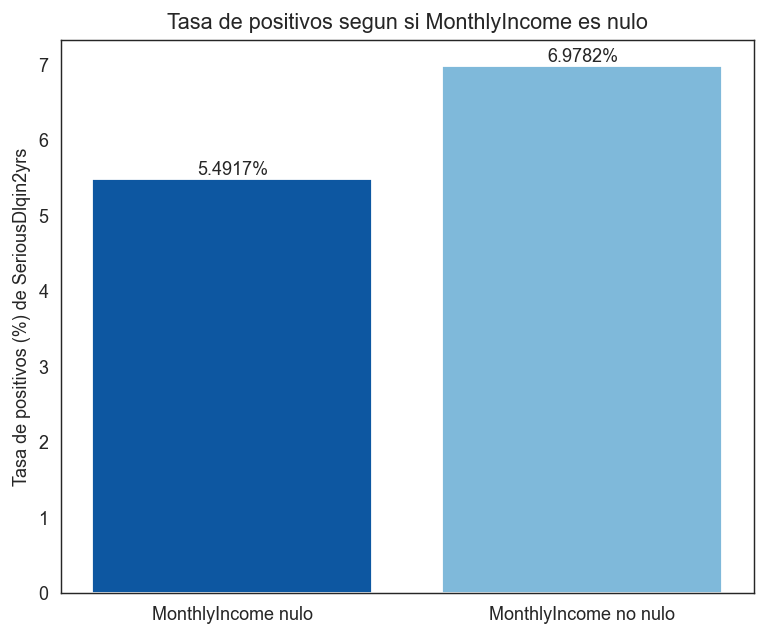

In [79]:
fig, ax = plt.subplots(figsize=(6, 5))
color_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.85)
color_no_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.45)
ax.bar(tasa_target_por_nulo_mi.index, tasa_target_por_nulo_mi["tasa_positivos_pct"],
       color=[color_nulo, color_no_nulo])
for i, v in enumerate(tasa_target_por_nulo_mi["tasa_positivos_pct"]):
    ax.text(i, v, f"{v:.4f}%", ha="center", va="bottom")
ax.set_ylabel("Tasa de positivos (%) de SeriousDlqin2yrs")
ax.set_title("Tasa de positivos segun si MonthlyIncome es nulo")
guardar_figura(fig, "08_tasa_target_por_nulo_monthlyincome")

**Hallazgo 8.1:** la tasa de positivos **no** es igual entre ambos grupos, pero la diferencia
va en el sentido contrario al que se podria esperar de entrada: las 20795 filas con
`MonthlyIncome` nulo tienen una tasa de positivos de 5.4917% (1142 positivos), mientras que las
84205 filas con `MonthlyIncome` no nulo tienen una tasa de 6.9782% (5876 positivos), es decir
1.4865 puntos porcentuales mas alta. En otras palabras, el nulo de `MonthlyIncome` **no
identifica un subgrupo de mayor riesgo** de impago; si acaso, el subgrupo con ingreso nulo
incumple algo menos. Aun asi, la diferencia es lo bastante consistente (sobre 20795 filas) como
para descartar que el nulo sea puramente aleatorio respecto al target: el mecanismo de
ausencia esta relacionado con el target, aunque no de forma directa, por lo que conviene
preservar esa senal con una variable indicadora en vez de borrarla al imputar.

### 8.2 El nulo de `MonthlyIncome` explica los valores atipicos de `DebtRatio`?

**Objetivo:** comparar la distribucion de `DebtRatio` (mediana, media, percentil 99, maximo y
% de filas con `DebtRatio` > 1) entre filas con `MonthlyIncome` nulo y no nulo, para confirmar
si el patron de outliers de `DebtRatio` detectado en el Hallazgo 3.3 esta concentrado en las
filas con ingreso nulo (lo que apuntaria a un artefacto de calculo: `DebtRatio` probablemente
se define como deuda mensual / `MonthlyIncome`, y con `MonthlyIncome` ausente/tratado como 0-1 el
ratio se dispara).

In [80]:
debt_mi_nulo = df_train.loc[mask_mi_nulo, "DebtRatio"]
debt_mi_no_nulo = df_train.loc[~mask_mi_nulo, "DebtRatio"]

debtratio_por_nulo_mi = pd.DataFrame({
    "mediana": [debt_mi_nulo.median(), debt_mi_no_nulo.median()],
    "media": [debt_mi_nulo.mean(), debt_mi_no_nulo.mean()],
    "p99": [debt_mi_nulo.quantile(0.99), debt_mi_no_nulo.quantile(0.99)],
    "maximo": [debt_mi_nulo.max(), debt_mi_no_nulo.max()],
    "pct_debtratio_mayor_1": [
        (debt_mi_nulo > 1).mean() * 100,
        (debt_mi_no_nulo > 1).mean() * 100,
    ],
}, index=["MonthlyIncome nulo", "MonthlyIncome no nulo"]).round(4)

factor_mediana = debtratio_por_nulo_mi.loc["MonthlyIncome nulo", "mediana"] / \
    debtratio_por_nulo_mi.loc["MonthlyIncome no nulo", "mediana"]
print(f"La mediana de DebtRatio con MonthlyIncome nulo es {factor_mediana:.2f}x "
      f"la mediana con MonthlyIncome no nulo")

guardar_tabla(debtratio_por_nulo_mi, "08_debtratio_por_nulo_monthlyincome")
debtratio_por_nulo_mi

La mediana de DebtRatio con MonthlyIncome nulo es 3999.32x la mediana con MonthlyIncome no nulo


,mediana,media,p99,maximo,pct_debtratio_mayor_1
MonthlyIncome nulo,1181.0000,1682.1970,8199.48,329664.0,93.9120
MonthlyIncome no nulo,0.2953,26.1928,650.76,60212.0,6.0151


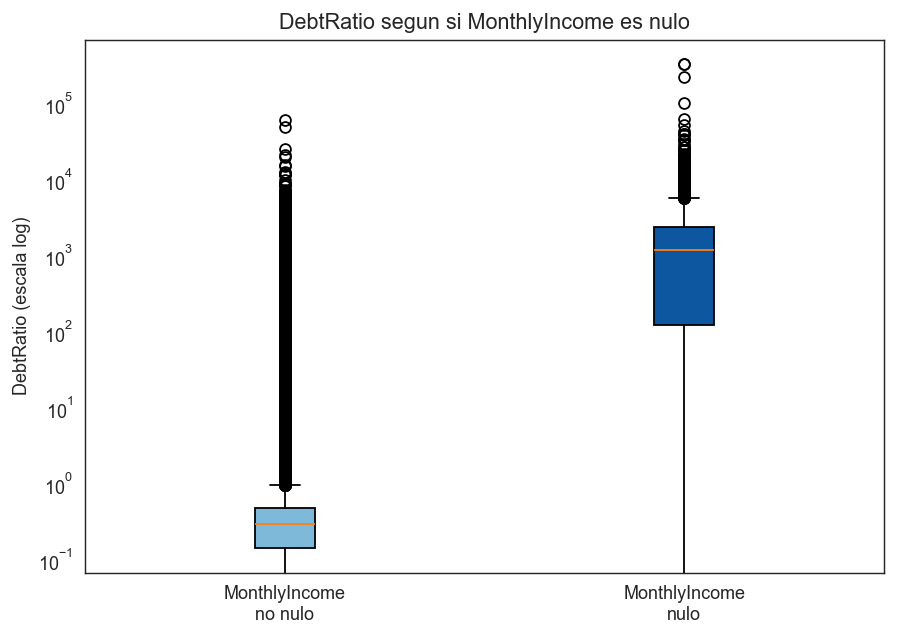

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))
color_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.85)
color_no_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.45)
datos_boxplot = [debt_mi_no_nulo, debt_mi_nulo]
bp = ax.boxplot(datos_boxplot, labels=["MonthlyIncome\nno nulo", "MonthlyIncome\nnulo"],
                 patch_artist=True, showfliers=True)
for patch, color in zip(bp["boxes"], [color_no_nulo, color_nulo]):
    patch.set_facecolor(color)
ax.set_yscale("log")
ax.set_ylabel("DebtRatio (escala log)")
ax.set_title("DebtRatio segun si MonthlyIncome es nulo")
guardar_figura(fig, "08_debtratio_boxplot_nulo_monthlyincome")

**Hallazgo 8.2:** el nulo de `MonthlyIncome` esta fuertemente asociado a valores extremos de
`DebtRatio`. Cuando `MonthlyIncome` es nulo, la mediana de `DebtRatio` es 1181.0 (media
1682.197, p99 8199.48, maximo 329664.0) y un 93.912% de las filas tiene `DebtRatio` > 1; cuando
`MonthlyIncome` no es nulo, la mediana es solo 0.2953 (media 26.1928, p99 650.76, maximo
60212.0) y solo un 6.0151% supera 1. Es decir, la mediana de `DebtRatio` es unas 3999.32 veces
mayor en el grupo con ingreso nulo (tal y como imprime la celda de codigo: 3999.32x). Esto confirma, con numeros a nivel de todo el dataset (no
solo en la cola extrema de `DebtRatio` vista en 3.3), que los valores disparados de `DebtRatio`
no son variabilidad real del ratio deuda/ingreso sino un artefacto que aparece precisamente
cuando `MonthlyIncome` falta: si `DebtRatio` se calculo como deuda mensual / `MonthlyIncome`
antes de que el ingreso se guardara como nulo (o dividiendo por un ingreso ausente/casi cero),
el resultado es un numero sin sentido economico. **Implicacion practica:** no se debe usar
`DebtRatio` tal cual en las filas con `MonthlyIncome` nulo sin tratarlo, porque contamina
cualquier modelo con una pseudo-senal que en realidad delata el propio nulo de `MonthlyIncome`.

### 8.3 Patron de nulos de `NumberOfDependents`: relacion con `MonthlyIncome`, el target y la edad

**Objetivo:** comprobar si los nulos de `NumberOfDependents` coinciden con los de
`MonthlyIncome` (co-ocurrencia), si tienen una tasa de positivos distinta a las filas completas,
y si el subgrupo con `NumberOfDependents` nulo tiene un perfil de edad distinto (lo que
ayudaria a decidir si conviene una imputacion simple o por grupo).

In [82]:
mask_nd_nulo = df_train["NumberOfDependents"].isna()

crosstab_nulos = pd.crosstab(
    mask_mi_nulo.map({True: "MonthlyIncome nulo", False: "MonthlyIncome no nulo"}),
    mask_nd_nulo.map({True: "NumberOfDependents nulo", False: "NumberOfDependents no nulo"}),
)
pct_nd_nulo_que_es_tambien_mi_nulo = df_train.loc[mask_nd_nulo, "MonthlyIncome"].isna().mean() * 100

tasa_target_por_nulo_nd = pd.DataFrame({
    "n_filas": [int(mask_nd_nulo.sum()), int((~mask_nd_nulo).sum())],
    "tasa_positivos_pct": [
        df_train.loc[mask_nd_nulo, TARGET].mean() * 100,
        df_train.loc[~mask_nd_nulo, TARGET].mean() * 100,
    ],
    "age_mediana": [
        df_train.loc[mask_nd_nulo, "age"].median(),
        df_train.loc[~mask_nd_nulo, "age"].median(),
    ],
}, index=["NumberOfDependents nulo", "NumberOfDependents no nulo"]).round(4)

print(f"% de filas con NumberOfDependents nulo que TAMBIEN tienen MonthlyIncome nulo: "
      f"{pct_nd_nulo_que_es_tambien_mi_nulo:.4f}%")
print(crosstab_nulos)

guardar_tabla(crosstab_nulos, "08_crosstab_nulos_monthlyincome_dependents")
guardar_tabla(tasa_target_por_nulo_nd, "08_tasa_target_edad_por_nulo_dependents")
tasa_target_por_nulo_nd

% de filas con NumberOfDependents nulo que TAMBIEN tienen MonthlyIncome nulo: 100.0000%
NumberOfDependents     NumberOfDependents no nulo  NumberOfDependents nulo
MonthlyIncome                                                             
MonthlyIncome no nulo                       84205                        0
MonthlyIncome nulo                          18057                     2738


,n_filas,tasa_positivos_pct,age_mediana
NumberOfDependents nulo,2738,4.6749,61.0
NumberOfDependents no nulo,102262,6.7376,52.0


**Hallazgo 8.3:** los nulos de `NumberOfDependents` no son independientes de los de
`MonthlyIncome`: de las 2738 filas con `NumberOfDependents` nulo, el 100.0000% tiene tambien
`MonthlyIncome` nulo (son un subconjunto exacto de las 20795 filas con `MonthlyIncome` nulo,
segun la tabla de contingencia). Al igual que con `MonthlyIncome`, la tasa de positivos del
subgrupo con `NumberOfDependents` nulo es **mas baja**, no mas alta: 4.6749% frente a 6.7376%
en el resto (diferencia de 2.0627 puntos porcentuales). Ademas, el subgrupo con
`NumberOfDependents` nulo es notablemente mas mayor: mediana de edad 61.0 anios frente a 52.0
anios en el resto. El patron conjunto (nulo de `NumberOfDependents` siempre viene acompanado de
nulo de `MonthlyIncome`, mas edad, menor tasa de positivos) es compatible con un perfil de
cliente mas mayor con menos datos financieros/familiares registrados en el formulario, y refuerza
que ambos nulos comparten un mismo mecanismo de ausencia (no aleatorio), en vez de ser dos
fenomenos independientes.

### 8.4 Evidencia para imputar por grupo: `MonthlyIncome` varia con la edad

**Objetivo:** comprobar si la mediana de `MonthlyIncome` (en las filas donde si se conoce)
varia de forma relevante segun el tramo de edad, lo que justificaria imputar por mediana **por
grupo de edad** en vez de con una unica mediana global.

In [83]:
bins_edad = [0, 30, 40, 50, 60, 70, 120]
etiquetas_edad = ["<=30", "31-40", "41-50", "51-60", "61-70", ">70"]
tramo_edad = pd.cut(df_train["age"], bins=bins_edad, labels=etiquetas_edad)

mediana_income_por_tramo_edad = (
    df_train.loc[~mask_mi_nulo]
    .groupby(tramo_edad, observed=True)["MonthlyIncome"]
    .median()
    .rename("mediana_monthlyincome")
    .to_frame()
)
mediana_global = df_train["MonthlyIncome"].median()
mediana_income_por_tramo_edad["diferencia_vs_mediana_global"] = (
    mediana_income_por_tramo_edad["mediana_monthlyincome"] - mediana_global
)

print(f"Mediana global de MonthlyIncome (todas las filas no nulas): {mediana_global}")
guardar_tabla(mediana_income_por_tramo_edad, "08_mediana_monthlyincome_por_tramo_edad")
mediana_income_por_tramo_edad

Mediana global de MonthlyIncome (todas las filas no nulas): 5400.0


,mediana_monthlyincome,diferencia_vs_mediana_global
age,,
<=30,2800.0,-2600.0
31-40,4950.0,-450.0
41-50,6083.0,683.0
51-60,6307.0,907.0
61-70,5833.0,433.0
>70,4500.0,-900.0


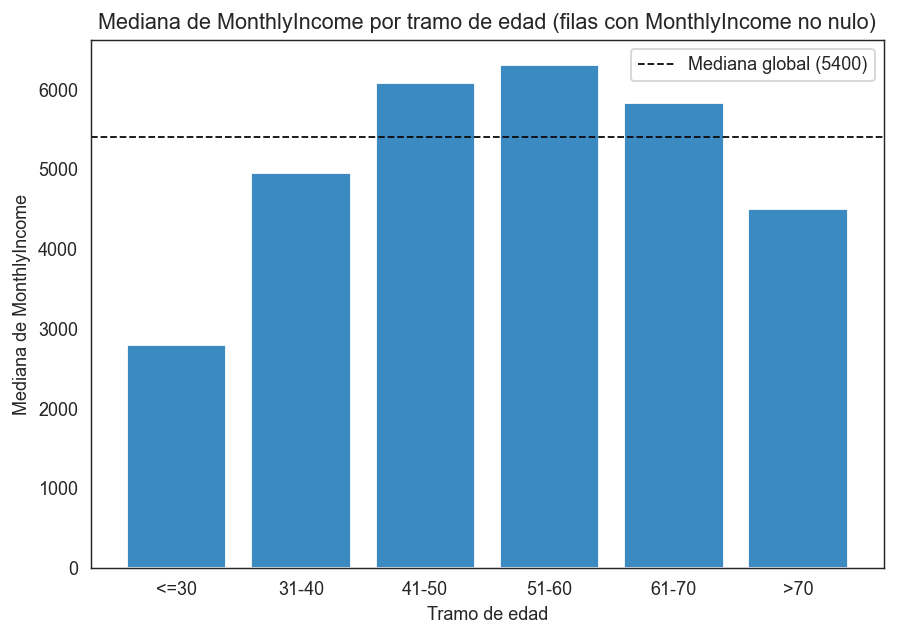

In [84]:
fig, ax = plt.subplots(figsize=(7, 5))
color_barras = plt.get_cmap(CMAP_SEQUENTIAL)(0.65)
ax.bar(mediana_income_por_tramo_edad.index.astype(str),
       mediana_income_por_tramo_edad["mediana_monthlyincome"], color=color_barras)
ax.axhline(mediana_global, color=COLOR_INK_PRIMARY, linestyle="--", linewidth=1,
           label=f"Mediana global ({mediana_global:.0f})")
ax.set_xlabel("Tramo de edad")
ax.set_ylabel("Mediana de MonthlyIncome")
ax.set_title("Mediana de MonthlyIncome por tramo de edad (filas con MonthlyIncome no nulo)")
ax.legend()
guardar_figura(fig, "08_mediana_monthlyincome_por_tramo_edad")

**Hallazgo 8.4:** la mediana de `MonthlyIncome` cambia de forma sustancial segun el tramo de
edad: 2800.0 en el tramo `<=30`, sube hasta un maximo de 6307.0 en `51-60`, y vuelve a bajar a
4500.0 en `>70` (tabla completa en `08_mediana_monthlyincome_por_tramo_edad.csv`), frente a una
mediana global de 5400.0 (calculada solo sobre las 84205 filas no nulas). La diferencia entre el
tramo mas bajo (`<=30`, 2800.0) y el mas alto (`51-60`, 6307.0) es de 3507.0, mas del doble de
la mediana global. Imputar con una unica mediana global asignaria a los clientes jovenes
(`<=30`) un ingreso 2600.0 unidades por encima de lo tipico en su tramo, y a los mayores de 70
un ingreso 900.0 unidades por encima de lo tipico en el suyo. Esto es evidencia a favor de
imputar `MonthlyIncome` con la mediana **por tramo de edad** en vez de con la mediana global
unica.

### 8.5 Recomendacion consolidada de imputacion por columna

**Objetivo:** resumir en una unica tabla, para cada columna con nulos, el porcentaje de nulos,
la evidencia clave de las secciones 8.1-8.4 (y 3.3) y la estrategia de imputacion recomendada
para `02_preprocesado.ipynb`.

In [85]:
recomendacion_imputacion_nulos = pd.DataFrame([
    {
        "columna": "MonthlyIncome",
        "pct_nulos": tabla_nulos_train.loc["MonthlyIncome", "pct_nulos"],
        "evidencia_clave": (
            "Tasa de positivos distinta del resto (5.4917% vs 6.9782%, Hallazgo 8.1); "
            "DebtRatio ~3999.32x mas alto en mediana cuando MonthlyIncome es nulo "
            "(Hallazgo 8.2, ligado a Hallazgo 3.3); mediana de MonthlyIncome varia con la "
            "edad (2800.0 a 6307.0 segun tramo, Hallazgo 8.4)."
        ),
        "estrategia_recomendada": (
            "Imputar por mediana condicionada al tramo de edad (no mediana global unica) "
            "y anadir variable indicadora is_missing_monthlyincome (MNAR: la ausencia "
            "correlaciona con el target y con DebtRatio). Recalcular/tratar DebtRatio en "
            "las filas imputadas en vez de dejar el valor original (posible artefacto de "
            "division por ingreso nulo/casi cero)."
        ),
    },
    {
        "columna": "NumberOfDependents",
        "pct_nulos": tabla_nulos_train.loc["NumberOfDependents", "pct_nulos"],
        "evidencia_clave": (
            "100.0000% de las filas con NumberOfDependents nulo tienen tambien "
            "MonthlyIncome nulo (Hallazgo 8.3); tasa de positivos distinta del resto "
            "(4.6749% vs 6.7376%) y edad mediana mayor (61.0 vs 52.0 anios)."
        ),
        "estrategia_recomendada": (
            "Imputar con la moda/mediana global (0, ver Hallazgo 2.1 y valor mas frecuente "
            "de la columna) por ser variable discreta de conteo con nulos concentrados en "
            "un subgrupo minoritario (2.6076%), y anadir variable indicadora "
            "is_missing_numberofdependents; dado que este nulo es subconjunto del de "
            "MonthlyIncome, valorar en 02_preprocesado.ipynb si un unico flag combinado "
            "'is_missing_datos_financieros' es preferible a dos flags redundantes."
        ),
    },
])
guardar_tabla(recomendacion_imputacion_nulos, "08_recomendacion_imputacion_nulos")
recomendacion_imputacion_nulos

,columna,pct_nulos,evidencia_clave,estrategia_recomendada
0,MonthlyIncome,19.8048,Tasa de positivos distinta del resto (5.4917% ...,Imputar por mediana condicionada al tramo de e...
1,NumberOfDependents,2.6076,100.0000% de las filas con NumberOfDependents ...,"Imputar con la moda/mediana global (0, ver Hal..."


**Hallazgo 8.5 (recomendacion final para `02_preprocesado.ipynb`):** las dos unicas columnas
con nulos de `df_train` (`MonthlyIncome`, 19.8048% de nulos, y `NumberOfDependents`, 2.6076% de
nulos, Hallazgo 2.3) muestran un patron de ausencia no aleatorio: correlaciona con una tasa de
positivos distinta a la del resto del dataset (Hallazgos 8.1 y 8.3), con valores extremos de
`DebtRatio` (Hallazgo 8.2, coherente con Hallazgo 3.3) y con la edad (Hallazgo 8.3), y el nulo
de `NumberOfDependents` aparece siempre junto al de `MonthlyIncome` (100.0000% de solapamiento,
Hallazgo 8.3). Por tanto, **no se recomienda una imputacion "ciega" con una unica mediana
global**: la recomendacion concreta es (1) imputar `MonthlyIncome` con la mediana **por tramo
de edad** (Hallazgo 8.4) en vez de la mediana global unica, (2) imputar `NumberOfDependents`
con su moda/mediana global (0), (3) anadir variable(s) indicadora(s) de "era nulo" para
preservar la senal de ausencia detectada en 8.1/8.3 dado que el mecanismo es MNAR, y (4) tratar
`DebtRatio` en las filas donde `MonthlyIncome` era nulo como un valor potencialmente
contaminado (recalcular tras imputar o capar/winsorizar, en linea con la recomendacion ya hecha
en el Hallazgo 3.3), en vez de dejarlo pasar sin mas al modelo. Esta sigue siendo una
recomendacion (evidencia para D-1.1 en `docs/DECISIONES.md`): la decision final de imputacion
y su implementacion se cierran en `02_preprocesado.ipynb`.

### 8.6 Test estadistico formal del patron de nulos frente al target, controlando por edad

**Objetivo:** las secciones 8.1 y 8.3 comparan la tasa de positivos entre los grupos con y sin
nulo de `MonthlyIncome` y `NumberOfDependents` de forma puramente descriptiva (diferencias en
puntos porcentuales), sin ningun test de significancia estadistica y sin controlar por la edad,
un posible factor de confusion que el propio Hallazgo 8.3 detecta (el grupo con
`NumberOfDependents` nulo es notablemente mas mayor: mediana de edad 61 anios frente a 52).
Esta subseccion formaliza esa evidencia descriptiva con (a) un test de independencia
chi-cuadrado y un test de proporciones para cada variable, y (b) una regresion logistica que
controla explicitamente por `age`, de forma que se pueda aislar la senal de "missingness" del
efecto de la edad antes de dar por buena, con respaldo estadistico y no solo descriptivo, la
conclusion de nulo informativo (MNAR) que sustenta la recomendacion del Hallazgo 8.5.

In [86]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# --- MonthlyIncome ---
tabla_contingencia_mi = pd.crosstab(mask_mi_nulo, df_train[TARGET])
chi2_mi, p_chi2_mi, dof_mi, _ = chi2_contingency(tabla_contingencia_mi)
z_stat_mi, p_prop_mi = proportions_ztest(
    count=[int(df_train.loc[mask_mi_nulo, TARGET].sum()),
           int(df_train.loc[~mask_mi_nulo, TARGET].sum())],
    nobs=[int(mask_mi_nulo.sum()), int((~mask_mi_nulo).sum())],
)

# --- NumberOfDependents ---
tabla_contingencia_nd = pd.crosstab(mask_nd_nulo, df_train[TARGET])
chi2_nd, p_chi2_nd, dof_nd, _ = chi2_contingency(tabla_contingencia_nd)
z_stat_nd, p_prop_nd = proportions_ztest(
    count=[int(df_train.loc[mask_nd_nulo, TARGET].sum()),
           int(df_train.loc[~mask_nd_nulo, TARGET].sum())],
    nobs=[int(mask_nd_nulo.sum()), int((~mask_nd_nulo).sum())],
)

tabla_test_missingness = pd.DataFrame({
    "variable_nulo": ["MonthlyIncome", "NumberOfDependents"],
    "chi2": [chi2_mi, chi2_nd],
    "p_valor_chi2": [p_chi2_mi, p_chi2_nd],
    "z_stat_proporciones": [z_stat_mi, z_stat_nd],
    "p_valor_proporciones": [p_prop_mi, p_prop_nd],
})

guardar_tabla(tabla_test_missingness, "08_test_estadistico_missingness")
tabla_test_missingness

,variable_nulo,chi2,p_valor_chi2,z_stat_proporciones,p_valor_proporciones
0,MonthlyIncome,58.844309,1.706547e-14,-7.686508,1.512055e-14
1,NumberOfDependents,17.860624,2.376886e-05,-4.264953,1.999438e-05


In [87]:
import statsmodels.formula.api as smf

df_logit_missingness = pd.DataFrame({
    TARGET: df_train[TARGET],
    "is_missing_monthlyincome": mask_mi_nulo.astype(int),
    "is_missing_numberofdependents": mask_nd_nulo.astype(int),
    "age": df_train["age"],
})

modelo_logit_missingness = smf.logit(
    f"{TARGET} ~ is_missing_monthlyincome + is_missing_numberofdependents + age",
    data=df_logit_missingness,
).fit(disp=0)

resumen_logit_missingness = modelo_logit_missingness.summary2().tables[1]
resumen_logit_missingness["odds_ratio"] = np.exp(modelo_logit_missingness.params)

guardar_tabla(resumen_logit_missingness, "08_logit_missingness_controlando_edad")

p_valor_mi = resumen_logit_missingness.loc["is_missing_monthlyincome", "P>|z|"]
odds_ratio_mi = resumen_logit_missingness.loc["is_missing_monthlyincome", "odds_ratio"]
p_valor_nd = resumen_logit_missingness.loc["is_missing_numberofdependents", "P>|z|"]
odds_ratio_nd = resumen_logit_missingness.loc["is_missing_numberofdependents", "odds_ratio"]

print(f"is_missing_monthlyincome (controlando por age): p-valor={p_valor_mi:.6g}, "
      f"odds ratio={odds_ratio_mi:.4f}")
print(f"is_missing_numberofdependents (controlando por age): p-valor={p_valor_nd:.6g}, "
      f"odds ratio={odds_ratio_nd:.4f}")

resumen_logit_missingness

is_missing_monthlyincome (controlando por age): p-valor=0.012248, odds ratio=0.9150
is_missing_numberofdependents (controlando por age): p-valor=0.114677, odds ratio=0.8580


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
Intercept,-0.978032,0.043895,-22.281118,5.633414e-110,-1.064065,-0.891999,0.376050
is_missing_monthlyincome,-0.088808,0.035454,-2.504916,1.224804e-02,-0.158296,-0.019321,0.915021
is_missing_numberofdependents,-0.153094,0.097048,-1.577515,1.146771e-01,-0.343304,0.037116,0.858049
age,-0.033336,0.000914,-36.469650,3.358684e-291,-0.035128,-0.031545,0.967213


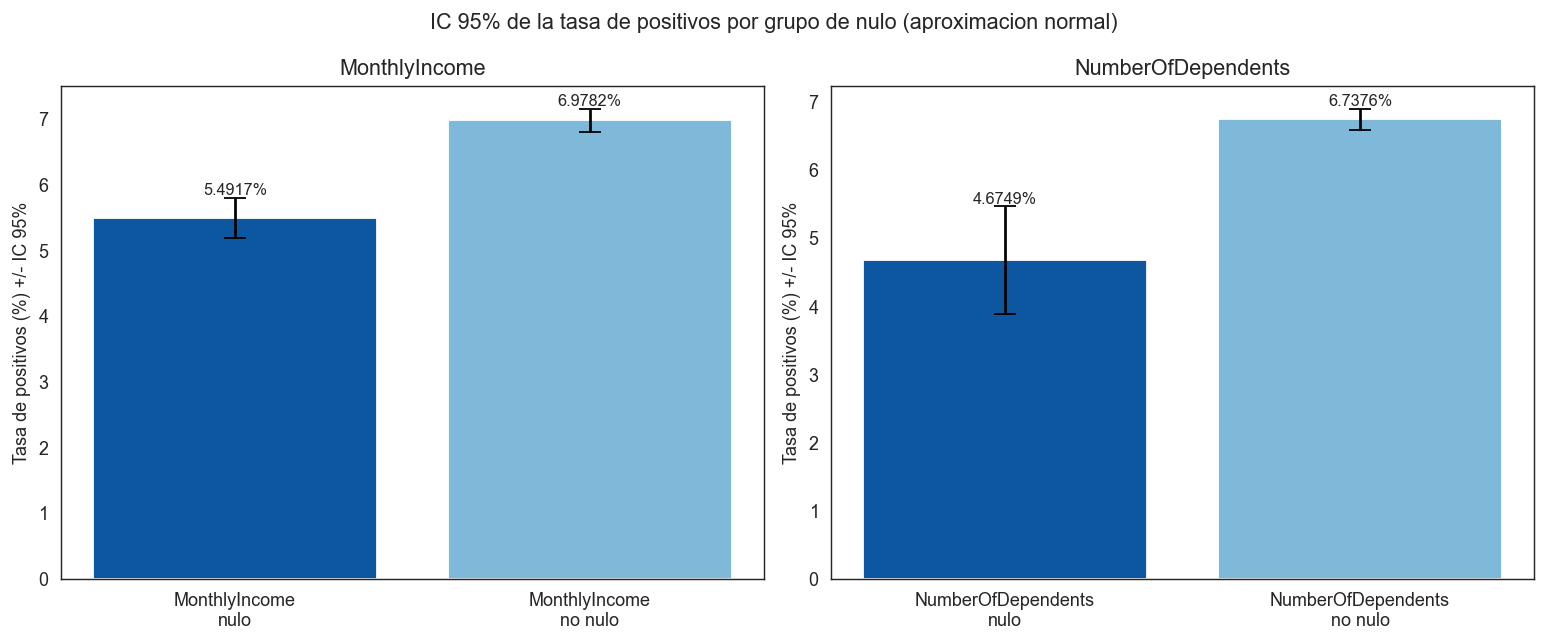

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
color_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.85)
color_no_nulo = plt.get_cmap(CMAP_SEQUENTIAL)(0.45)

especificacion_variables_86 = [
    (mask_mi_nulo, "MonthlyIncome", axes[0]),
    (mask_nd_nulo, "NumberOfDependents", axes[1]),
]

for mask_nulo_var, nombre_variable, ax in especificacion_variables_86:
    etiquetas_grupo = [f"{nombre_variable}\nnulo", f"{nombre_variable}\nno nulo"]
    tasas_pct = []
    margenes_pct = []
    for grupo_mask in [mask_nulo_var, ~mask_nulo_var]:
        n_grupo = int(grupo_mask.sum())
        p_grupo = df_train.loc[grupo_mask, TARGET].mean()
        margen_error = 1.96 * np.sqrt(p_grupo * (1 - p_grupo) / n_grupo)
        tasas_pct.append(p_grupo * 100)
        margenes_pct.append(margen_error * 100)
    ax.bar(etiquetas_grupo, tasas_pct, yerr=margenes_pct, capsize=6,
           color=[color_nulo, color_no_nulo])
    for i, (v, e) in enumerate(zip(tasas_pct, margenes_pct)):
        ax.text(i, v + e, f"{v:.4f}%", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Tasa de positivos (%) +/- IC 95%")
    ax.set_title(nombre_variable)

fig.suptitle("IC 95% de la tasa de positivos por grupo de nulo (aproximacion normal)")
guardar_figura(fig, "08_test_estadistico_missingness_intervalos")

**Hallazgo 8.6:** los tests formales confirman, con significancia estadistica clara, que el
patron de nulos de ambas variables **no** es independiente del target: para `MonthlyIncome`,
chi-cuadrado = 58.844309 (p = 1.706547e-14) y test de proporciones z = -7.686508
(p = 1.512055e-14); para `NumberOfDependents`, chi-cuadrado = 17.860624 (p = 2.376886e-05) y
test de proporciones z = -4.264953 (p = 1.999438e-05). Los cuatro p-valores estan muy por
debajo de 0.05, por lo que la diferencia descriptiva ya vista en los Hallazgos 8.1 y 8.3
(tasas de positivos mas bajas en ambos grupos con nulo) no es atribuible al azar.

Al ajustar la regresion logistica multivariante que controla simultaneamente por `age` y por
el otro indicador de nulo, el resultado difiere entre las dos variables. `is_missing_monthlyincome`
**sigue siendo estadisticamente significativo** tras controlar por `age` (p = 0.012248, muy
por debajo de 0.05) con un odds ratio de 0.915021: tener `MonthlyIncome` nulo se asocia con
unas probabilidades (odds) de impago un 8.4979% mas bajas que no tenerlo (1 - 0.915021),
incluso despues de aislar el efecto de la edad (odds ratio de `age` = 0.967213 por cada anio
adicional, coherente con que los clientes mas mayores incumplen menos). En cambio,
`is_missing_numberofdependents` **deja de ser significativo al 5%** una vez controlado por
`age`: p = 0.114677, con un odds ratio de 0.858049 cuya direccion es consistente con el
Hallazgo 8.3 (menor tasa de positivos) pero que ya no se puede distinguir del azar en este
modelo. Esto es coherente con el propio Hallazgo 8.3, que detecto que el nulo de
`NumberOfDependents` es un subconjunto exacto (100.0000%) del nulo de `MonthlyIncome` y que su
grupo es notablemente mas mayor (mediana 61 vs 52 anios): gran parte de la senal descriptiva de
esa variable parece explicarse por la edad y por su solapamiento total con
`is_missing_monthlyincome`, mas que por un mecanismo de ausencia propio e independiente.

En conjunto, esta subseccion **refuerza con respaldo estadistico formal** (y no solo
descriptivo) la recomendacion del Hallazgo 8.5 de anadir la variable indicadora
`is_missing_monthlyincome`: su caracter MNAR sobrevive al control por el confusor de edad
detectado en el propio Hallazgo 8.3. Para `is_missing_numberofdependents` la evidencia
univariante (chi-cuadrado y test de proporciones) sigue siendo significativa, pero la
regresion multivariante sugiere que su aporte de informacion, una vez incluidas `age` e
`is_missing_monthlyincome`, es mas limitado; esto apoya la sugerencia ya recogida en el
Hallazgo 8.5 de valorar en `02_preprocesado.ipynb` si un unico flag combinado
(`is_missing_datos_financieros`) es preferible a mantener dos indicadores parcialmente
redundantes, en vez de asumir sin mas que ambos aportan senal independiente.

## 9. Estrategia de normalizacion y escalado (recomendacion)

Las secciones 3 y 4 ya cuantificaron el sesgo (`skew`) y los outliers reales de las 4
variables continuas de `df_train` (`age`, `DebtRatio`, `MonthlyIncome`,
`RevolvingUtilizationOfUnsecuredLines`, ver Hallazgo 2.4). El Hallazgo 4.1 mostro que 3 de
ellas tienen sesgo muy fuerte (`|skew| > 1`) y el Hallazgo 3.3/3.4 encontro que
`RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` tienen colas extremas muy por fuera del
rango logico esperado (261 filas con `RevolvingUtilizationOfUnsecuredLines > 2` y 2625 filas
de `DebtRatio` por encima de su percentil 97.5, muchas de ellas asociadas al artefacto de
`MonthlyIncome` nulo o casi 0). Esta seccion retoma esos numeros para responder dos preguntas
concretas de cara a `02_preprocesado.ipynb`: (1) que variables conviene transformar con
`log1p` antes de escalar, y (2) si conviene `StandardScaler` o `RobustScaler`, comparando
ambos con codigo real sobre las 2 variables con mas outliers
(`RevolvingUtilizationOfUnsecuredLines` y `DebtRatio`). El foco es en las 4 variables
continuas (seccion 2.4); las variables discretas/conteo ya tienen su propio tratamiento de
centinelas/missing recomendado en la seccion 3.4 y no se transforman con `log1p` aqui. Como en
las secciones 3 y 8, esto es una **recomendacion**: no se sobrescribe `df_train` ni `df_prod`,
solo se ilustra el efecto con codigo real sobre copias/arrays auxiliares.

### 9.1 Que variables conviene transformar con `log1p` antes de escalar

**Objetivo:** consolidar, para las 4 variables continuas, el `skew` original y tras `log1p`
(Hallazgo 4.1) junto con el porcentaje de filas marcadas como outlier en la seccion 3, para
decidir explicitamente sobre cuales aplicar `log1p` antes de escalar.

In [89]:
resumen_log1p_recomendacion = tabla_skew.copy()
resumen_log1p_recomendacion["aplicar_log1p"] = resumen_log1p_recomendacion.index.isin(vars_sesgo_fuerte)

pct_outliers_seccion3 = {
    "RevolvingUtilizationOfUnsecuredLines": round(n_rev_mayor2 / len(df_train) * 100, 4),
    "DebtRatio": round(n_debt_alto / len(df_train) * 100, 4),
    "MonthlyIncome": np.nan,
    "age": np.nan,
}
resumen_log1p_recomendacion["pct_outliers_seccion3"] = resumen_log1p_recomendacion.index.map(pct_outliers_seccion3)
resumen_log1p_recomendacion = resumen_log1p_recomendacion[
    ["skew_original", "skew_log1p", "aplicar_log1p", "pct_outliers_seccion3"]
]
guardar_tabla(resumen_log1p_recomendacion, "09_recomendacion_log1p_por_variable")
resumen_log1p_recomendacion

,skew_original,skew_log1p,aplicar_log1p,pct_outliers_seccion3
age,0.191780,-0.456203,False,NaN
DebtRatio,100.036844,1.749995,True,2.5000
MonthlyIncome,113.851716,-4.353312,True,NaN
RevolvingUtilizationOfUnsecuredLines,58.949939,11.766779,True,0.2486


**Hallazgo 9.1:** de las 4 variables continuas, 3 tienen `skew_original` con
`|skew| > 1` (umbral de la seccion 4.1) y se marcan con `aplicar_log1p = True`:
`MonthlyIncome` (skew_original 113.851716 -> skew_log1p -4.353312), `DebtRatio`
(100.036844 -> 1.749995) y `RevolvingUtilizationOfUnsecuredLines` (58.949939 -> 11.766779).
Estas dos ultimas son ademas las que la seccion 3 marco explicitamente con outliers de
codificacion: `RevolvingUtilizationOfUnsecuredLines > 2` afecta a 0.2486% de las filas
(Hallazgo 3.1/3.4) y `DebtRatio` por encima de su percentil 97.5 afecta a 2.5000% (Hallazgo
3.3/3.4). `age`, en cambio, tiene `skew_original` casi simetrico (0.191780) y `log1p` lo
empeora en valor absoluto (-0.456203), por lo que `aplicar_log1p` es `False` para `age` y no
se cuantifico ningun criterio de outlier especifico para ella en la seccion 3 (solo el
centinela puntual `age == 0`, Hallazgo 3.2). **Recomendacion:** aplicar `log1p` a
`DebtRatio`, `MonthlyIncome` y `RevolvingUtilizationOfUnsecuredLines` antes de escalar; no
aplicarlo a `age`.

### 9.2 `StandardScaler` vs `RobustScaler` sobre las variables con mas outliers (sin transformar)

**Objetivo:** ajustar `StandardScaler` y `RobustScaler` directamente sobre los valores
originales (sin `log1p`) de `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` -las 2
variables con outliers mas extremos segun la seccion 3- y comparar como cambia el rango
(minimo, maximo y proporcion de valores "tipicos") tras escalar con cada uno.

In [90]:
from sklearn.preprocessing import StandardScaler, RobustScaler

vars_comparacion_scaler = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]
X_original_comparacion = df_train[vars_comparacion_scaler]

standard_scaler_demo = StandardScaler()
robust_scaler_demo = RobustScaler()

X_standard_demo = pd.DataFrame(
    standard_scaler_demo.fit_transform(X_original_comparacion),
    columns=vars_comparacion_scaler, index=X_original_comparacion.index,
)
X_robust_demo = pd.DataFrame(
    robust_scaler_demo.fit_transform(X_original_comparacion),
    columns=vars_comparacion_scaler, index=X_original_comparacion.index,
)

filas_comparacion_escalado = []
for col in vars_comparacion_scaler:
    filas_comparacion_escalado.append({
        "variable": col,
        "min_original": X_original_comparacion[col].min(),
        "max_original": X_original_comparacion[col].max(),
        "min_standard": X_standard_demo[col].min(),
        "max_standard": X_standard_demo[col].max(),
        "pct_dentro_pm1_standard": round((X_standard_demo[col].abs() <= 1).mean() * 100, 4),
        "min_robust": X_robust_demo[col].min(),
        "max_robust": X_robust_demo[col].max(),
        "pct_dentro_pm1_robust": round((X_robust_demo[col].abs() <= 1).mean() * 100, 4),
    })

tabla_comparacion_escalado_sin_log1p = pd.DataFrame(filas_comparacion_escalado).set_index("variable").round(4)
guardar_tabla(tabla_comparacion_escalado_sin_log1p, "09_comparacion_standard_robust_sin_log1p")
tabla_comparacion_escalado_sin_log1p

,min_original,max_original,min_standard,max_standard,pct_dentro_pm1_standard,min_robust,max_robust,pct_dentro_pm1_robust
variable,,,,,,,,
RevolvingUtilizationOfUnsecuredLines,0.0,22198.0,-0.0282,101.9470,99.8514,-0.2912,41793.8307,79.4905
DebtRatio,0.0,329664.0,-0.1771,164.7006,94.6190,-0.5274,474809.9900,77.0105


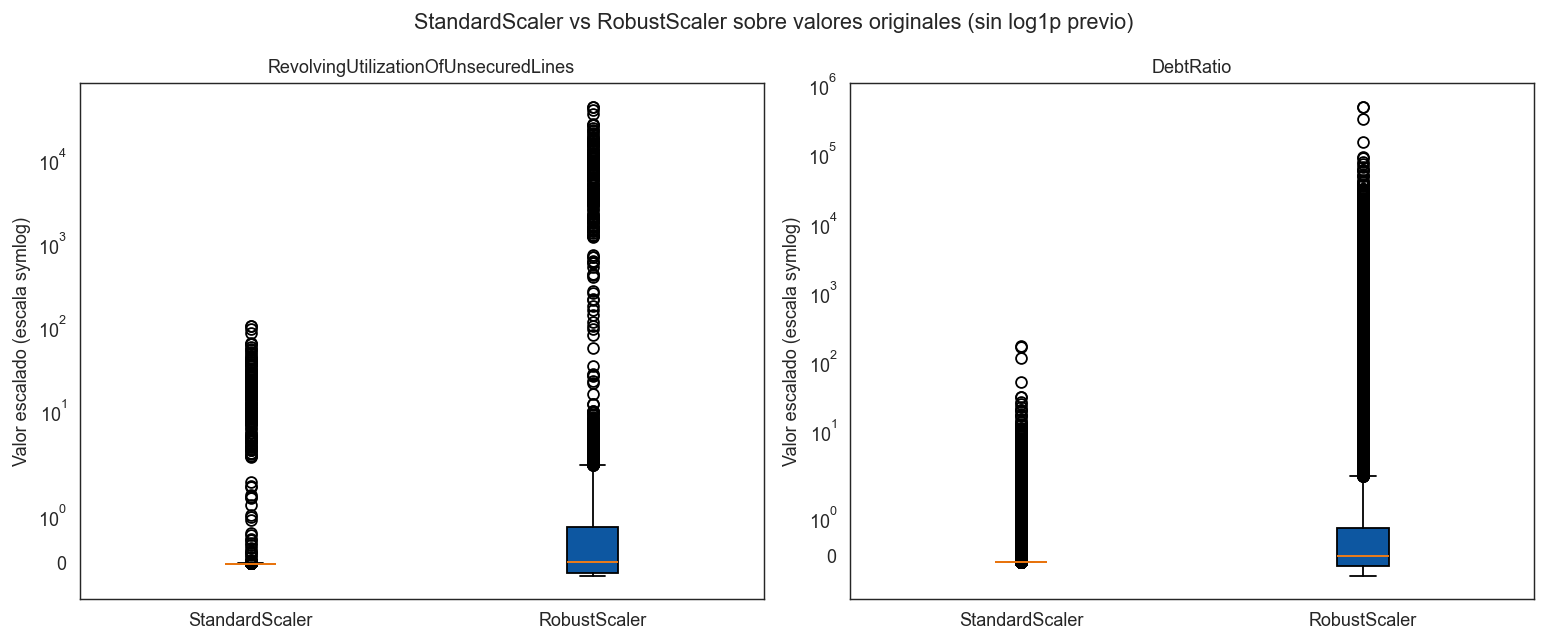

In [91]:
fig, axes = plt.subplots(1, len(vars_comparacion_scaler), figsize=(6 * len(vars_comparacion_scaler), 5))
color_standard = plt.get_cmap(CMAP_SEQUENTIAL)(0.45)
color_robust = plt.get_cmap(CMAP_SEQUENTIAL)(0.85)

for ax, col in zip(axes, vars_comparacion_scaler):
    bp = ax.boxplot(
        [X_standard_demo[col], X_robust_demo[col]],
        labels=["StandardScaler", "RobustScaler"],
        patch_artist=True, showfliers=True,
    )
    for patch, color in zip(bp["boxes"], [color_standard, color_robust]):
        patch.set_facecolor(color)
    ax.set_yscale("symlog")
    ax.set_ylabel("Valor escalado (escala symlog)")
    ax.set_title(col, fontsize=10)

fig.suptitle("StandardScaler vs RobustScaler sobre valores originales (sin log1p previo)")
guardar_figura(fig, "09_boxplot_standard_vs_robust_sin_log1p")

**Hallazgo 9.2:** sin aplicar `log1p`, ambos escaladores se ven dominados por las colas
extremas ya documentadas en la seccion 3, pero de forma distinta. En
`RevolvingUtilizationOfUnsecuredLines` (min/max original 0.0 / 22198.0),
`StandardScaler` deja un rango de -0.0282 a 101.9470, mientras que `RobustScaler` deja un
rango mucho mas amplio: -0.2912 a 41793.8307. En `DebtRatio` (min/max original 0.0 /
329664.0) ocurre lo mismo: `StandardScaler` queda en -0.1771 a 164.7006 y `RobustScaler` en
-0.5274 a 474809.9900. Esto parece contraintuitivo (`RobustScaler` deberia ser mas
"resistente" a outliers), pero se explica por lo compacto que es el IQR de estas 2 variables:
la mayoria de los valores estan muy cerca de 0 (mediana de `RevolvingUtilizationOfUnsecuredLines`
= 0.154674, mediana de `DebtRatio` = 0.366143, Hallazgo 2.1), asi que su IQR es pequeno frente
a las colas de decenas de miles; dividir esas colas por un IQR pequeno (RobustScaler) las
amplifica mas que dividirlas por una desviacion estandar ya inflada por los propios outliers
(StandardScaler). La contrapartida es que `StandardScaler` comprime casi todo el grueso de los
datos cerca de 0: el 99.8514% de `RevolvingUtilizationOfUnsecuredLines` y el 94.6190% de
`DebtRatio` quedan dentro de [-1, 1] tras `StandardScaler`, frente a solo 79.4905% y
77.0105% respectivamente con `RobustScaler` (es decir, `RobustScaler` conserva mas variabilidad
util para el grueso "tipico" de los datos, a costa de exagerar aun mas los outliers ya
identificados en la seccion 3). Ninguno de los dos escaladores por si solo resuelve el
problema de fondo: la cola extrema.

### 9.3 Efecto de aplicar `log1p` antes de escalar: por que importa el orden

**Objetivo:** repetir la comparacion de `StandardScaler` vs `RobustScaler` de la seccion 9.2
pero aplicando primero `log1p` (Hallazgo 4.1/9.1), y contrastar el rango resultante en los 4
escenarios (con/sin `log1p`, Standard/Robust) para decidir el orden de las transformaciones.

In [92]:
X_log1p_comparacion = df_train[vars_comparacion_scaler].clip(lower=0).apply(np.log1p)

standard_scaler_log1p = StandardScaler()
robust_scaler_log1p = RobustScaler()

X_log1p_standard = pd.DataFrame(
    standard_scaler_log1p.fit_transform(X_log1p_comparacion),
    columns=vars_comparacion_scaler, index=X_log1p_comparacion.index,
)
X_log1p_robust = pd.DataFrame(
    robust_scaler_log1p.fit_transform(X_log1p_comparacion),
    columns=vars_comparacion_scaler, index=X_log1p_comparacion.index,
)

filas_comparacion_escalado_log1p = []
for col in vars_comparacion_scaler:
    filas_comparacion_escalado_log1p.append({
        "variable": col,
        "min_log1p": X_log1p_comparacion[col].min(),
        "max_log1p": X_log1p_comparacion[col].max(),
        "min_standard_log1p": X_log1p_standard[col].min(),
        "max_standard_log1p": X_log1p_standard[col].max(),
        "min_robust_log1p": X_log1p_robust[col].min(),
        "max_robust_log1p": X_log1p_robust[col].max(),
    })

tabla_comparacion_escalado_con_log1p = pd.DataFrame(filas_comparacion_escalado_log1p).set_index("variable").round(4)
guardar_tabla(tabla_comparacion_escalado_con_log1p, "09_comparacion_standard_robust_con_log1p")
tabla_comparacion_escalado_con_log1p

,min_log1p,max_log1p,min_standard_log1p,max_standard_log1p,min_robust_log1p,max_robust_log1p
variable,,,,,,
RevolvingUtilizationOfUnsecuredLines,0.0,10.0078,-0.6638,25.0076,-0.3458,23.7189
DebtRatio,0.0,12.7058,-0.5800,4.2508,-0.6719,26.6913


In [93]:
tabla_rango_comparacion = pd.DataFrame({
    "rango_standard_sin_log1p": tabla_comparacion_escalado_sin_log1p["max_standard"] - tabla_comparacion_escalado_sin_log1p["min_standard"],
    "rango_robust_sin_log1p": tabla_comparacion_escalado_sin_log1p["max_robust"] - tabla_comparacion_escalado_sin_log1p["min_robust"],
    "rango_standard_con_log1p": tabla_comparacion_escalado_con_log1p["max_standard_log1p"] - tabla_comparacion_escalado_con_log1p["min_standard_log1p"],
    "rango_robust_con_log1p": tabla_comparacion_escalado_con_log1p["max_robust_log1p"] - tabla_comparacion_escalado_con_log1p["min_robust_log1p"],
}).round(4)
guardar_tabla(tabla_rango_comparacion, "09_rango_escalado_comparacion")
tabla_rango_comparacion

,rango_standard_sin_log1p,rango_robust_sin_log1p,rango_standard_con_log1p,rango_robust_con_log1p
variable,,,,
RevolvingUtilizationOfUnsecuredLines,101.9752,41794.1219,25.6714,24.0647
DebtRatio,164.8777,474810.5174,4.8308,27.3632


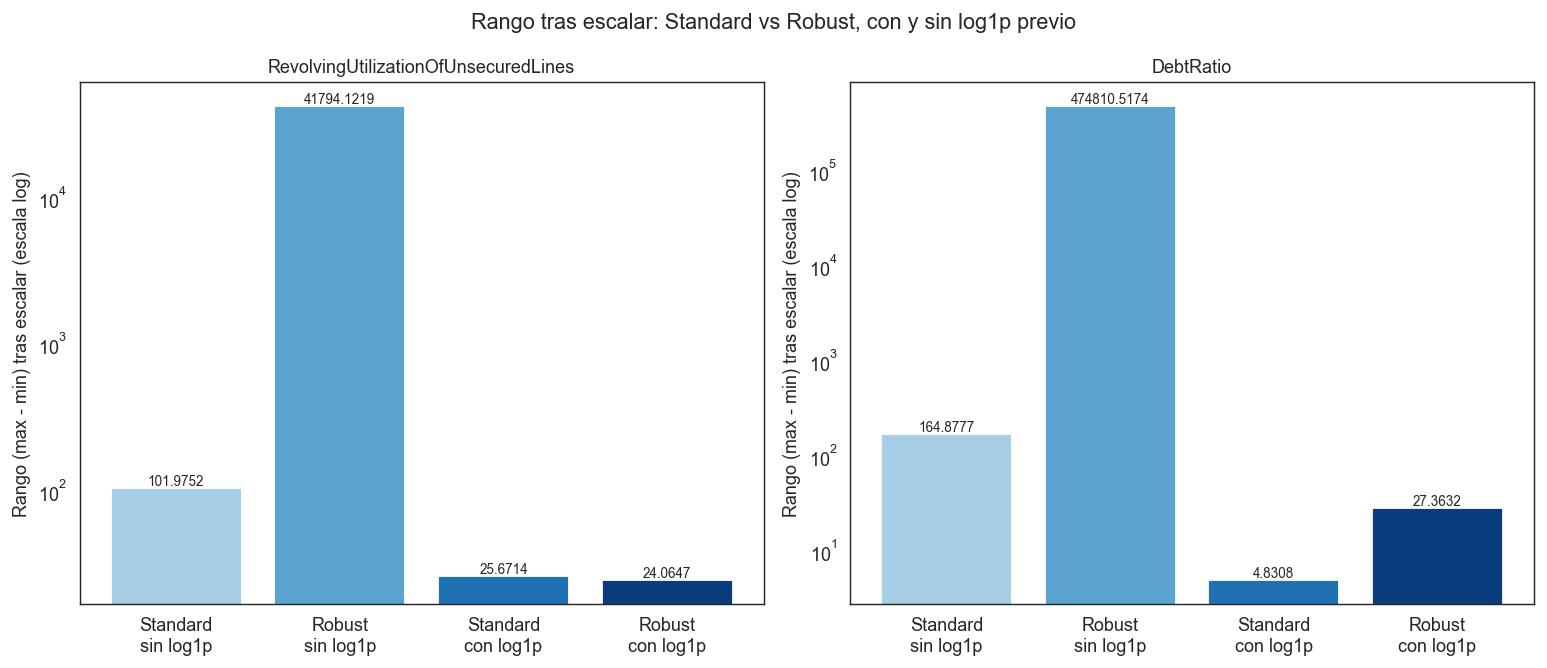

In [94]:
fig, axes = plt.subplots(1, len(vars_comparacion_scaler), figsize=(6 * len(vars_comparacion_scaler), 5.2))
etiquetas_escenarios = ["Standard\nsin log1p", "Robust\nsin log1p", "Standard\ncon log1p", "Robust\ncon log1p"]
colores_escenarios = [plt.get_cmap(CMAP_SEQUENTIAL)(v) for v in [0.35, 0.55, 0.75, 0.95]]

for ax, col in zip(axes, vars_comparacion_scaler):
    valores_rango = tabla_rango_comparacion.loc[col].values
    ax.bar(etiquetas_escenarios, valores_rango, color=colores_escenarios)
    ax.set_yscale("log")
    ax.set_ylabel("Rango (max - min) tras escalar (escala log)")
    ax.set_title(col, fontsize=10)
    for i, v in enumerate(valores_rango):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7.5)

fig.suptitle("Rango tras escalar: Standard vs Robust, con y sin log1p previo")
guardar_figura(fig, "09_rango_escalado_standard_vs_robust_log1p")

**Hallazgo 9.3:** aplicar `log1p` antes de escalar reduce drasticamente el rango en ambas
variables y en ambos escaladores. En `RevolvingUtilizationOfUnsecuredLines`, el rango de
`StandardScaler` baja de 101.9752 (sin `log1p`) a 25.6714 (con `log1p`), y el de
`RobustScaler` baja de 41794.1219 a 24.0647: tras `log1p`, ambos escaladores quedan en el
mismo orden de magnitud (25.6714 vs 24.0647), a diferencia de lo visto en el Hallazgo 9.2.
En `DebtRatio` el efecto de `log1p` tambien reduce mucho el rango absoluto, pero aparece una
asimetria: el rango de `StandardScaler` baja de 164.8777 a solo 4.8308, mientras que el de
`RobustScaler` baja de 474810.5174 pero se queda en 27.3632, casi 6 veces mayor que el de
`StandardScaler`. Esto ocurre porque, incluso tras `log1p`, `DebtRatio` conserva una cola
residual (los artefactos de division por `MonthlyIncome` nulo/casi 0 del Hallazgo 3.3) que
sigue siendo grande frente a su IQR ya comprimido por `log1p`, asi que `RobustScaler` -que
solo usa el IQR, no el resto de la distribucion- sigue amplificando esa cola mas que
`StandardScaler`. **Conclusion sobre el orden:** aplicar `log1p` primero es lo que mas reduce
el rango en las 2 variables (recomendacion de la seccion 9.1); una vez aplicado, para
`DebtRatio` conviene `StandardScaler` (rango 4.8308 tras log1p, claramente menor que el
27.3632 de `RobustScaler`), mientras que para `RevolvingUtilizationOfUnsecuredLines` el rango
resultante es similar con ambos (25.6714 vs 24.0647), por lo que la eleccion entre
`StandardScaler` y `RobustScaler` es secundaria frente a la decision, ya justificada, de
aplicar `log1p`.

### 9.4 Recomendacion consolidada de normalizacion y escalado por variable

**Objetivo:** resumir en una unica tabla, para cada una de las 4 variables continuas, si
conviene aplicar `log1p` y que escalador se recomienda, con la justificacion numerica de las
secciones 9.1-9.3, como entregable directo para `02_preprocesado.ipynb`.

In [95]:
recomendacion_normalizacion_escalado = pd.DataFrame([
    {
        "variable": "age",
        "aplicar_log1p": False,
        "scaler_recomendado": "StandardScaler",
        "justificacion": (
            "skew_original casi simetrico (0.191780, Hallazgo 4.1/9.1); log1p lo empeora "
            "(-0.456203) por lo que no se aplica. Sin outliers extremos documentados en la "
            "seccion 3 (unico problema es el centinela puntual age == 0, Hallazgo 3.2), "
            "StandardScaler es adecuado sin necesidad de una version robusta."
        ),
    },
    {
        "variable": "MonthlyIncome",
        "aplicar_log1p": True,
        "scaler_recomendado": "StandardScaler (tras log1p y tras imputar los nulos de la seccion 8)",
        "justificacion": (
            "skew_original muy fuerte (113.851716, Hallazgo 4.1), se reduce en valor absoluto "
            "tras log1p (-4.353312). El 19.8048% de nulos (Hallazgo 2.3) y su relacion con "
            "DebtRatio extremo (Hallazgo 3.3/8.2) deben resolverse con la imputacion "
            "condicionada por tramo de edad recomendada en la seccion 8 antes de escalar."
        ),
    },
    {
        "variable": "DebtRatio",
        "aplicar_log1p": True,
        "scaler_recomendado": "StandardScaler (tras log1p)",
        "justificacion": (
            "skew_original extremo (100.036844, Hallazgo 4.1), baja a 1.749995 tras log1p. "
            "Tras log1p (Hallazgo 9.3), el rango de StandardScaler (4.8308) es mucho menor "
            "que el de RobustScaler (27.3632), porque el IQR de DebtRatio es pequeno frente a "
            "la cola residual asociada al artefacto de MonthlyIncome nulo/casi 0 (Hallazgo "
            "3.3); esa cola conviene tratarla ademas como outlier/artefacto (Hallazgo 3.3/8.5) "
            "y no solo confiar en el escalador."
        ),
    },
    {
        "variable": "RevolvingUtilizationOfUnsecuredLines",
        "aplicar_log1p": True,
        "scaler_recomendado": "StandardScaler (rango similar a RobustScaler tras log1p)",
        "justificacion": (
            "skew_original muy fuerte (58.949939, Hallazgo 4.1). Tras log1p (Hallazgo 9.3), "
            "el rango de StandardScaler (25.6714) y el de RobustScaler (24.0647) quedan en el "
            "mismo orden de magnitud, a diferencia de DebtRatio; aun asi se recomienda "
            "capar/winsorizar los valores > 1-2 (Hallazgo 3.3/3.4, 0.2486% de las filas) antes "
            "de escalar."
        ),
    },
])
guardar_tabla(recomendacion_normalizacion_escalado, "09_recomendacion_normalizacion_escalado_final")
recomendacion_normalizacion_escalado

,variable,aplicar_log1p,scaler_recomendado,justificacion
0,age,False,StandardScaler,"skew_original casi simetrico (0.191780, Hallaz..."
1,MonthlyIncome,True,StandardScaler (tras log1p y tras imputar los ...,"skew_original muy fuerte (113.851716, Hallazgo..."
2,DebtRatio,True,StandardScaler (tras log1p),"skew_original extremo (100.036844, Hallazgo 4...."
3,RevolvingUtilizationOfUnsecuredLines,True,StandardScaler (rango similar a RobustScaler t...,"skew_original muy fuerte (58.949939, Hallazgo ..."


**Hallazgo 9.4 (recomendacion final para `02_preprocesado.ipynb`):** de las 4 variables
continuas, 3 (`DebtRatio`, `MonthlyIncome`, `RevolvingUtilizationOfUnsecuredLines`) deben
transformarse con `log1p` antes de escalar por su sesgo fuerte (`|skew_original| > 1`,
Hallazgo 4.1/9.1); `age` no, porque `log1p` empeora su sesgo (ya casi simetrico). Sobre el
escalador: la comparacion real de las secciones 9.2-9.3 muestra que ni `StandardScaler` ni
`RobustScaler` "arreglan" por si solos una variable con colas extremas sin transformar
(rangos de cientos a cientos de miles, Hallazgo 9.2); aplicar `log1p` primero es lo que mas
reduce el rango en ambos casos. Una vez aplicado `log1p`, `StandardScaler` es la
recomendacion por defecto: para `DebtRatio` produce un rango notablemente menor que
`RobustScaler` (4.8308 vs 27.3632) porque su IQR es pequeno frente a la cola residual del
artefacto de `MonthlyIncome` (Hallazgo 3.3), y para `RevolvingUtilizationOfUnsecuredLines`
ambos escaladores quedan en rangos similares (25.6714 vs 24.0647), por lo que `StandardScaler`
tras `log1p` es tambien una eleccion segura y mas simple. Esta recomendacion debe combinarse
con el tratamiento de outliers/centinelas ya propuesto en la seccion 3.4 (capar
`RevolvingUtilizationOfUnsecuredLines > 1-2`, tratar la cola de `DebtRatio` junto con la
imputacion de `MonthlyIncome`) y con la imputacion de nulos de la seccion 8.5: el orden
recomendado para `02_preprocesado.ipynb` es (1) tratar centinelas/outliers de la seccion 3,
(2) imputar nulos segun la seccion 8, (3) aplicar `log1p` a `DebtRatio`, `MonthlyIncome` y
`RevolvingUtilizationOfUnsecuredLines`, y (4) escalar todas las variables continuas con
`StandardScaler`. Como en las secciones 3 y 8, esta sigue siendo una recomendacion: la
implementacion definitiva del pipeline de escalado se cierra en `02_preprocesado.ipynb`.

## 10. Conclusiones y resumen para 02_preprocesado

Esta seccion cierra el EDA consolidando, en una unica tabla por variable, lo encontrado en las
secciones anteriores: el mapa de nulos (seccion 2.3), los centinelas y outliers de codificacion
(seccion 3), la recomendacion de imputacion (seccion 8) y la recomendacion de normalizacion y
escalado (seccion 9). El resultado es un entregable directo para `02_preprocesado.ipynb`: una
tabla por variable con el porcentaje de nulos, si tiene un centinela/outlier conocido y la
transformacion recomendada. Cierra con una valoracion explicita de que decisiones de
`docs/DECISIONES.md` quedan informadas -no cerradas- por la evidencia reunida en este notebook.

### 10.1 Tabla resumen accionable por variable

**Objetivo:** consolidar, para las 11 columnas de `df_train` (incluyendo `TARGET`), el
porcentaje de nulos, si tiene un centinela/outlier de codificacion conocido y la transformacion
recomendada para `02_preprocesado.ipynb`, apoyandose en las tablas y hallazgos ya calculados en
las secciones 2, 3, 5, 8 y 9, y guardarla como resultado final (`eda_resumen`).

In [96]:
filas_eda_resumen = [
    {
        "variable": "SeriousDlqin2yrs",
        "pct_nulos": tabla_nulos_train.loc["SeriousDlqin2yrs", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": False,
        "transformacion_recomendada": "Ninguna (variable objetivo, TARGET)",
        "notas": (
            f"Fuertemente desbalanceada: clase 1 (incumplimiento) es "
            f"{target_balance.loc[target_balance['clase'] == 1, 'pct'].values[0]:.4f}% de las filas "
            "(Hallazgo 2.2); condiciona la metrica/estrategia de modelado (D-0.1/D-0.2), no se "
            "transforma en el EDA."
        ),
    },
    {
        "variable": "RevolvingUtilizationOfUnsecuredLines",
        "pct_nulos": tabla_nulos_train.loc["RevolvingUtilizationOfUnsecuredLines", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Winsorizar/capar valores > 1-2 (o flag) + log1p + StandardScaler",
        "notas": (
            f"{n_rev_mayor2} filas ({n_rev_mayor2 / len(df_train) * 100:.4f}%) con valor > 2, "
            "fuera del rango logico de un ratio (Hallazgo 3.3); Pearson vs target casi nulo "
            f"({corr_pearson.loc['RevolvingUtilizationOfUnsecuredLines', TARGET]:.6f}) pero Spearman "
            f"relevante ({corr_spearman.loc['RevolvingUtilizationOfUnsecuredLines', TARGET]:.6f}), "
            "posible relacion monotona no lineal (Hallazgo 5.3)."
        ),
    },
    {
        "variable": "age",
        "pct_nulos": tabla_nulos_train.loc["age", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Tratar age == 0 como missing e imputar (mediana) + StandardScaler (sin log1p)",
        "notas": (
            f"{n_age_cero} fila con age == 0, valor invalido (Hallazgo 3.2); skew casi simetrico "
            "y log1p empeora el sesgo, por eso no se aplica log1p (Hallazgo 9.1)."
        ),
    },
    {
        "variable": "NumberOfTime30-59DaysPastDueNotWorse",
        "pct_nulos": tabla_nulos_train.loc["NumberOfTime30-59DaysPastDueNotWorse", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Tratar 96/98 como centinela/missing (flag es_centinela_pastdue)",
        "notas": (
            f"{n_98} filas con 98 y {n_96} con 96 simultaneos en las 3 columnas PastDue "
            f"({n_sentinel_pastdue} en total, {n_sentinel_pastdue / len(df_train) * 100:.4f}%, "
            "Hallazgo 3.1); fuerte multicolinealidad con las otras 2 columnas PastDue "
            "(Pearson > 0.98, Hallazgo 5.4)."
        ),
    },
    {
        "variable": "DebtRatio",
        "pct_nulos": tabla_nulos_train.loc["DebtRatio", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Tratar cola > p97.5 junto con la imputacion de MonthlyIncome + log1p + StandardScaler",
        "notas": (
            f"{n_debt_alto} filas ({n_debt_alto / len(df_train) * 100:.4f}%) con DebtRatio > p97.5 "
            f"({umbral_debt_alto:.4f}), 95.1619% de ellas con MonthlyIncome nulo (Hallazgo 3.3); "
            "posible artefacto de division por ingreso nulo/casi 0."
        ),
    },
    {
        "variable": "MonthlyIncome",
        "pct_nulos": tabla_nulos_train.loc["MonthlyIncome", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": False,
        "transformacion_recomendada": "Imputar mediana por tramo de edad + flag is_missing + log1p + StandardScaler",
        "notas": (
            f"{int(tabla_nulos_train.loc['MonthlyIncome', 'n_nulos'])} nulos, sin centinela/outlier "
            "propio en sus valores, pero patron MNAR: tasa de positivos distinta del resto "
            "(Hallazgo 8.1) y fuertemente asociado a la cola extrema de DebtRatio (Hallazgo 8.2/3.3)."
        ),
    },
    {
        "variable": "NumberOfOpenCreditLinesAndLoans",
        "pct_nulos": tabla_nulos_train.loc["NumberOfOpenCreditLinesAndLoans", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": False,
        "transformacion_recomendada": "Sin transformacion especifica; variable discreta/conteo, evaluar escalado estandar si el modelo lo requiere",
        "notas": (
            "No se ha identificado un centinela/outlier especifico en las secciones 3/5; domina "
            "el eje PC2 junto con NumberRealEstateLoansOrLines (Hallazgo 6.4)."
        ),
    },
    {
        "variable": "NumberOfTimes90DaysLate",
        "pct_nulos": tabla_nulos_train.loc["NumberOfTimes90DaysLate", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Tratar 96/98 como centinela/missing (flag es_centinela_pastdue)",
        "notas": (
            f"Comparte los mismos {n_sentinel_pastdue} valores centinela 96/98 que las otras 2 "
            "columnas PastDue (Hallazgo 3.1); mayor correlacion de Spearman con el target de las "
            f"10 variables ({corr_spearman.loc['NumberOfTimes90DaysLate', TARGET]:.6f}, Hallazgo 5.3)."
        ),
    },
    {
        "variable": "NumberRealEstateLoansOrLines",
        "pct_nulos": tabla_nulos_train.loc["NumberRealEstateLoansOrLines", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": False,
        "transformacion_recomendada": "Sin transformacion especifica; variable discreta/conteo, evaluar escalado estandar si el modelo lo requiere",
        "notas": (
            "No se ha identificado un centinela/outlier especifico en las secciones 3/5; domina "
            "el eje PC2 junto con NumberOfOpenCreditLinesAndLoans (Hallazgo 6.4)."
        ),
    },
    {
        "variable": "NumberOfTime60-89DaysPastDueNotWorse",
        "pct_nulos": tabla_nulos_train.loc["NumberOfTime60-89DaysPastDueNotWorse", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": True,
        "transformacion_recomendada": "Tratar 96/98 como centinela/missing (flag es_centinela_pastdue)",
        "notas": (
            f"Comparte los mismos {n_sentinel_pastdue} valores centinela 96/98 que las otras 2 "
            "columnas PastDue (Hallazgo 3.1); forma con NumberOfTimes90DaysLate el par mas "
            "correlacionado de todo el dataset (Pearson="
            f"{corr_pearson.loc['NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:.6f}, "
            "Hallazgo 5.1/5.4)."
        ),
    },
    {
        "variable": "NumberOfDependents",
        "pct_nulos": tabla_nulos_train.loc["NumberOfDependents", "pct_nulos"],
        "tiene_centinela_u_outlier_conocido": False,
        "transformacion_recomendada": "Imputar moda/mediana global (0) + flag is_missing",
        "notas": (
            f"{int(tabla_nulos_train.loc['NumberOfDependents', 'n_nulos'])} nulos, subconjunto "
            "exacto (100.0000%) de los nulos de MonthlyIncome (Hallazgo 8.3); sin centinela/outlier "
            "de codificacion propio detectado en la seccion 3."
        ),
    },
]

eda_resumen = pd.DataFrame(filas_eda_resumen)
guardar_tabla(eda_resumen, "eda_resumen")
eda_resumen

,variable,pct_nulos,tiene_centinela_u_outlier_conocido,transformacion_recomendada,notas
0,SeriousDlqin2yrs,0.0000,False,"Ninguna (variable objetivo, TARGET)",Fuertemente desbalanceada: clase 1 (incumplimi...
1,RevolvingUtilizationOfUnsecuredLines,0.0000,True,Winsorizar/capar valores > 1-2 (o flag) + log1...,"261 filas (0.2486%) con valor > 2, fuera del r..."
2,age,0.0000,True,Tratar age == 0 como missing e imputar (median...,"1 fila con age == 0, valor invalido (Hallazgo ..."
3,NumberOfTime30-59DaysPastDueNotWorse,0.0000,True,Tratar 96/98 como centinela/missing (flag es_c...,185 filas con 98 y 3 con 96 simultaneos en las...
4,DebtRatio,0.0000,True,Tratar cola > p97.5 junto con la imputacion de...,2625 filas (2.5000%) con DebtRatio > p97.5 (35...
5,MonthlyIncome,19.8048,False,Imputar mediana por tramo de edad + flag is_mi...,"20795 nulos, sin centinela/outlier propio en s..."
6,NumberOfOpenCreditLinesAndLoans,0.0000,False,Sin transformacion especifica; variable discre...,No se ha identificado un centinela/outlier esp...
7,NumberOfTimes90DaysLate,0.0000,True,Tratar 96/98 como centinela/missing (flag es_c...,Comparte los mismos 188 valores centinela 96/9...
8,NumberRealEstateLoansOrLines,0.0000,False,Sin transformacion especifica; variable discre...,No se ha identificado un centinela/outlier esp...
9,NumberOfTime60-89DaysPastDueNotWorse,0.0000,True,Tratar 96/98 como centinela/missing (flag es_c...,Comparte los mismos 188 valores centinela 96/9...


Variables con centinela/outlier de codificacion conocido: 6 de 11 (54.5455%)
Variables con nulos (pct_nulos > 0): 2 de 11
          variable  pct_nulos
     MonthlyIncome    19.8048
NumberOfDependents     2.6076


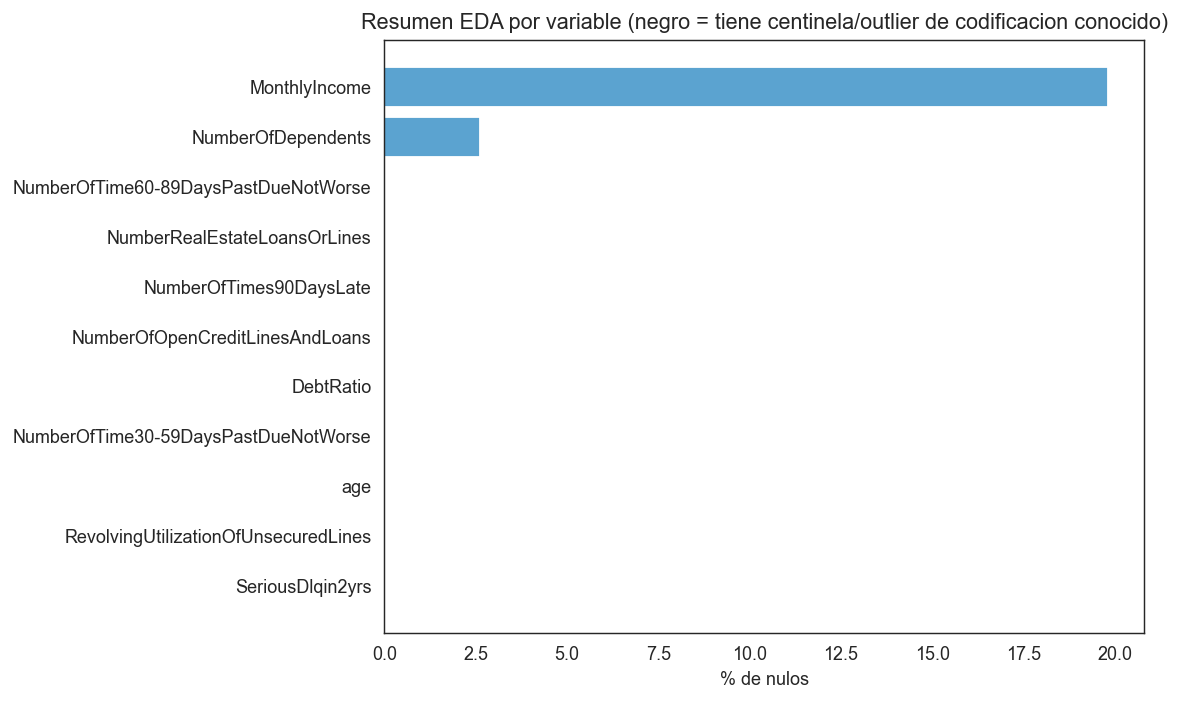

In [97]:
n_vars_total = len(eda_resumen)
n_vars_con_centinela = int(eda_resumen["tiene_centinela_u_outlier_conocido"].sum())
vars_con_nulos = eda_resumen[eda_resumen["pct_nulos"] > 0]

print(f"Variables con centinela/outlier de codificacion conocido: {n_vars_con_centinela} de "
      f"{n_vars_total} ({n_vars_con_centinela / n_vars_total * 100:.4f}%)")
print(f"Variables con nulos (pct_nulos > 0): {len(vars_con_nulos)} de {n_vars_total}")
print(vars_con_nulos[["variable", "pct_nulos"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
orden = eda_resumen.sort_values("pct_nulos", ascending=True)
colores_orden = [
    COLOR_INK_PRIMARY if tiene else plt.get_cmap(CMAP_SEQUENTIAL)(0.55)
    for tiene in orden["tiene_centinela_u_outlier_conocido"]
]
ax.barh(orden["variable"], orden["pct_nulos"], color=colores_orden)
ax.set_xlabel("% de nulos")
ax.set_title("Resumen EDA por variable (negro = tiene centinela/outlier de codificacion conocido)")
guardar_figura(fig, "10_resumen_eda_por_variable")

**Hallazgo 10.1:** de las 11 columnas de `df_train`, 6 (54.5455%) tienen un centinela u
outlier de codificacion conocido documentado en la seccion 3: las 3 columnas
`NumberOfTime*PastDue*` (valores 96/98, Hallazgo 3.1), `age` (`age == 0`, Hallazgo 3.2),
`RevolvingUtilizationOfUnsecuredLines` (> 2, Hallazgo 3.3) y `DebtRatio` (> p97.5, Hallazgo
3.3); las 5 restantes (`SeriousDlqin2yrs`, `MonthlyIncome`, `NumberOfOpenCreditLinesAndLoans`,
`NumberRealEstateLoansOrLines`, `NumberOfDependents`) no tienen un centinela/outlier de
codificacion propio detectado, aunque `MonthlyIncome` si tiene un patron de nulos MNAR
relevante (Hallazgo 8.1/8.2). Solo 2 de las 11 columnas tienen nulos: `MonthlyIncome`
(19.8048%) y `NumberOfDependents` (2.6076%); las 9 restantes tienen 0.0% de nulos. Esta tabla
(`eda_resumen`, guardada en `results/tables/eda_resumen.csv`) es el entregable consolidado de
todo el EDA para `02_preprocesado.ipynb`: cada fila combina el diagnostico de nulos (seccion
2), el diagnostico de centinelas/outliers (seccion 3) y la recomendacion de tratamiento
(secciones 8 y 9).

## Conclusiones generales del EDA

Este notebook confirma que `df_train` esta limpio en su mayoria pero con dos frentes claros
para `02_preprocesado.ipynb`: nulos concentrados y no aleatorios en `MonthlyIncome` (19.8048%)
y `NumberOfDependents` (2.6076%), y varios centinelas/outliers de codificacion (96/98 en las
columnas `PastDue`, `age == 0`, colas extremas de `RevolvingUtilizationOfUnsecuredLines` y
`DebtRatio`), todo resumido en la tabla `eda_resumen` (Hallazgo 10.1). Esto **informa, sin
cerrar**, la propuesta **D-1.1** de `docs/DECISIONES.md`: la imputacion por tramo de edad y los
flags de "era nulo" (secciones 8.4-8.5) quedan documentados como evidencia, pero la decision de
implementacion se cierra en `02_preprocesado.ipynb`. Sobre **D-0.3** (familia de modelo), este
EDA aporta un matiz nuevo -tampoco concluyente-: el PCA necesita 6-8 componentes para retener
el 80-95% de la varianza (Hallazgo 6.2), ni t-SNE ni KernelPCA mejoran la separacion de clases
lograda por PCA (Hallazgo 7.2/7.3), y `RevolvingUtilizationOfUnsecuredLines` pasa de una
correlacion de Pearson practicamente nula con el target a una Spearman relevante y de signo
opuesto (Hallazgo 5.3), lo que apunta a senal monotona no lineal en al menos una variable. Esto
es un argumento adicional -no definitivo- a favor de valorar un modelo no estrictamente lineal,
pero **D-0.3 sigue ABIERTA**: falta comparar el rendimiento real de las familias candidatas.